<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW PARTE 2 DO PROJETO</b></CENTER><br/>

NOME COMPLETO: LENON OTMAR TONOLI MERLO

LINK PARA SEU PRÓPRIO COLAB: [Colab](https://colab.research.google.com/drive/1qLnw-mwpDW8kejwcaBKaF1SItBmSAOYm?usp=sharing)

LINK PARA SEU GITHUB: https://github.com/lenonmerlo/projeto-integrador-tcc-uwine

**LINK PARA SEU PRÓPRIO VÍDEO NO YOUTUBE - OBRIGATÓRIO:** https://youtu.be/dgHJoaxSuzI

# **Cenário Fictício**:

Prezados(as) alunos(as),

É ótimo que você como **Consultor** ( ***Data Science Consultant*** ) do **Projeto Data Science** tenha chegado no **Workflow - Parte 2: Aprendizado de Máquina** (*Machine Learnning*). A *Incrível Biblioteca*:

<center>

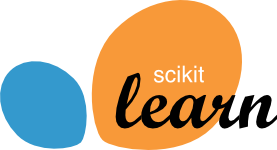

<center>

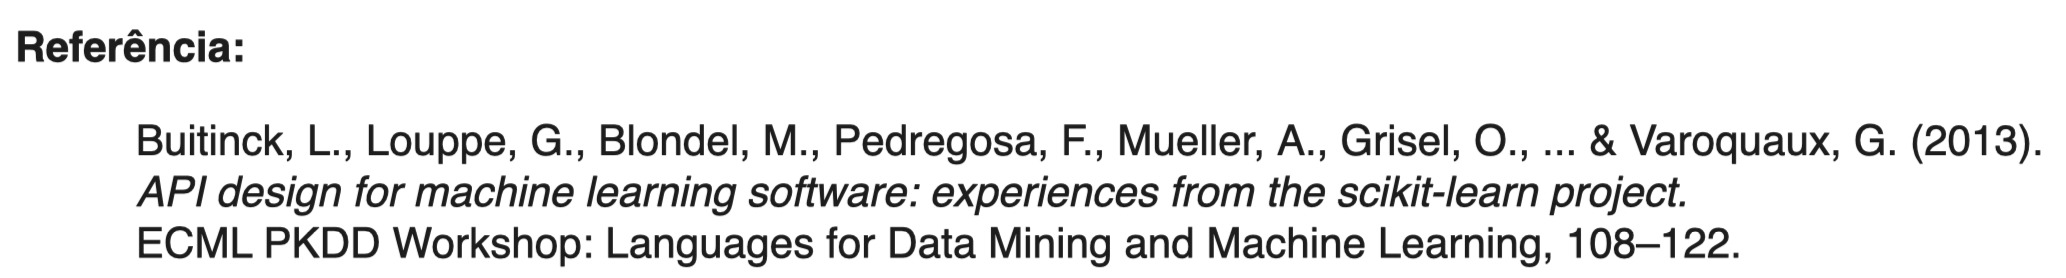

Neste etapa, você irá usar conjuntos (vários) que virão do **Workflow - Parte1**, a saber:

*   Conjunto de Treinamento: ***train***
*   Conjunto de Validação: ***validation***
*   Conjunto de Teste: ***test***

<center>

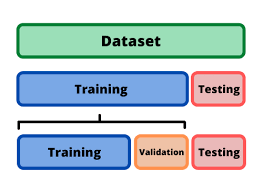

Ou seja:

<center>

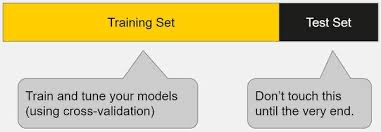


Com todas as Análises e *Insights* (**Estatistica Descritiva,** **Testes de Hipóteses** e os **Métodos Quantitativos**) que irão garatir que temos conjuntos com Qualidade (***Best Quality Analytics***) e que são ótimas amostras em relação a população ratificando justamente a importância da Parte 1 do projeto.

<center>

**EXCELENTE!!! Agora podemos ir mais longe no Universo Python!** 🚀🚀🚀

</center>

Podemos praticar as técnicas mais avançadas do **Aprendizado de Máquina** (*Machine Learnning*) e criarmos aprendizes dos seguintes modelos, a saber:

*   REGRESSOR: Modelo de Regressão: [Regression](https://scikit-learn.org/stable/supervised_learning.html)
*   CLUSTERIZADOR: Modelo de Agrupamento: [Clustering](https://scikit-learn.org/stable/modules/clustering.html)
*   CLASSIFICADOR: Modelo de Classificação:  [Classification](https://scikit-learn.org/stable/supervised_learning.html)

Para garantir organização, profundidade técnica e coerência metodológica no desenvolvimento do projeto, adotaremos um **Fluxo de Projeto (Ciclo de Vida)** composto pela atividades estabelecidas no **Workflow - Parte 2**, conforme a seguir:

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

## Load dos Datasets:

In [ ]:
# ==============================================================================
# BIBLIOTECAS E CONFIGURAÇÕES INICIAIS
# ==============================================================================
# Projeto: UWine - Parte 2
# Objetivo: Construção de modelos de Machine Learning para Regressão,
#           Clusterização e Classificação, com base nos datasets estratificados
#           definidos ao final da Parte 1.
# ==============================================================================

# Manipulação e análise de dados
import numpy as np
import pandas as pd

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="viridis"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [ ]:
# ==============================================================================
# BIBLIOTECAS DE MACHINE LEARNING
# ==============================================================================

# Pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Validação e seleção de modelos
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score
)

# Modelos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor

# Modelos de Clusterização
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Modelos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas de Regressão
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Métricas de Classificação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Estatística
from scipy import stats

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
# ==============================================================================
# LOAD DOS DATASETS ESTRATIFICADOS
# ==============================================================================
# Os conjuntos TRAIN, VALIDATION e TEST foram gerados ao final da Parte 1,
# respeitando os tamanhos amostrais ideais definidos por grupo:
#
# ESSENTIAL: 50.400 observações
# PRIME:     51.700 observações
# VIP:       51.700 observações
#
# Cada dataset deve possuir 153.800 registros e 23 variáveis.
# ==============================================================================

caminho_train = "df_train.csv"
caminho_validation = "df_validation.csv"
caminho_test = "df_test.csv"

train = pd.read_csv(caminho_train)
validation = pd.read_csv(caminho_validation)
test = pd.read_csv(caminho_test)

print("Datasets carregados com sucesso.")

Datasets carregados com sucesso.


In [ ]:
# ==============================================================================
# VERIFICAÇÃO INICIAL DAS DIMENSÕES
# ==============================================================================

resumo_dimensoes = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "Linhas": [train.shape[0], validation.shape[0], test.shape[0]],
    "Colunas": [train.shape[1], validation.shape[1], test.shape[1]]
})

display(resumo_dimensoes)

,Dataset,Linhas,Colunas
0,TRAIN,153800,23
1,VALIDATION,153800,23
2,TEST,153800,23


In [ ]:
# ==============================================================================
# VERIFICAÇÃO DA ESTRATIFICAÇÃO POR TIPO DA CONTA
# ==============================================================================

coluna_grupo = "TIPO DA CONTA"

def verificar_estratificacao(df, nome_dataset):
    frequencia = df[coluna_grupo].value_counts().sort_index()
    percentual = df[coluna_grupo].value_counts(normalize=True).sort_index() * 100

    resultado = pd.DataFrame({
        "Dataset": nome_dataset,
        "Grupo": frequencia.index,
        "Frequência": frequencia.values,
        "Percentual (%)": percentual.round(2).values
    })

    return resultado

verificacao_estratificacao = pd.concat([
    verificar_estratificacao(train, "TRAIN"),
    verificar_estratificacao(validation, "VALIDATION"),
    verificar_estratificacao(test, "TEST")
], ignore_index=True)

display(verificacao_estratificacao)

,Dataset,Grupo,Frequência,Percentual (%)
0,TRAIN,ESSENTIAL,50400,32.7700
1,TRAIN,PRIME,51700,33.6200
2,TRAIN,VIP,51700,33.6200
3,VALIDATION,ESSENTIAL,50400,32.7700
4,VALIDATION,PRIME,51700,33.6200
5,VALIDATION,VIP,51700,33.6200
6,TEST,ESSENTIAL,50400,32.7700
7,TEST,PRIME,51700,33.6200
8,TEST,VIP,51700,33.6200


In [ ]:
# ==============================================================================
# VALIDAÇÃO METODOLÓGICA DOS TAMANHOS ESPERADOS
# ==============================================================================

tamanhos_esperados = {
    "ESSENTIAL": 50400,
    "PRIME": 51700,
    "VIP": 51700
}

total_esperado = sum(tamanhos_esperados.values())

for nome, df in {
    "TRAIN": train,
    "VALIDATION": validation,
    "TEST": test
}.items():

    print(f"\n--- {nome} ---")
    print(f"Dimensão observada: {df.shape}")
    print(f"Total esperado: {total_esperado}")

    if df.shape[0] == total_esperado:
        print("Status: tamanho total correto.")
    else:
        print("Status: atenção, tamanho total diferente do esperado.")

    contagem = df[coluna_grupo].value_counts().to_dict()

    for grupo, esperado in tamanhos_esperados.items():
        observado = contagem.get(grupo, 0)

        if observado == esperado:
            print(f"{grupo}: correto ({observado})")
        else:
            print(f"{grupo}: esperado {esperado}, observado {observado}")


--- TRAIN ---
Dimensão observada: (153800, 23)
Total esperado: 153800
Status: tamanho total correto.
ESSENTIAL: correto (50400)
PRIME: correto (51700)
VIP: correto (51700)

--- VALIDATION ---
Dimensão observada: (153800, 23)
Total esperado: 153800
Status: tamanho total correto.
ESSENTIAL: correto (50400)
PRIME: correto (51700)
VIP: correto (51700)

--- TEST ---
Dimensão observada: (153800, 23)
Total esperado: 153800
Status: tamanho total correto.
ESSENTIAL: correto (50400)
PRIME: correto (51700)
VIP: correto (51700)


Load dos datasets aqui, a saber:

- Conjunto de Treinamento: `train`
- Conjunto de Validação: `validation`
- Conjunto de Teste: `test`

Qual o "TAMANHO IDEAL" do conjunto:

- Conjunto de Treinamento: **153.800 registros**
- Conjunto de Validação: **153.800 registros**
- Conjunto de Teste: **153.800 registros**

Cada conjunto foi construído com a seguinte composição estratificada:

- `ESSENTIAL`: **50.400 registros**
- `PRIME`: **51.700 registros**
- `VIP`: **51.700 registros**

Portanto, os três datasets preservam o tamanho ideal amostral definido na Parte 1 e seguem a orientação metodológica de utilizar o tamanho ideal completo em `TRAIN`, `VALIDATION` e `TEST`.

## Load dos Datasets

Nesta etapa, foram carregados os três conjuntos de dados que serão utilizados na Parte 2 do projeto UWine:

- `train`: conjunto de treinamento;
- `validation`: conjunto de validação;
- `test`: conjunto de teste.

Diferentemente de uma divisão percentual tradicional, os três datasets foram construídos com o tamanho amostral ideal completo por grupo, conforme orientação metodológica validada na Parte 1. Assim, cada conjunto preserva a representatividade dos segmentos `ESSENTIAL`, `PRIME` e `VIP`.

Essa decisão metodológica permite avaliar os modelos de Regressão, Clusterização e Classificação sobre bases robustas, estratificadas e estatisticamente compatíveis com a estrutura real da população da UWine.

# Workflow: Detalhamento das Atividades

#Atividade A1: Modelo de Regressão

## Atividade A1.1: Normalizar - Mapear - Discretizar

Nesta etapa, os dados são preparados para o modelo de Regressão, cujo objetivo será estimar a variável `TOTAL (R$)`.

A preparação segue três ações principais:

- **Normalizar:** padronização das variáveis numéricas por meio do `StandardScaler`;
- **Mapear:** transformação das variáveis categóricas em variáveis numéricas por `One-Hot Encoding`;
- **Discretizar:** criação de uma variável categórica de satisfação a partir da coluna `OPINIÃO DO CLIENTE`, preservando a lógica adotada na Parte 1.

A coluna `NOTA FISCAL` não será utilizada como variável preditora, pois representa apenas a chave primária da tabela.

In [ ]:
# ==============================================================================
# ATIVIDADE A1.1 - NORMALIZAR, MAPEAR E DISCRETIZAR
# ==============================================================================
# Modelo: Regressão
# Objetivo: preparar os conjuntos TRAIN, VALIDATION e TEST para estimar TOTAL (R$)
# ==============================================================================

TARGET_REG = "TOTAL (R$)"
ID_COL = "NOTA FISCAL"
OPINIAO_COL = "OPINIÃO DO CLIENTE"

train_reg = train.copy()
validation_reg = validation.copy()
test_reg = test.copy()

print("Cópias dos datasets criadas para a modelagem de Regressão.")
print(f"TRAIN:      {train_reg.shape}")
print(f"VALIDATION: {validation_reg.shape}")
print(f"TEST:       {test_reg.shape}")

Cópias dos datasets criadas para a modelagem de Regressão.
TRAIN:      (153800, 23)
VALIDATION: (153800, 23)
TEST:       (153800, 23)


In [ ]:
# ==============================================================================
# DISCRETIZAÇÃO DA OPINIÃO DO CLIENTE
# ==============================================================================
# A variável textual OPINIÃO DO CLIENTE é convertida em uma categoria sintética
# de satisfação, seguindo a lógica analítica desenvolvida na Parte 1.
# ==============================================================================

def classificar_satisfacao(opiniao):
    opiniao = str(opiniao).lower()

    if any(termo in opiniao for termo in [
        "excelente", "ótimo", "otimo", "perfeito", "impecável",
        "impecavel", "superou", "adorei"
    ]):
        return "Muito satisfeito"

    if any(termo in opiniao for termo in [
        "gostei", "satisfeito", "boa", "rápida", "rapida",
        "funcionou", "eficiente", "recomendo"
    ]):
        return "Satisfeito"

    if any(termo in opiniao for termo in [
        "indiferente", "nada", "regular", "comum",
        "aceitável", "aceitavel", "neutra", "neutro"
    ]):
        return "Indiferente"

    if any(termo in opiniao for termo in [
        "não gostei", "nao gostei", "ruim", "atrasado",
        "deixou a desejar", "faltou qualidade"
    ]):
        return "Insatisfeito"

    return "Indefinido"


for df in [train_reg, validation_reg, test_reg]:
    df["CATEGORIA SATISFAÇÃO"] = df[OPINIAO_COL].apply(classificar_satisfacao)

print("Variável CATEGORIA SATISFAÇÃO criada com sucesso.")

Variável CATEGORIA SATISFAÇÃO criada com sucesso.


In [ ]:
# ==============================================================================
# SEPARAÇÃO ENTRE ENTRADAS (X) E SAÍDA (y)
# ==============================================================================

colunas_remover_reg = [
    TARGET_REG,
    ID_COL,
    OPINIAO_COL
]

X_train_reg = train_reg.drop(columns=colunas_remover_reg, errors="ignore")
y_train_reg = train_reg[TARGET_REG]

X_validation_reg = validation_reg.drop(columns=colunas_remover_reg, errors="ignore")
y_validation_reg = validation_reg[TARGET_REG]

X_test_reg = test_reg.drop(columns=colunas_remover_reg, errors="ignore")
y_test_reg = test_reg[TARGET_REG]

print("Separação entre X e y concluída.")
print(f"X_train_reg:      {X_train_reg.shape} | y_train_reg:      {y_train_reg.shape}")
print(f"X_validation_reg: {X_validation_reg.shape} | y_validation_reg: {y_validation_reg.shape}")
print(f"X_test_reg:       {X_test_reg.shape} | y_test_reg:       {y_test_reg.shape}")

Separação entre X e y concluída.
X_train_reg:      (153800, 21) | y_train_reg:      (153800,)
X_validation_reg: (153800, 21) | y_validation_reg: (153800,)
X_test_reg:       (153800, 21) | y_test_reg:       (153800,)


In [ ]:
# ==============================================================================
# IDENTIFICAÇÃO DAS VARIÁVEIS NUMÉRICAS E CATEGÓRICAS
# ==============================================================================

num_cols_reg = X_train_reg.select_dtypes(include=np.number).columns.tolist()
cat_cols_reg = X_train_reg.select_dtypes(exclude=np.number).columns.tolist()

resumo_variaveis_reg = pd.DataFrame({
    "Tipo da Variável": ["Numéricas", "Categóricas"],
    "Quantidade": [len(num_cols_reg), len(cat_cols_reg)],
    "Variáveis": [num_cols_reg, cat_cols_reg]
})

display(resumo_variaveis_reg)

,Tipo da Variável,Quantidade,Variáveis
0,Numéricas,16,"[DEPENDENTES, RENDA BRUTO (R$), NOTA DE SATISF..."
1,Categóricas,5,"[REGIÃO, SEXO, ESTADO CIVIL, TIPO DA CONTA, CA..."


In [ ]:
# ==============================================================================
# NORMALIZAÇÃO E MAPEAMENTO DAS VARIÁVEIS
# ==============================================================================
# Numéricas: imputação pela mediana + StandardScaler
# Categóricas: imputação pela moda + One-Hot Encoding
# ==============================================================================

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_reg),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)
        ]), cat_cols_reg)
    ],
    remainder="drop"
)

X_train_reg_prepared = preprocessor_reg.fit_transform(X_train_reg)
X_validation_reg_prepared = preprocessor_reg.transform(X_validation_reg)
X_test_reg_prepared = preprocessor_reg.transform(X_test_reg)

feature_names_reg = preprocessor_reg.get_feature_names_out()

X_train_reg_prepared = pd.DataFrame(
    X_train_reg_prepared,
    columns=feature_names_reg,
    index=X_train_reg.index
)

X_validation_reg_prepared = pd.DataFrame(
    X_validation_reg_prepared,
    columns=feature_names_reg,
    index=X_validation_reg.index
)

X_test_reg_prepared = pd.DataFrame(
    X_test_reg_prepared,
    columns=feature_names_reg,
    index=X_test_reg.index
)

print("Normalização, mapeamento e discretização concluídos com sucesso.")
print(f"X_train_reg_prepared:      {X_train_reg_prepared.shape}")
print(f"X_validation_reg_prepared: {X_validation_reg_prepared.shape}")
print(f"X_test_reg_prepared:       {X_test_reg_prepared.shape}")

Normalização, mapeamento e discretização concluídos com sucesso.
X_train_reg_prepared:      (153800, 34)
X_validation_reg_prepared: (153800, 34)
X_test_reg_prepared:       (153800, 34)


In [ ]:
# ==============================================================================
# AMOSTRA DO DATASET PREPARADO
# ==============================================================================

display(X_train_reg_prepared.head())
display(y_train_reg.head())

,num__DEPENDENTES,num__RENDA BRUTO (R$),num__NOTA DE SATISFAÇÃO (%),num__MEAN: alcohol,num__MEAN: malic_acid,num__MEAN: ash,num__MEAN: alcalinity_of_ash,num__MEAN: magnesium,num__MEAN: total_phenols,num__MEAN: flavanoids,num__MEAN: nonflavanoid_phenols,num__MEAN: proanthocyanins,num__MEAN: color_intensity,num__MEAN: hue,num__MEAN: od280/od315_of_diluted_wines,num__MEAN: proline,cat__REGIÃO_CENTRO-OESTE,cat__REGIÃO_NORDESTE,cat__REGIÃO_NORTE,cat__REGIÃO_SUDESTE,cat__REGIÃO_SUL,cat__SEXO_FEMININO,cat__SEXO_MASCULINO,cat__ESTADO CIVIL_CASADO,cat__ESTADO CIVIL_DESQUITADO(A) / VIÚVO(A),cat__ESTADO CIVIL_SOLTEIRO,cat__TIPO DA CONTA_ESSENTIAL,cat__TIPO DA CONTA_PRIME,cat__TIPO DA CONTA_VIP,cat__CATEGORIA SATISFAÇÃO_Indefinido,cat__CATEGORIA SATISFAÇÃO_Indiferente,cat__CATEGORIA SATISFAÇÃO_Insatisfeito,cat__CATEGORIA SATISFAÇÃO_Muito satisfeito,cat__CATEGORIA SATISFAÇÃO_Satisfeito
0,3.0480,-0.9783,-0.2994,-0.1533,-0.6399,-1.0612,-2.7071,-2.2147,-1.1238,-0.3363,-1.3402,0.9060,-0.7879,-1.4284,-0.0299,-0.8529,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,0.9706,0.2672,-0.2994,-0.6960,-0.1847,0.9851,0.0222,-0.2041,1.1720,-1.5491,-0.0037,1.4446,-0.6284,-0.0935,0.8300,0.3327,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,-0.0680,-0.4201,-0.2994,1.0480,-0.9012,-1.0175,-0.7165,1.2305,0.5874,-0.2242,-0.8174,-0.1364,0.3463,0.4523,-0.2271,1.5839,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,-0.0680,-0.9927,-0.2994,0.4868,-1.8834,0.3080,-0.7607,-0.0239,-0.0501,-0.8508,0.1461,-0.8336,-1.5313,-1.3317,0.4067,-0.4422,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
4,0.9706,0.6088,-0.2994,-0.1280,0.3162,1.0293,-0.2471,-1.2993,-0.7995,0.1497,-0.3441,0.8500,0.0763,0.9229,0.2357,1.4995,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


,TOTAL (R$)
0,225.5400
1,"2,019.2600"
2,669.1200
3,495.4700
4,609.6000


In [ ]:
# ==============================================================================
# VALIDAÇÃO FINAL DA ETAPA A1.1
# ==============================================================================

resumo_preparacao_reg = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "Linhas X": [
        X_train_reg_prepared.shape[0],
        X_validation_reg_prepared.shape[0],
        X_test_reg_prepared.shape[0]
    ],
    "Colunas X": [
        X_train_reg_prepared.shape[1],
        X_validation_reg_prepared.shape[1],
        X_test_reg_prepared.shape[1]
    ],
    "Linhas y": [
        y_train_reg.shape[0],
        y_validation_reg.shape[0],
        y_test_reg.shape[0]
    ],
    "Variável Alvo": [TARGET_REG, TARGET_REG, TARGET_REG]
})

display(resumo_preparacao_reg)

,Dataset,Linhas X,Colunas X,Linhas y,Variável Alvo
0,TRAIN,153800,34,153800,TOTAL (R$)
1,VALIDATION,153800,34,153800,TOTAL (R$)
2,TEST,153800,34,153800,TOTAL (R$)


## Atividade A1.2: ETL - Separar Entrada (X) da Saída (y)

Nesta etapa, os conjuntos preparados na Atividade A1.1 são formalmente separados em:

- `X`: matriz de variáveis preditoras;
- `y`: vetor da variável alvo.

Para o modelo de Regressão, a variável alvo definida é `TOTAL (R$)`, enquanto as demais variáveis tratadas, normalizadas e mapeadas passam a compor a matriz de entrada.

Seguindo a estrutura dos notebooks de referência, os objetos finais são convertidos para `NDArray`, formato nativo utilizado pelos modelos do `scikit-learn`.

In [ ]:
# ==============================================================================
# ATIVIDADE A1.2 - ETL: SEPARAR ENTRADA (X) DA SAÍDA (y)
# ==============================================================================
# Modelo: Regressão
# Entrada (X): variáveis preditoras preparadas na Atividade A1.1
# Saída  (y): variável alvo TOTAL (R$)
# ==============================================================================

X_train_reg_array = X_train_reg_prepared.to_numpy()
X_validation_reg_array = X_validation_reg_prepared.to_numpy()
X_test_reg_array = X_test_reg_prepared.to_numpy()

y_train_reg_array = y_train_reg.to_numpy()
y_validation_reg_array = y_validation_reg.to_numpy()
y_test_reg_array = y_test_reg.to_numpy()

print("Conversão dos conjuntos de Regressão para NDArray concluída.")

Conversão dos conjuntos de Regressão para NDArray concluída.


In [ ]:
# ==============================================================================
# CONFERÊNCIA DAS DIMENSÕES DOS CONJUNTOS
# ==============================================================================

resumo_xy_reg = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "X - Linhas": [
        X_train_reg_array.shape[0],
        X_validation_reg_array.shape[0],
        X_test_reg_array.shape[0]
    ],
    "X - Variáveis": [
        X_train_reg_array.shape[1],
        X_validation_reg_array.shape[1],
        X_test_reg_array.shape[1]
    ],
    "y - Observações": [
        y_train_reg_array.shape[0],
        y_validation_reg_array.shape[0],
        y_test_reg_array.shape[0]
    ],
    "Variável Alvo": [
        TARGET_REG,
        TARGET_REG,
        TARGET_REG
    ],
    "Tipo de X": [
        type(X_train_reg_array).__name__,
        type(X_validation_reg_array).__name__,
        type(X_test_reg_array).__name__
    ],
    "Tipo de y": [
        type(y_train_reg_array).__name__,
        type(y_validation_reg_array).__name__,
        type(y_test_reg_array).__name__
    ]
})

display(resumo_xy_reg)

,Dataset,X - Linhas,X - Variáveis,y - Observações,Variável Alvo,Tipo de X,Tipo de y
0,TRAIN,153800,34,153800,TOTAL (R$),ndarray,ndarray
1,VALIDATION,153800,34,153800,TOTAL (R$),ndarray,ndarray
2,TEST,153800,34,153800,TOTAL (R$),ndarray,ndarray


In [ ]:
# ==============================================================================
# AMOSTRA DA MATRIZ DE ENTRADA E DO VETOR DE SAÍDA
# ==============================================================================

print("Amostra da matriz X_train_reg_array:")
display(pd.DataFrame(
    X_train_reg_array[:5],
    columns=X_train_reg_prepared.columns
))

print("Amostra do vetor y_train_reg_array:")
display(pd.DataFrame({
    TARGET_REG: y_train_reg_array[:5]
}))

Amostra da matriz X_train_reg_array:


,num__DEPENDENTES,num__RENDA BRUTO (R$),num__NOTA DE SATISFAÇÃO (%),num__MEAN: alcohol,num__MEAN: malic_acid,num__MEAN: ash,num__MEAN: alcalinity_of_ash,num__MEAN: magnesium,num__MEAN: total_phenols,num__MEAN: flavanoids,num__MEAN: nonflavanoid_phenols,num__MEAN: proanthocyanins,num__MEAN: color_intensity,num__MEAN: hue,num__MEAN: od280/od315_of_diluted_wines,num__MEAN: proline,cat__REGIÃO_CENTRO-OESTE,cat__REGIÃO_NORDESTE,cat__REGIÃO_NORTE,cat__REGIÃO_SUDESTE,cat__REGIÃO_SUL,cat__SEXO_FEMININO,cat__SEXO_MASCULINO,cat__ESTADO CIVIL_CASADO,cat__ESTADO CIVIL_DESQUITADO(A) / VIÚVO(A),cat__ESTADO CIVIL_SOLTEIRO,cat__TIPO DA CONTA_ESSENTIAL,cat__TIPO DA CONTA_PRIME,cat__TIPO DA CONTA_VIP,cat__CATEGORIA SATISFAÇÃO_Indefinido,cat__CATEGORIA SATISFAÇÃO_Indiferente,cat__CATEGORIA SATISFAÇÃO_Insatisfeito,cat__CATEGORIA SATISFAÇÃO_Muito satisfeito,cat__CATEGORIA SATISFAÇÃO_Satisfeito
0,3.0480,-0.9783,-0.2994,-0.1533,-0.6399,-1.0612,-2.7071,-2.2147,-1.1238,-0.3363,-1.3402,0.9060,-0.7879,-1.4284,-0.0299,-0.8529,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,0.9706,0.2672,-0.2994,-0.6960,-0.1847,0.9851,0.0222,-0.2041,1.1720,-1.5491,-0.0037,1.4446,-0.6284,-0.0935,0.8300,0.3327,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,-0.0680,-0.4201,-0.2994,1.0480,-0.9012,-1.0175,-0.7165,1.2305,0.5874,-0.2242,-0.8174,-0.1364,0.3463,0.4523,-0.2271,1.5839,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,-0.0680,-0.9927,-0.2994,0.4868,-1.8834,0.3080,-0.7607,-0.0239,-0.0501,-0.8508,0.1461,-0.8336,-1.5313,-1.3317,0.4067,-0.4422,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
4,0.9706,0.6088,-0.2994,-0.1280,0.3162,1.0293,-0.2471,-1.2993,-0.7995,0.1497,-0.3441,0.8500,0.0763,0.9229,0.2357,1.4995,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


Amostra do vetor y_train_reg_array:


,TOTAL (R$)
0,225.5400
1,"2,019.2600"
2,669.1200
3,495.4700
4,609.6000


In [ ]:
# ==============================================================================
# VALIDAÇÃO FINAL DA ETAPA A1.2
# ==============================================================================

validacao_dimensoes = (
    X_train_reg_array.shape[0] == y_train_reg_array.shape[0]
    and X_validation_reg_array.shape[0] == y_validation_reg_array.shape[0]
    and X_test_reg_array.shape[0] == y_test_reg_array.shape[0]
)

if validacao_dimensoes:
    print("VALIDAÇÃO FINAL DA ETAPA A1.2")
    print("-" * 70)
    print("Status: validação concluída com sucesso.")
    print(
        "Interpretação: as matrizes de entrada (X) e os vetores de saída (y) "
        "possuem dimensões compatíveis nos três conjuntos analisados."
    )
    print(
        f"Assim, os datasets TRAIN, VALIDATION e TEST estão consistentes para "
        f"a próxima etapa de criação e treinamento dos modelos de Regressão, "
        f"tendo como variável alvo '{TARGET_REG}'."
    )
else:
    print("VALIDAÇÃO FINAL DA ETAPA A1.2")
    print("-" * 70)
    print("Status: atenção, foi identificada divergência dimensional.")
    print(
        "Interpretação: pelo menos um dos conjuntos apresenta quantidade de "
        "observações diferente entre X e y. Recomenda-se revisar a etapa de "
        "separação das variáveis antes de prosseguir."
    )

VALIDAÇÃO FINAL DA ETAPA A1.2
----------------------------------------------------------------------
Status: validação concluída com sucesso.
Interpretação: as matrizes de entrada (X) e os vetores de saída (y) possuem dimensões compatíveis nos três conjuntos analisados.
Assim, os datasets TRAIN, VALIDATION e TEST estão consistentes para a próxima etapa de criação e treinamento dos modelos de Regressão, tendo como variável alvo 'TOTAL (R$)'.


##Atividade A1.3 (3º Passo): Criar o Modelo: **Regressors**

In [ ]:
# ==============================================================================
# ATIVIDADE A1.3 - CRIAR O MODELO: REGRESSORS
# ==============================================================================
# Objetivo: treinar diferentes modelos de Regressão para estimar TOTAL (R$)
# ==============================================================================

regressors = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=12,
        random_state=42
    ),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=14,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.08,
        max_depth=4,
        random_state=42
    ),

    "AdaBoost Regressor": AdaBoostRegressor(
        n_estimators=80,
        learning_rate=0.08,
        random_state=42
    )
}

modelos_treinados_reg = {}

print("INÍCIO DO TREINAMENTO DOS MODELOS DE REGRESSÃO")
print("-" * 70)

for nome_modelo, modelo in regressors.items():
    print(f"Treinando modelo: {nome_modelo}")

    modelo.fit(X_train_reg_array, y_train_reg_array)
    modelos_treinados_reg[nome_modelo] = modelo

    print(f"Status: {nome_modelo} treinado com sucesso.")

print("-" * 70)
print("Todos os modelos de Regressão foram criados e treinados com sucesso.")
print(f"Total de modelos treinados: {len(modelos_treinados_reg)}")

INÍCIO DO TREINAMENTO DOS MODELOS DE REGRESSÃO
----------------------------------------------------------------------
Treinando modelo: Linear Regression
Status: Linear Regression treinado com sucesso.
Treinando modelo: Decision Tree Regressor
Status: Decision Tree Regressor treinado com sucesso.
Treinando modelo: Random Forest Regressor
Status: Random Forest Regressor treinado com sucesso.
Treinando modelo: Gradient Boosting Regressor
Status: Gradient Boosting Regressor treinado com sucesso.
Treinando modelo: AdaBoost Regressor
Status: AdaBoost Regressor treinado com sucesso.
----------------------------------------------------------------------
Todos os modelos de Regressão foram criados e treinados com sucesso.
Total de modelos treinados: 5


In [ ]:
# ==============================================================================
# AVALIAÇÃO DOS MODELOS NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================

resultados_validation_reg = []

for nome_modelo, modelo in modelos_treinados_reg.items():
    y_pred_validation = modelo.predict(X_validation_reg_array)

    mae = mean_absolute_error(y_validation_reg_array, y_pred_validation)
    mse = mean_squared_error(y_validation_reg_array, y_pred_validation)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_validation_reg_array, y_pred_validation)

    resultados_validation_reg.append({
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

resultados_validation_reg = pd.DataFrame(resultados_validation_reg)
resultados_validation_reg = resultados_validation_reg.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

display(resultados_validation_reg)

,Modelo,MAE,MSE,RMSE,R²
0,Random Forest Regressor,385.9391,"299,922.6429",547.6519,0.7012
1,Gradient Boosting Regressor,395.2790,"315,290.4035",561.5073,0.6859
2,Linear Regression,395.4683,"316,185.2019",562.3035,0.6850
3,AdaBoost Regressor,397.3588,"317,757.0926",563.6995,0.6834
4,Decision Tree Regressor,399.1551,"332,257.5889",576.4179,0.6690


In [ ]:
# ==============================================================================
# SELEÇÃO DO MELHOR MODELO DE REGRESSÃO
# ==============================================================================

melhor_modelo_nome_reg = resultados_validation_reg.loc[0, "Modelo"]
melhor_modelo_reg = modelos_treinados_reg[melhor_modelo_nome_reg]

print("SELEÇÃO DO MODELO REGRESSOR")
print("-" * 70)
print(f"Melhor modelo na validação: {melhor_modelo_nome_reg}")
print(f"R² na validação: {resultados_validation_reg.loc[0, 'R²']:.4f}")
print(f"RMSE na validação: {resultados_validation_reg.loc[0, 'RMSE']:.4f}")
print(
    "Interpretação: o modelo selecionado apresentou o melhor desempenho "
    "preditivo no conjunto de validação e será utilizado na avaliação final "
    "sobre o conjunto de teste."
)

SELEÇÃO DO MODELO REGRESSOR
----------------------------------------------------------------------
Melhor modelo na validação: Random Forest Regressor
R² na validação: 0.7012
RMSE na validação: 547.6519
Interpretação: o modelo selecionado apresentou o melhor desempenho preditivo no conjunto de validação e será utilizado na avaliação final sobre o conjunto de teste.


In [ ]:
# ==============================================================================
# AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ==============================================================================

y_pred_test_reg = melhor_modelo_reg.predict(X_test_reg_array)

mae_test_reg = mean_absolute_error(y_test_reg_array, y_pred_test_reg)
mse_test_reg = mean_squared_error(y_test_reg_array, y_pred_test_reg)
rmse_test_reg = np.sqrt(mse_test_reg)
r2_test_reg = r2_score(y_test_reg_array, y_pred_test_reg)

resultado_test_reg = pd.DataFrame({
    "Modelo Final": [melhor_modelo_nome_reg],
    "MAE": [mae_test_reg],
    "MSE": [mse_test_reg],
    "RMSE": [rmse_test_reg],
    "R²": [r2_test_reg]
})

display(resultado_test_reg)

print("AVALIAÇÃO FINAL DO MODELO REGRESSOR")
print("-" * 70)
print(f"Modelo final avaliado: {melhor_modelo_nome_reg}")
print(f"R² no teste: {r2_test_reg:.4f}")
print(f"RMSE no teste: {rmse_test_reg:.4f}")
print(
    "Interpretação: o conjunto de teste foi utilizado apenas após a seleção "
    "do melhor modelo na validação, preservando seu papel como avaliação final "
    "da capacidade de generalização."
)

,Modelo Final,MAE,MSE,RMSE,R²
0,Random Forest Regressor,385.8525,"299,204.0065",546.9954,0.7017


AVALIAÇÃO FINAL DO MODELO REGRESSOR
----------------------------------------------------------------------
Modelo final avaliado: Random Forest Regressor
R² no teste: 0.7017
RMSE no teste: 546.9954
Interpretação: o conjunto de teste foi utilizado apenas após a seleção do melhor modelo na validação, preservando seu papel como avaliação final da capacidade de generalização.


In [ ]:
# ==============================================================================
# COMPLEMENTO A1.3 - REGRESSORES NÃO LINEARES MAIS POTENTES
# ==============================================================================
# Objetivo: atender à sugestão metodológica de testar modelos com maior capacidade
# de capturar relações não lineares na variável TOTAL (R$).
# ==============================================================================

from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

print("COMPLEMENTO A1.3 - TESTE DE REGRESSORES MAIS POTENTES\n")
print("-" * 70)

regressors_avancados = {
    "Extra Trees Regressor": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ),

    "Hist Gradient Boosting Regressor": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.10,
        random_state=42
    ),

    "Extra Trees Regressor + Log Target": TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=2
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ),

    "Hist Gradient Boosting + Log Target": TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.10,
            random_state=42
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

resultados_regressores_avancados = []

for nome_modelo, modelo in regressors_avancados.items():
    print(f"Treinando modelo: {nome_modelo}")

    modelo.fit(X_train_reg_array, y_train_reg_array)

    y_pred_validation_avancado = modelo.predict(X_validation_reg_array)

    mae = mean_absolute_error(y_validation_reg_array, y_pred_validation_avancado)
    mse = mean_squared_error(y_validation_reg_array, y_pred_validation_avancado)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_validation_reg_array, y_pred_validation_avancado)

    resultados_regressores_avancados.append({
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Validation": r2
    })

    print(f"Status: {nome_modelo} treinado com sucesso.")
    print(f"R² Validation: {r2:.4f}\n")

resultado_modelos_reg_avancados = (
    pd.DataFrame(resultados_regressores_avancados)
    .sort_values("R² Validation", ascending=False)
    .reset_index(drop=True)
)

display(resultado_modelos_reg_avancados)

COMPLEMENTO A1.3 - TESTE DE REGRESSORES MAIS POTENTES

----------------------------------------------------------------------
Treinando modelo: Extra Trees Regressor
Status: Extra Trees Regressor treinado com sucesso.
R² Validation: 0.7528

Treinando modelo: Hist Gradient Boosting Regressor
Status: Hist Gradient Boosting Regressor treinado com sucesso.
R² Validation: 0.6871

Treinando modelo: Extra Trees Regressor + Log Target
Status: Extra Trees Regressor + Log Target treinado com sucesso.
R² Validation: 0.7388

Treinando modelo: Hist Gradient Boosting + Log Target
Status: Hist Gradient Boosting + Log Target treinado com sucesso.
R² Validation: 0.6692



,Modelo,MAE,MSE,RMSE,R² Validation
0,Extra Trees Regressor,325.4692,"248,111.0918",498.1075,0.7528
1,Extra Trees Regressor + Log Target,331.7672,"262,185.3930",512.0404,0.7388
2,Hist Gradient Boosting Regressor,394.8597,"314,085.4897",560.4333,0.6871
3,Hist Gradient Boosting + Log Target,402.0618,"332,061.0358",576.2474,0.6692


In [ ]:
# ==============================================================================
# SELEÇÃO DO MELHOR REGRESSOR AVANÇADO
# ==============================================================================

melhor_modelo_nome_reg_avancado = resultado_modelos_reg_avancados.loc[0, "Modelo"]
melhor_modelo_reg_avancado = regressors_avancados[melhor_modelo_nome_reg_avancado]

melhor_r2_validation_reg_avancado = resultado_modelos_reg_avancados.loc[0, "R² Validation"]

print("SELEÇÃO DO REGRESSOR AVANÇADO\n")
print("-" * 70)
print(f"Melhor modelo avançado na validação: {melhor_modelo_nome_reg_avancado}")
print(f"R² Validation: {melhor_r2_validation_reg_avancado:.4f}")

SELEÇÃO DO REGRESSOR AVANÇADO

----------------------------------------------------------------------
Melhor modelo avançado na validação: Extra Trees Regressor
R² Validation: 0.7528


In [ ]:
# ==============================================================================
# AVALIAÇÃO FINAL DO REGRESSOR AVANÇADO NO TEST
# ==============================================================================

y_pred_test_reg_avancado = melhor_modelo_reg_avancado.predict(X_test_reg_array)

mae_test_reg_avancado = mean_absolute_error(y_test_reg_array, y_pred_test_reg_avancado)
mse_test_reg_avancado = mean_squared_error(y_test_reg_array, y_pred_test_reg_avancado)
rmse_test_reg_avancado = np.sqrt(mse_test_reg_avancado)
r2_test_reg_avancado = r2_score(y_test_reg_array, y_pred_test_reg_avancado)

resultado_final_test_reg_avancado = pd.DataFrame({
    "Modelo Final Avançado": [melhor_modelo_nome_reg_avancado],
    "MAE": [mae_test_reg_avancado],
    "MSE": [mse_test_reg_avancado],
    "RMSE": [rmse_test_reg_avancado],
    "R² TEST": [r2_test_reg_avancado]
})

display(resultado_final_test_reg_avancado)

print("AVALIAÇÃO FINAL DO REGRESSOR AVANÇADO\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_reg_avancado}")
print(f"R² TEST: {r2_test_reg_avancado:.4f}")
print(f"RMSE TEST: {rmse_test_reg_avancado:.4f}\n")

if r2_test_reg_avancado > r2_test_reg:
    print(
        "Conclusão: o modelo avançado superou o Random Forest Regressor original "
        "no conjunto TEST e pode ser adotado como novo modelo final de Regressão."
    )
else:
    print(
        "Conclusão: o modelo avançado não superou o Random Forest Regressor original "
        "no conjunto TEST. Assim, mantém-se o modelo anterior como referência final."
    )

,Modelo Final Avançado,MAE,MSE,RMSE,R² TEST
0,Extra Trees Regressor,325.6601,"248,311.6723",498.3088,0.7524


AVALIAÇÃO FINAL DO REGRESSOR AVANÇADO

----------------------------------------------------------------------
Modelo avaliado: Extra Trees Regressor
R² TEST: 0.7524
RMSE TEST: 498.3088

Conclusão: o modelo avançado superou o Random Forest Regressor original no conjunto TEST e pode ser adotado como novo modelo final de Regressão.


In [ ]:
# ==============================================================================
# ATUALIZAÇÃO DO MODELO FINAL DE REGRESSÃO
# ==============================================================================
# Como o Extra Trees Regressor apresentou desempenho superior no conjunto TEST,
# ele passa a ser adotado como modelo final de Regressão.
# ==============================================================================

melhor_modelo_nome_reg = melhor_modelo_nome_reg_avancado
melhor_modelo_reg = melhor_modelo_reg_avancado

y_pred_train_reg = melhor_modelo_reg.predict(X_train_reg_array)
y_pred_validation_reg = melhor_modelo_reg.predict(X_validation_reg_array)
y_pred_test_reg = melhor_modelo_reg.predict(X_test_reg_array)

r2_train_reg = r2_score(y_train_reg_array, y_pred_train_reg)
r2_validation_reg = r2_score(y_validation_reg_array, y_pred_validation_reg)
r2_test_reg = r2_score(y_test_reg_array, y_pred_test_reg)

rmse_train_reg = np.sqrt(mean_squared_error(y_train_reg_array, y_pred_train_reg))
rmse_validation_reg = np.sqrt(mean_squared_error(y_validation_reg_array, y_pred_validation_reg))
rmse_test_reg = np.sqrt(mean_squared_error(y_test_reg_array, y_pred_test_reg))

resultado_modelo_final_reg_atualizado = pd.DataFrame({
    "Modelo Final": [melhor_modelo_nome_reg],
    "R² TRAIN": [r2_train_reg],
    "R² VALIDATION": [r2_validation_reg],
    "R² TEST": [r2_test_reg],
    "RMSE TRAIN": [rmse_train_reg],
    "RMSE VALIDATION": [rmse_validation_reg],
    "RMSE TEST": [rmse_test_reg]
})

display(resultado_modelo_final_reg_atualizado)

print("MODELO FINAL DE REGRESSÃO ATUALIZADO\n")
print("-" * 70)
print(f"Novo modelo final: {melhor_modelo_nome_reg}")
print(f"R² TEST atualizado: {r2_test_reg:.4f}")
print(f"RMSE TEST atualizado: {rmse_test_reg:.4f}")

,Modelo Final,R² TRAIN,R² VALIDATION,R² TEST,RMSE TRAIN,RMSE VALIDATION,RMSE TEST
0,Extra Trees Regressor,0.9922,0.7528,0.7524,88.0699,498.1075,498.3088


MODELO FINAL DE REGRESSÃO ATUALIZADO

----------------------------------------------------------------------
Novo modelo final: Extra Trees Regressor
R² TEST atualizado: 0.7524
RMSE TEST atualizado: 498.3088


### A1.3.1: Intervalo de confiança: Train





In [ ]:
# ==============================================================================
# A1.3.1 - INTERVALO DE CONFIANÇA: TRAIN
# ==============================================================================
# Objetivo: avaliar a estabilidade do modelo final de Regressão no conjunto
# de treinamento por meio de validação cruzada K-Fold.
# ==============================================================================

n_splits_reg = 5

cv_train_reg = KFold(
    n_splits=n_splits_reg,
    shuffle=True,
    random_state=42
)

print("A1.3.1 - INTERVALO DE CONFIANÇA: TRAIN")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_reg}")
print(f"Método: Validação Cruzada K-Fold com {n_splits_reg} folds")
print("Métrica avaliada: R²")

A1.3.1 - INTERVALO DE CONFIANÇA: TRAIN
----------------------------------------------------------------------
Modelo avaliado: Extra Trees Regressor
Método: Validação Cruzada K-Fold com 5 folds
Métrica avaliada: R²


In [ ]:
# ==============================================================================
# VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINAMENTO
# ==============================================================================

scores_train_reg = cross_val_score(
    melhor_modelo_reg,
    X_train_reg_array,
    y_train_reg_array,
    cv=cv_train_reg,
    scoring="r2",
    n_jobs=-1
)

media_train_reg = scores_train_reg.mean()
desvio_train_reg = scores_train_reg.std(ddof=1)
erro_padrao_train_reg = stats.sem(scores_train_reg)

ic_train_reg = stats.t.interval(
    confidence=0.95,
    df=len(scores_train_reg) - 1,
    loc=media_train_reg,
    scale=erro_padrao_train_reg
)

resultado_ic_train_reg = pd.DataFrame({
    "Modelo": [melhor_modelo_nome_reg],
    "Folds": [n_splits_reg],
    "R² Médio": [media_train_reg],
    "Desvio Padrão": [desvio_train_reg],
    "Erro Padrão": [erro_padrao_train_reg],
    "IC 95% Inferior": [ic_train_reg[0]],
    "IC 95% Superior": [ic_train_reg[1]]
})

display(resultado_ic_train_reg)

,Modelo,Folds,R² Médio,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior
0,Extra Trees Regressor,5,0.6772,0.0021,0.0009,0.6746,0.6797


In [ ]:
# ==============================================================================
# DETALHAMENTO DOS SCORES POR FOLD
# ==============================================================================

scores_train_detalhado_reg = pd.DataFrame({
    "Fold": np.arange(1, n_splits_reg + 1),
    "R²": scores_train_reg
})

display(scores_train_detalhado_reg)

,Fold,R²
0,1,0.6754
1,2,0.6751
2,3,0.6767
3,4,0.6797
4,5,0.6788


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DOS RESULTADOS
# ==============================================================================

amplitude_ic_train_reg = ic_train_reg[1] - ic_train_reg[0]

print("RELATÓRIO ESTATÍSTICO - TRAIN")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_reg}")
print(f"R² médio na validação cruzada: {media_train_reg:.4f}")
print(f"Desvio padrão dos scores: {desvio_train_reg:.4f}")
print(f"Erro padrão da média: {erro_padrao_train_reg:.4f}")
print(f"Intervalo de Confiança 95%: [{ic_train_reg[0]:.4f}, {ic_train_reg[1]:.4f}]")
print(f"Amplitude do IC 95%: {amplitude_ic_train_reg:.4f}")

print("\nInterpretação:")
print(
    "A validação cruzada no conjunto de treinamento indica a estabilidade interna\n "
    "do modelo final selecionado. O intervalo de confiança de 95% permite avaliar\n "
    "a variação esperada do R² quando o modelo é treinado e validado em diferentes\n "
    "partições do conjunto TRAIN."
)

if amplitude_ic_train_reg <= 0.05:
    print(
        "Conclusão: a amplitude do intervalo de confiança é baixa, sugerindo\n "
        "desempenho estável entre os folds e boa consistência interna do modelo."
    )
else:
    print(
        "Conclusão: a amplitude do intervalo de confiança indica variabilidade\n "
        "moderada entre os folds, sugerindo que o desempenho do modelo deve ser\n "
        "interpretado com atenção."
    )

RELATÓRIO ESTATÍSTICO - TRAIN
----------------------------------------------------------------------
Modelo avaliado: Extra Trees Regressor
R² médio na validação cruzada: 0.6772
Desvio padrão dos scores: 0.0021
Erro padrão da média: 0.0009
Intervalo de Confiança 95%: [0.6746, 0.6797]
Amplitude do IC 95%: 0.0051

Interpretação:
A validação cruzada no conjunto de treinamento indica a estabilidade interna
 do modelo final selecionado. O intervalo de confiança de 95% permite avaliar
 a variação esperada do R² quando o modelo é treinado e validado em diferentes
 partições do conjunto TRAIN.
Conclusão: a amplitude do intervalo de confiança é baixa, sugerindo
 desempenho estável entre os folds e boa consistência interna do modelo.


In [ ]:
# ==============================================================================
# A1.3.1 - VALIDAÇÃO CRUZADA ESTRATIFICADA POR GRUPO: TRAIN
# ==============================================================================
# Objetivo: avaliar o desempenho do modelo final em cada grupo dentro do conjunto
# de treinamento, considerando os folds da validação cruzada.
# ==============================================================================

from sklearn.base import clone

resultados_cv_grupos_train_reg = []

grupos_train_reg = train_reg["TIPO DA CONTA"].reset_index(drop=True)

for fold, (idx_treino, idx_validacao) in enumerate(
    cv_train_reg.split(X_train_reg_array),
    start=1
):
    modelo_fold = clone(melhor_modelo_reg)

    X_fold_train = X_train_reg_array[idx_treino]
    y_fold_train = y_train_reg_array[idx_treino]

    X_fold_val = X_train_reg_array[idx_validacao]
    y_fold_val = y_train_reg_array[idx_validacao]

    grupos_fold_val = grupos_train_reg.iloc[idx_validacao].to_numpy()

    modelo_fold.fit(X_fold_train, y_fold_train)
    y_fold_pred = modelo_fold.predict(X_fold_val)

    for grupo in sorted(np.unique(grupos_fold_val)):
        idx_grupo = grupos_fold_val == grupo

        y_real_grupo = y_fold_val[idx_grupo]
        y_pred_grupo = y_fold_pred[idx_grupo]

        mae = mean_absolute_error(y_real_grupo, y_pred_grupo)
        mse = mean_squared_error(y_real_grupo, y_pred_grupo)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_real_grupo, y_pred_grupo)

        resultados_cv_grupos_train_reg.append({
            "Fold": fold,
            "Grupo": grupo,
            "Observações": idx_grupo.sum(),
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R²": r2
        })

resultados_cv_grupos_train_reg = pd.DataFrame(resultados_cv_grupos_train_reg)

display(resultados_cv_grupos_train_reg)

,Fold,Grupo,Observações,MAE,MSE,RMSE,R²
0,1,ESSENTIAL,10202,149.6197,"46,940.7776",216.6582,0.6622
1,1,PRIME,10321,729.3986,"771,857.5965",878.5543,0.3113
2,1,VIP,10237,318.1040,"150,455.9349",387.8865,0.3497
3,2,ESSENTIAL,9998,145.8584,"43,705.0705",209.0576,0.6671
4,2,PRIME,10382,731.2043,"772,749.6848",879.0618,0.3074
5,2,VIP,10380,319.4864,"152,917.9221",391.0472,0.3919
6,3,ESSENTIAL,10057,145.9855,"42,416.2428",205.9520,0.6562
7,3,PRIME,10219,731.1755,"776,158.0678",880.9983,0.3181
8,3,VIP,10484,321.9939,"153,858.0516",392.2474,0.3736
9,4,ESSENTIAL,10075,147.3748,"44,291.1851",210.4547,0.6781


In [ ]:
# ==============================================================================
# RESUMO DA VALIDAÇÃO CRUZADA POR GRUPO: TRAIN
# ==============================================================================

resumo_cv_grupos_train_reg = (
    resultados_cv_grupos_train_reg
    .groupby("Grupo")
    .agg(
        Observações_Médias=("Observações", "mean"),
        R2_Médio=("R²", "mean"),
        R2_Desvio_Padrão=("R²", "std"),
        R2_Erro_Padrão=("R²", stats.sem),
        RMSE_Médio=("RMSE", "mean"),
        MAE_Médio=("MAE", "mean")
    )
    .reset_index()
)

resumo_cv_grupos_train_reg["IC 95% Inferior"] = (
    resumo_cv_grupos_train_reg["R2_Médio"]
    - 1.96 * resumo_cv_grupos_train_reg["R2_Erro_Padrão"]
)

resumo_cv_grupos_train_reg["IC 95% Superior"] = (
    resumo_cv_grupos_train_reg["R2_Médio"]
    + 1.96 * resumo_cv_grupos_train_reg["R2_Erro_Padrão"]
)

resumo_cv_grupos_train_reg["Amplitude IC 95%"] = (
    resumo_cv_grupos_train_reg["IC 95% Superior"]
    - resumo_cv_grupos_train_reg["IC 95% Inferior"]
)

display(resumo_cv_grupos_train_reg)

,Grupo,Observações_Médias,R2_Médio,R2_Desvio_Padrão,R2_Erro_Padrão,RMSE_Médio,MAE_Médio,IC 95% Inferior,IC 95% Superior,Amplitude IC 95%
0,ESSENTIAL,"10,080.0000",0.6688,0.0103,0.0046,209.8650,147.2521,0.6598,0.6778,0.0181
1,PRIME,"10,340.0000",0.3184,0.0093,0.0042,874.6138,725.5908,0.3102,0.3265,0.0163
2,VIP,"10,340.0000",0.3745,0.0160,0.0072,391.3084,319.7971,0.3604,0.3886,0.0281


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DA VALIDAÇÃO CRUZADA POR GRUPO: TRAIN
# ==============================================================================

print("VALIDAÇÃO CRUZADA ESTRATIFICADA POR GRUPO - TRAIN")
print("-" * 70)

df_resumo_train = resumo_cv_grupos_train_reg.sort_values(
    "R2_Médio",
    ascending=False
)

for _, linha in df_resumo_train.iterrows():
    print(
        f"{linha['Grupo']}: R² médio = {linha['R2_Médio']:.4f} | "
        f"IC 95% = [{linha['IC 95% Inferior']:.4f}, {linha['IC 95% Superior']:.4f}] | "
        f"RMSE médio = {linha['RMSE_Médio']:.4f}"
    )

melhor_grupo_train = df_resumo_train.iloc[0]
menor_grupo_train = df_resumo_train.iloc[-1]

print("\nInterpretação:")
print(
    f"Na validação cruzada do conjunto TRAIN, o grupo com maior capacidade\ "
    f"explicativa média foi {melhor_grupo_train['Grupo']}, enquanto o menor\ "
    f"desempenho médio foi observado em {menor_grupo_train['Grupo']}.\n "
    f"Essa avaliação confirma a importância de analisar o modelo por segmento,"
    f"pois os grupos ESSENTIAL, PRIME e VIP apresentam diferentes níveis de\n "
    f"previsibilidade para a variável {TARGET_REG}."
)
print("\nObservação metodológica:")
print(
    "O R² médio da validação cruzada pode ser inferior ao R² final no TEST, "
    "pois, em cada fold, o modelo é treinado apenas com uma fração do conjunto\n "
    "TRAIN. Portanto, esta etapa avalia principalmente a estabilidade interna "
    "do regressor, enquanto o TEST representa a avaliação final do modelo "
    "treinado com o conjunto TRAIN completo."
)

VALIDAÇÃO CRUZADA ESTRATIFICADA POR GRUPO - TRAIN
----------------------------------------------------------------------
ESSENTIAL: R² médio = 0.6688 | IC 95% = [0.6598, 0.6778] | RMSE médio = 209.8650
VIP: R² médio = 0.3745 | IC 95% = [0.3604, 0.3886] | RMSE médio = 391.3084
PRIME: R² médio = 0.3184 | IC 95% = [0.3102, 0.3265] | RMSE médio = 874.6138

Interpretação:
Na validação cruzada do conjunto TRAIN, o grupo com maior capacidade\ explicativa média foi ESSENTIAL, enquanto o menor\ desempenho médio foi observado em PRIME.
 Essa avaliação confirma a importância de analisar o modelo por segmento,pois os grupos ESSENTIAL, PRIME e VIP apresentam diferentes níveis de
 previsibilidade para a variável TOTAL (R$).

Observação metodológica:
O R² médio da validação cruzada pode ser inferior ao R² final no TEST, pois, em cada fold, o modelo é treinado apenas com uma fração do conjunto
 TRAIN. Portanto, esta etapa avalia principalmente a estabilidade interna do regressor, enquanto o TEST repre

A1.3.2 - Intervalo de Confiança: VALIDATION
  - bootstrap geral do R² na validação
  - avaliação estratificada do modelo no VALIDATION por ESSENTIAL, PRIME e VIP

In [ ]:
# ==============================================================================
# A1.3.2 - INTERVALO DE CONFIANÇA: VALIDATION
# ==============================================================================
# Objetivo: avaliar a estabilidade do desempenho do modelo final no conjunto de
# validação por meio de reamostragem bootstrap da métrica R².
# ==============================================================================

print("A1.3.2 - INTERVALO DE CONFIANÇA: VALIDATION")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_reg}")
print("Método: Bootstrap sobre o conjunto de validação")
print("Métrica avaliada: R²")

A1.3.2 - INTERVALO DE CONFIANÇA: VALIDATION
----------------------------------------------------------------------
Modelo avaliado: Extra Trees Regressor
Método: Bootstrap sobre o conjunto de validação
Métrica avaliada: R²


In [ ]:
# ==============================================================================
# PREVISÕES NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================

y_pred_validation_reg = melhor_modelo_reg.predict(X_validation_reg_array)

r2_validation_reg = r2_score(
    y_validation_reg_array,
    y_pred_validation_reg
)

print(f"R² observado no conjunto de validação: {r2_validation_reg:.4f}")

R² observado no conjunto de validação: 0.7528


In [ ]:
# ==============================================================================
# BOOTSTRAP DO R² NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================

n_bootstrap_reg = 1000
rng = np.random.default_rng(42)

scores_boot_validation_reg = np.zeros(n_bootstrap_reg)

n_validation = len(y_validation_reg_array)

for i in range(n_bootstrap_reg):
    indices = rng.choice(
        np.arange(n_validation),
        size=n_validation,
        replace=True
    )

    y_real_boot = y_validation_reg_array[indices]
    y_pred_boot = y_pred_validation_reg[indices]

    scores_boot_validation_reg[i] = r2_score(
        y_real_boot,
        y_pred_boot
    )

media_boot_validation_reg = scores_boot_validation_reg.mean()
desvio_boot_validation_reg = scores_boot_validation_reg.std(ddof=1)
erro_padrao_boot_validation_reg = stats.sem(scores_boot_validation_reg)

ic_boot_validation_reg = np.percentile(
    scores_boot_validation_reg,
    [2.5, 97.5]
)

resultado_ic_validation_reg = pd.DataFrame({
    "Modelo": [melhor_modelo_nome_reg],
    "Bootstrap": [n_bootstrap_reg],
    "R² Observado": [r2_validation_reg],
    "R² Médio Bootstrap": [media_boot_validation_reg],
    "Desvio Padrão": [desvio_boot_validation_reg],
    "Erro Padrão": [erro_padrao_boot_validation_reg],
    "IC 95% Inferior": [ic_boot_validation_reg[0]],
    "IC 95% Superior": [ic_boot_validation_reg[1]]
})

display(resultado_ic_validation_reg)

,Modelo,Bootstrap,R² Observado,R² Médio Bootstrap,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior
0,Extra Trees Regressor,1000,0.7528,0.7528,0.0013,0.0000,0.7503,0.7553


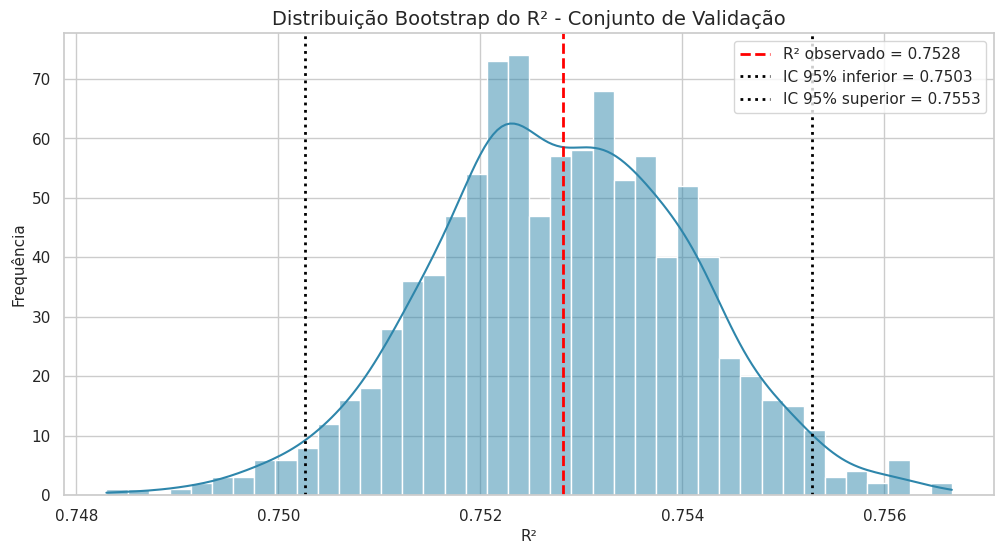

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO BOOTSTRAP
# ==============================================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    scores_boot_validation_reg,
    bins=40,
    kde=True,
    color="#2E86AB"
)

plt.axvline(
    r2_validation_reg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"R² observado = {r2_validation_reg:.4f}"
)

plt.axvline(
    ic_boot_validation_reg[0],
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"IC 95% inferior = {ic_boot_validation_reg[0]:.4f}"
)

plt.axvline(
    ic_boot_validation_reg[1],
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"IC 95% superior = {ic_boot_validation_reg[1]:.4f}"
)

plt.title("Distribuição Bootstrap do R² - Conjunto de Validação")
plt.xlabel("R²")
plt.ylabel("Frequência")
plt.legend()
plt.show()

In [ ]:
# ==============================================================================
# BOOTSTRAP DO R² POR GRUPO - VALIDATION
# ==============================================================================
# Objetivo: estimar a estabilidade do R² separadamente para ESSENTIAL, PRIME e VIP.
# ==============================================================================

n_bootstrap_grupo_reg = 1000
rng_grupo = np.random.default_rng(42)

scores_boot_grupos_validation_reg = {}
resultado_boot_grupos_validation_reg = []

for grupo in sorted(validation_reg["TIPO DA CONTA"].unique()):
    indices_grupo = validation_reg["TIPO DA CONTA"] == grupo

    y_real_grupo = y_validation_reg_array[indices_grupo]
    y_pred_grupo = y_pred_validation_reg[indices_grupo]

    n_grupo = len(y_real_grupo)
    scores_grupo = np.zeros(n_bootstrap_grupo_reg)

    for i in range(n_bootstrap_grupo_reg):
        indices_boot = rng_grupo.choice(
            np.arange(n_grupo),
            size=n_grupo,
            replace=True
        )

        scores_grupo[i] = r2_score(
            y_real_grupo[indices_boot],
            y_pred_grupo[indices_boot]
        )

    ic_grupo = np.percentile(scores_grupo, [2.5, 97.5])

    scores_boot_grupos_validation_reg[grupo] = scores_grupo

    resultado_boot_grupos_validation_reg.append({
        "Dataset": "VALIDATION",
        "Grupo": grupo,
        "Observações": n_grupo,
        "R² Observado": r2_score(y_real_grupo, y_pred_grupo),
        "R² Médio Bootstrap": scores_grupo.mean(),
        "Desvio Padrão": scores_grupo.std(ddof=1),
        "Erro Padrão": stats.sem(scores_grupo),
        "IC 95% Inferior": ic_grupo[0],
        "IC 95% Superior": ic_grupo[1],
        "Amplitude IC 95%": ic_grupo[1] - ic_grupo[0]
    })

resultado_boot_grupos_validation_reg = pd.DataFrame(resultado_boot_grupos_validation_reg)

display(resultado_boot_grupos_validation_reg)

,Dataset,Grupo,Observações,R² Observado,R² Médio Bootstrap,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior,Amplitude IC 95%
0,VALIDATION,ESSENTIAL,50400,0.6948,0.6951,0.0060,0.0002,0.6831,0.7061,0.0231
1,VALIDATION,PRIME,51700,0.4911,0.4910,0.0030,0.0001,0.4851,0.4967,0.0115
2,VALIDATION,VIP,51700,0.4979,0.4977,0.0053,0.0002,0.4869,0.5075,0.0206


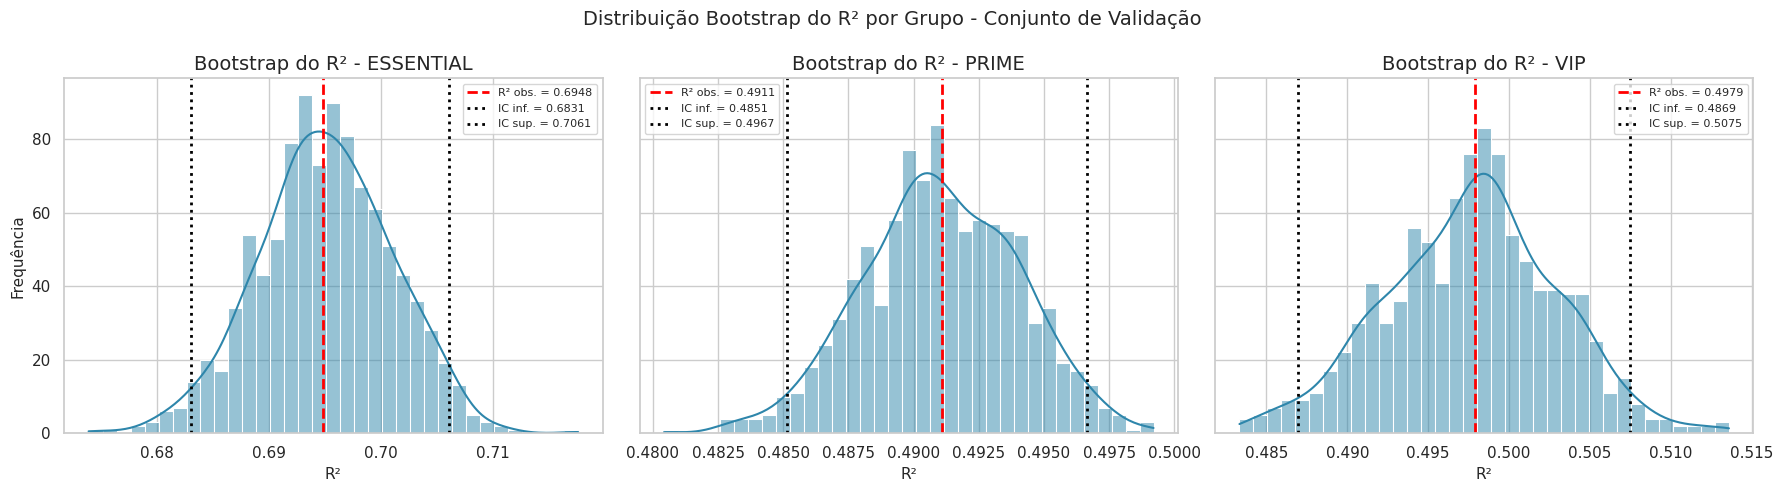

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO BOOTSTRAP DO R² POR GRUPO - VALIDATION
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grupo in zip(axes, sorted(scores_boot_grupos_validation_reg.keys())):
    scores_grupo = scores_boot_grupos_validation_reg[grupo]

    linha_grupo = resultado_boot_grupos_validation_reg[
        resultado_boot_grupos_validation_reg["Grupo"] == grupo
    ].iloc[0]

    sns.histplot(
        scores_grupo,
        bins=35,
        kde=True,
        color="#2E86AB",
        ax=ax
    )

    ax.axvline(
        linha_grupo["R² Observado"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"R² obs. = {linha_grupo['R² Observado']:.4f}"
    )

    ax.axvline(
        linha_grupo["IC 95% Inferior"],
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"IC inf. = {linha_grupo['IC 95% Inferior']:.4f}"
    )

    ax.axvline(
        linha_grupo["IC 95% Superior"],
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"IC sup. = {linha_grupo['IC 95% Superior']:.4f}"
    )

    ax.set_title(f"Bootstrap do R² - {grupo}")
    ax.set_xlabel("R²")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição Bootstrap do R² por Grupo - Conjunto de Validação", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DO BOOTSTRAP POR GRUPO - VALIDATION
# ==============================================================================

print("BOOTSTRAP ESTRATIFICADO DO R² - VALIDATION")
print("-" * 70)

df_boot_grupos = resultado_boot_grupos_validation_reg.sort_values(
    "R² Observado",
    ascending=False
)

for _, linha in df_boot_grupos.iterrows():
    print(
        f"{linha['Grupo']}: R² observado = {linha['R² Observado']:.4f} | "
        f"IC 95% = [{linha['IC 95% Inferior']:.4f}, {linha['IC 95% Superior']:.4f}] | "
        f"Amplitude = {linha['Amplitude IC 95%']:.4f}"
    )

melhor_grupo_boot = df_boot_grupos.iloc[0]
menor_grupo_boot = df_boot_grupos.iloc[-1]

print("\nInterpretação:")
print(
    f"O grupo com maior capacidade explicativa no conjunto de validação foi\n "
    f"{melhor_grupo_boot['Grupo']}, enquanto o menor desempenho foi observado em\n "
    f"{menor_grupo_boot['Grupo']}. Essa diferença reforça a necessidade de leitura\n "
    f"estratificada dos modelos, pois a performance global pode ocultar variações\n "
    f"importantes entre ESSENTIAL, PRIME e VIP."
)

BOOTSTRAP ESTRATIFICADO DO R² - VALIDATION
----------------------------------------------------------------------
ESSENTIAL: R² observado = 0.6948 | IC 95% = [0.6831, 0.7061] | Amplitude = 0.0231
VIP: R² observado = 0.4979 | IC 95% = [0.4869, 0.5075] | Amplitude = 0.0206
PRIME: R² observado = 0.4911 | IC 95% = [0.4851, 0.4967] | Amplitude = 0.0115

Interpretação:
O grupo com maior capacidade explicativa no conjunto de validação foi
 ESSENTIAL, enquanto o menor desempenho foi observado em
 PRIME. Essa diferença reforça a necessidade de leitura
 estratificada dos modelos, pois a performance global pode ocultar variações
 importantes entre ESSENTIAL, PRIME e VIP.


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DOS RESULTADOS
# ==============================================================================

amplitude_ic_validation_reg = ic_boot_validation_reg[1] - ic_boot_validation_reg[0]

print("RELATÓRIO ESTATÍSTICO - VALIDATION")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_reg}")
print(f"R² observado na validação: {r2_validation_reg:.4f}")
print(f"R² médio bootstrap: {media_boot_validation_reg:.4f}")
print(f"Desvio padrão bootstrap: {desvio_boot_validation_reg:.4f}")
print(f"Erro padrão bootstrap: {erro_padrao_boot_validation_reg:.4f}")
print(f"Intervalo de Confiança 95%: [{ic_boot_validation_reg[0]:.4f}, {ic_boot_validation_reg[1]:.4f}]")
print(f"Amplitude do IC 95%: {amplitude_ic_validation_reg:.4f}")

print("\nInterpretação:")
print(
    "A análise bootstrap no conjunto de validação avalia a estabilidade do "
    "desempenho do modelo final em dados não utilizados no treinamento direto.\n "
    "O intervalo de confiança obtido representa a faixa esperada para o R² "
    "considerando reamostragens sucessivas do conjunto VALIDATION."
)

if amplitude_ic_validation_reg <= 0.05:
    print(
        "Conclusão: o intervalo de confiança é estreito, indicando desempenho "
        "estável do modelo no conjunto de validação."
    )
else:
    print(
        "Conclusão: o intervalo de confiança apresenta amplitude moderada, "
        "indicando maior variabilidade do desempenho no conjunto de validação."
    )

RELATÓRIO ESTATÍSTICO - VALIDATION
----------------------------------------------------------------------
Modelo avaliado: Extra Trees Regressor
R² observado na validação: 0.7528
R² médio bootstrap: 0.7528
Desvio padrão bootstrap: 0.0013
Erro padrão bootstrap: 0.0000
Intervalo de Confiança 95%: [0.7503, 0.7553]
Amplitude do IC 95%: 0.0050

Interpretação:
A análise bootstrap no conjunto de validação avalia a estabilidade do desempenho do modelo final em dados não utilizados no treinamento direto.
 O intervalo de confiança obtido representa a faixa esperada para o R² considerando reamostragens sucessivas do conjunto VALIDATION.
Conclusão: o intervalo de confiança é estreito, indicando desempenho estável do modelo no conjunto de validação.


In [ ]:
# ==============================================================================
# AVALIAÇÃO ESTRATIFICADA DO MODELO REGRESSOR - VALIDATION
# ==============================================================================
# Objetivo: verificar se o desempenho do modelo final no conjunto de validação
# se mantém consistente entre ESSENTIAL, PRIME e VIP.
# ==============================================================================

def avaliar_regressao_por_grupo(df_original, y_real, y_pred, nome_dataset):
    resultados = []

    grupos = df_original["TIPO DA CONTA"].unique()

    for grupo in sorted(grupos):
        indices_grupo = df_original["TIPO DA CONTA"] == grupo

        y_real_grupo = y_real[indices_grupo]
        y_pred_grupo = y_pred[indices_grupo]

        mae = mean_absolute_error(y_real_grupo, y_pred_grupo)
        mse = mean_squared_error(y_real_grupo, y_pred_grupo)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_real_grupo, y_pred_grupo)

        resultados.append({
            "Dataset": nome_dataset,
            "Grupo": grupo,
            "Observações": indices_grupo.sum(),
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R²": r2
        })

    return pd.DataFrame(resultados)


resultado_grupos_validation_reg = avaliar_regressao_por_grupo(
    validation_reg,
    y_validation_reg_array,
    y_pred_validation_reg,
    "VALIDATION"
)

display(resultado_grupos_validation_reg)

,Dataset,Grupo,Observações,MAE,MSE,RMSE,R²
0,VALIDATION,ESSENTIAL,50400,136.2337,"38,601.4692",196.4726,0.6948
1,VALIDATION,PRIME,51700,567.8957,"576,286.2078",759.1352,0.4911
2,VALIDATION,VIP,51700,267.5198,"124,177.4648",352.3882,0.4979


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DA AVALIAÇÃO ESTRATIFICADA - VALIDATION
# ==============================================================================

print("AVALIAÇÃO ESTRATIFICADA - VALIDATION")
print("-" * 70)

df_temp = resultado_grupos_validation_reg.sort_values("R²", ascending=False)

melhor_grupo = df_temp.iloc[0]
menor_grupo = df_temp.iloc[-1]

print(
    f"Melhor desempenho: {melhor_grupo['Grupo']} "
    f"(R² = {melhor_grupo['R²']:.4f}, RMSE = {melhor_grupo['RMSE']:.4f})"
)

print(
    f"Menor desempenho: {menor_grupo['Grupo']} "
    f"(R² = {menor_grupo['R²']:.4f}, RMSE = {menor_grupo['RMSE']:.4f})"
)

print("\nInterpretação:")
print(
    "A avaliação estratificada no conjunto de validação permite verificar se o\n "
    "modelo final mantém desempenho consistente entre os grupos ESSENTIAL, PRIME\n "
    "e VIP. Essa análise é necessária porque a Parte 1 demonstrou que os segmentos\n "
    "possuem comportamentos estatísticos distintos, especialmente nas variáveis "
    "monetárias."
)

AVALIAÇÃO ESTRATIFICADA - VALIDATION
----------------------------------------------------------------------
Melhor desempenho: ESSENTIAL (R² = 0.6948, RMSE = 196.4726)
Menor desempenho: PRIME (R² = 0.4911, RMSE = 759.1352)

Interpretação:
A avaliação estratificada no conjunto de validação permite verificar se o
 modelo final mantém desempenho consistente entre os grupos ESSENTIAL, PRIME
 e VIP. Essa análise é necessária porque a Parte 1 demonstrou que os segmentos
 possuem comportamentos estatísticos distintos, especialmente nas variáveis monetárias.


### A1.3.3 - Resultado Final: TEST

Nesta etapa, o modelo final selecionado na validação é avaliado no conjunto de teste. O conjunto `TEST` não foi utilizado para seleção de modelo, sendo reservado para verificar a capacidade de generalização do regressor.

A avaliação é realizada em duas perspectivas:

- desempenho geral do modelo no conjunto de teste;
- desempenho estratificado por `TIPO DA CONTA`, considerando os grupos `ESSENTIAL`, `PRIME` e `VIP`.

In [ ]:
# ==============================================================================
# A1.3.3 - RESULTADO FINAL: TEST
# ==============================================================================
# Objetivo: avaliar o modelo final no conjunto de teste, preservando o TEST como
# base independente para mensurar a capacidade de generalização.
# ==============================================================================

print("A1.3.3 - RESULTADO FINAL: TEST")
print("-" * 70)
print(f"Modelo final avaliado: {melhor_modelo_nome_reg}")
print("Base avaliada: TEST")
print(f"Variável alvo: {TARGET_REG}")

A1.3.3 - RESULTADO FINAL: TEST
----------------------------------------------------------------------
Modelo final avaliado: Extra Trees Regressor
Base avaliada: TEST
Variável alvo: TOTAL (R$)


In [ ]:
# ==============================================================================
# PREVISÕES DO MODELO FINAL NO CONJUNTO DE TESTE
# ==============================================================================

y_pred_test_reg = melhor_modelo_reg.predict(X_test_reg_array)

mae_test_reg = mean_absolute_error(y_test_reg_array, y_pred_test_reg)
mse_test_reg = mean_squared_error(y_test_reg_array, y_pred_test_reg)
rmse_test_reg = np.sqrt(mse_test_reg)
r2_test_reg = r2_score(y_test_reg_array, y_pred_test_reg)

resultado_final_test_reg = pd.DataFrame({
    "Dataset": ["TEST"],
    "Modelo Final": [melhor_modelo_nome_reg],
    "Observações": [len(y_test_reg_array)],
    "MAE": [mae_test_reg],
    "MSE": [mse_test_reg],
    "RMSE": [rmse_test_reg],
    "R²": [r2_test_reg]
})

display(resultado_final_test_reg)

,Dataset,Modelo Final,Observações,MAE,MSE,RMSE,R²
0,TEST,Extra Trees Regressor,153800,325.6601,"248,311.6723",498.3088,0.7524


In [ ]:
# ==============================================================================
# AVALIAÇÃO ESTRATIFICADA DO MODELO REGRESSOR - TEST
# ==============================================================================

resultado_grupos_test_reg = avaliar_regressao_por_grupo(
    test_reg,
    y_test_reg_array,
    y_pred_test_reg,
    "TEST"
)

display(resultado_grupos_test_reg)

,Dataset,Grupo,Observações,MAE,MSE,RMSE,R²
0,TEST,ESSENTIAL,50400,137.2121,"39,478.4410",198.6918,0.6966
1,TEST,PRIME,51700,567.5062,"576,137.3077",759.0371,0.4869
2,TEST,VIP,51700,267.5234,"124,068.1426",352.2331,0.4909


In [ ]:
# ==============================================================================
# COMPARAÇÃO ENTRE VALIDATION E TEST POR GRUPO
# ==============================================================================

comparacao_validation_test_reg = pd.concat([
    resultado_grupos_validation_reg,
    resultado_grupos_test_reg
], ignore_index=True)

comparacao_validation_test_reg = comparacao_validation_test_reg.sort_values(
    ["Grupo", "Dataset"]
).reset_index(drop=True)

display(comparacao_validation_test_reg)

,Dataset,Grupo,Observações,MAE,MSE,RMSE,R²
0,TEST,ESSENTIAL,50400,137.2121,"39,478.4410",198.6918,0.6966
1,VALIDATION,ESSENTIAL,50400,136.2337,"38,601.4692",196.4726,0.6948
2,TEST,PRIME,51700,567.5062,"576,137.3077",759.0371,0.4869
3,VALIDATION,PRIME,51700,567.8957,"576,286.2078",759.1352,0.4911
4,TEST,VIP,51700,267.5234,"124,068.1426",352.2331,0.4909
5,VALIDATION,VIP,51700,267.5198,"124,177.4648",352.3882,0.4979


In [ ]:
# ==============================================================================
# RESUMO COMPARATIVO GERAL: VALIDATION X TEST
# ==============================================================================

resumo_geral_validation_test_reg = pd.DataFrame({
    "Dataset": ["VALIDATION", "TEST"],
    "Modelo": [melhor_modelo_nome_reg, melhor_modelo_nome_reg],
    "MAE": [
        mean_absolute_error(y_validation_reg_array, y_pred_validation_reg),
        mae_test_reg
    ],
    "MSE": [
        mean_squared_error(y_validation_reg_array, y_pred_validation_reg),
        mse_test_reg
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_validation_reg_array, y_pred_validation_reg)),
        rmse_test_reg
    ],
    "R²": [
        r2_validation_reg,
        r2_test_reg
    ]
})

display(resumo_geral_validation_test_reg)

,Dataset,Modelo,MAE,MSE,RMSE,R²
0,VALIDATION,Extra Trees Regressor,325.4692,"248,111.0918",498.1075,0.7528
1,TEST,Extra Trees Regressor,325.6601,"248,311.6723",498.3088,0.7524


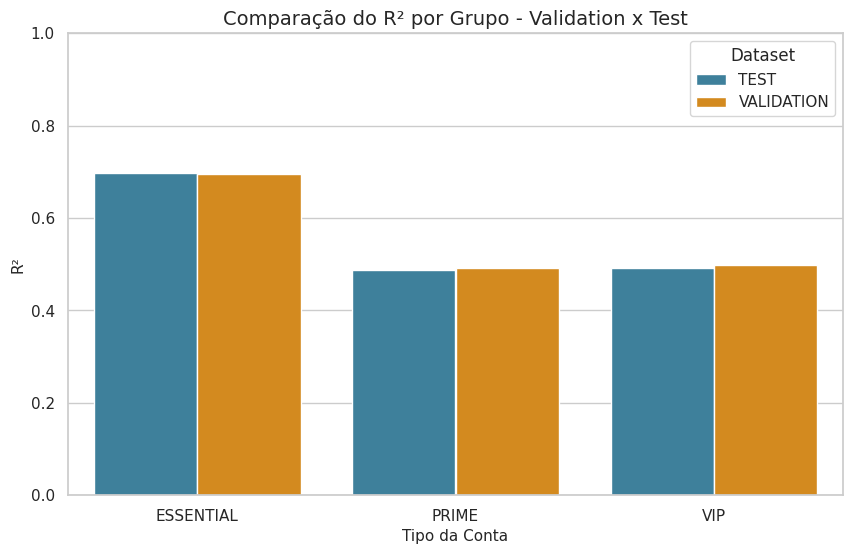

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO COMPARATIVA DO R² POR GRUPO
# ==============================================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparacao_validation_test_reg,
    x="Grupo",
    y="R²",
    hue="Dataset",
    palette=["#2E86AB", "#F18F01"]
)

plt.title("Comparação do R² por Grupo - Validation x Test")
plt.xlabel("Tipo da Conta")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.legend(title="Dataset")
plt.show()

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DO RESULTADO FINAL - TEST
# ==============================================================================

df_test_ordenado = resultado_grupos_test_reg.sort_values("R²", ascending=False)

melhor_grupo_test = df_test_ordenado.iloc[0]
menor_grupo_test = df_test_ordenado.iloc[-1]

dif_r2_geral = abs(r2_validation_reg - r2_test_reg)
dif_rmse_geral = abs(
    np.sqrt(mean_squared_error(y_validation_reg_array, y_pred_validation_reg))
    - rmse_test_reg
)

print("RELATÓRIO FINAL DO MODELO REGRESSOR - TEST")
print("-" * 70)
print(f"Modelo final: {melhor_modelo_nome_reg}")
print(f"R² no VALIDATION: {r2_validation_reg:.4f}")
print(f"R² no TEST: {r2_test_reg:.4f}")
print(f"Diferença absoluta de R² entre VALIDATION e TEST: {dif_r2_geral:.4f}")
print(f"RMSE no TEST: {rmse_test_reg:.4f}")

print("\nDesempenho estratificado no TEST:")
print(
    f"Melhor grupo: {melhor_grupo_test['Grupo']} "
    f"(R² = {melhor_grupo_test['R²']:.4f}, RMSE = {melhor_grupo_test['RMSE']:.4f})"
)
print(
    f"Menor grupo: {menor_grupo_test['Grupo']} "
    f"(R² = {menor_grupo_test['R²']:.4f}, RMSE = {menor_grupo_test['RMSE']:.4f})"
)

print("\nInterpretação:")
print(
    "O conjunto TEST foi utilizado como avaliação final do modelo regressor,\n "
    "após a seleção do melhor modelo no conjunto VALIDATION. A proximidade entre\n "
    "os resultados gerais de validação e teste indica estabilidade da capacidade\n "
    "preditiva. A análise estratificada, por sua vez, permite verificar que o\n "
    "desempenho não é homogêneo entre os grupos ESSENTIAL, PRIME e VIP, reforçando\n "
    "a necessidade de interpretação por segmento."
)

RELATÓRIO FINAL DO MODELO REGRESSOR - TEST
----------------------------------------------------------------------
Modelo final: Extra Trees Regressor
R² no VALIDATION: 0.7528
R² no TEST: 0.7524
Diferença absoluta de R² entre VALIDATION e TEST: 0.0004
RMSE no TEST: 498.3088

Desempenho estratificado no TEST:
Melhor grupo: ESSENTIAL (R² = 0.6966, RMSE = 198.6918)
Menor grupo: PRIME (R² = 0.4869, RMSE = 759.0371)

Interpretação:
O conjunto TEST foi utilizado como avaliação final do modelo regressor,
 após a seleção do melhor modelo no conjunto VALIDATION. A proximidade entre
 os resultados gerais de validação e teste indica estabilidade da capacidade
 preditiva. A análise estratificada, por sua vez, permite verificar que o
 desempenho não é homogêneo entre os grupos ESSENTIAL, PRIME e VIP, reforçando
 a necessidade de interpretação por segmento.


##Atividade A1.4 (4º Passo): Medir a acurácia (score) dos Modelos de Regressão:

### A1.4.1: Exibir os Coeficientes de Determinação ($R^2$)

* Conjunto de Treinamento:

* Conjunto de Validação:

* Conjunto de Teste:

In [ ]:
# ==============================================================================
# A1.4.1 - EXIBIR OS COEFICIENTES DE DETERMINAÇÃO (R²)
# ==============================================================================
# Objetivo: calcular o score R² do modelo final nos conjuntos TRAIN,
# VALIDATION e TEST.
# ==============================================================================

y_pred_train_reg = melhor_modelo_reg.predict(X_train_reg_array)

r2_train_reg = r2_score(y_train_reg_array, y_pred_train_reg)
r2_validation_reg = r2_score(y_validation_reg_array, y_pred_validation_reg)
r2_test_reg = r2_score(y_test_reg_array, y_pred_test_reg)

resultado_r2_reg = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "Modelo": [melhor_modelo_nome_reg] * 3,
    "R²": [r2_train_reg, r2_validation_reg, r2_test_reg]
})

display(resultado_r2_reg)

print("A1.4.1 - COEFICIENTES DE DETERMINAÇÃO (R²)\n")
print(f"Modelo avaliado: {melhor_modelo_nome_reg}\n")
print(f"Conjunto de Treinamento: R² = {r2_train_reg:.4f}")
print(f"Conjunto de Validação:   R² = {r2_validation_reg:.4f}")
print(f"Conjunto de Teste:       R² = {r2_test_reg:.4f}\n")
print(
    "Interpretação: o coeficiente de determinação R² indica a proporção da "
    "variabilidade da variável TOTAL (R$) explicada pelo modelo de Regressão."
)

,Dataset,Modelo,R²
0,TRAIN,Extra Trees Regressor,0.9922
1,VALIDATION,Extra Trees Regressor,0.7528
2,TEST,Extra Trees Regressor,0.7524


A1.4.1 - COEFICIENTES DE DETERMINAÇÃO (R²)

Modelo avaliado: Extra Trees Regressor

Conjunto de Treinamento: R² = 0.9922
Conjunto de Validação:   R² = 0.7528
Conjunto de Teste:       R² = 0.7524

Interpretação: o coeficiente de determinação R² indica a proporção da variabilidade da variável TOTAL (R$) explicada pelo modelo de Regressão.


In [ ]:
# ==============================================================================
# BASE AUXILIAR PARA GRÁFICOS E RESÍDUOS
# ==============================================================================

def criar_resultado_regressao(df_original, y_real, y_pred, nome_dataset):
    return pd.DataFrame({
        "Dataset": nome_dataset,
        "TIPO DA CONTA": df_original["TIPO DA CONTA"].values,
        "y_real": y_real,
        "y_estimado": y_pred,
        "residuo": y_real - y_pred
    })

df_resultado_train_reg = criar_resultado_regressao(
    train_reg,
    y_train_reg_array,
    y_pred_train_reg,
    "TRAIN"
)

df_resultado_validation_reg = criar_resultado_regressao(
    validation_reg,
    y_validation_reg_array,
    y_pred_validation_reg,
    "VALIDATION"
)

df_resultado_test_reg = criar_resultado_regressao(
    test_reg,
    y_test_reg_array,
    y_pred_test_reg,
    "TEST"
)

df_resultados_reg = pd.concat([
    df_resultado_train_reg,
    df_resultado_validation_reg,
    df_resultado_test_reg
], ignore_index=True)

display(df_resultados_reg.head())

,Dataset,TIPO DA CONTA,y_real,y_estimado,residuo
0,TRAIN,ESSENTIAL,225.5400,246.5661,-21.0261
1,TRAIN,VIP,"2,019.2600","1,969.2721",49.9879
2,TRAIN,VIP,669.1200,710.5196,-41.3996
3,TRAIN,ESSENTIAL,495.4700,473.1608,22.3092
4,TRAIN,PRIME,609.6000,784.6479,-175.0479


### A1.4.2: Plotagem dos Conjuntos - REAL ($y$) x ESTIMADO ($\hat{y}$):

* Conjunto de Treinamento:

* Conjunto de Validação:

* Conjunto de Teste:

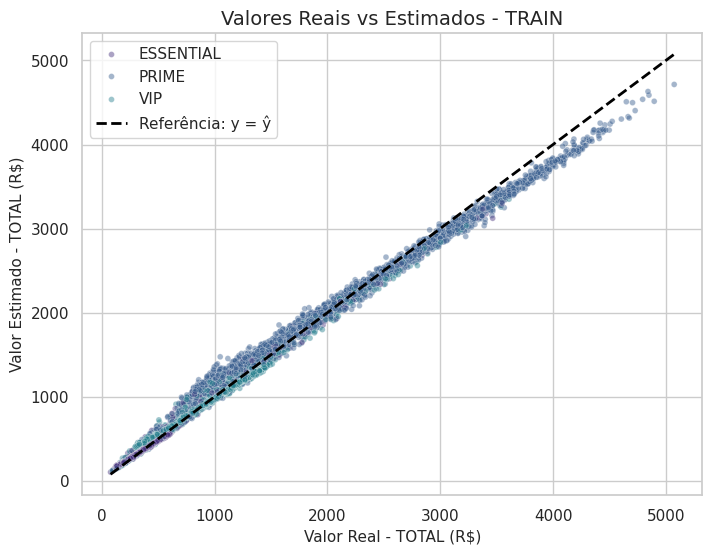

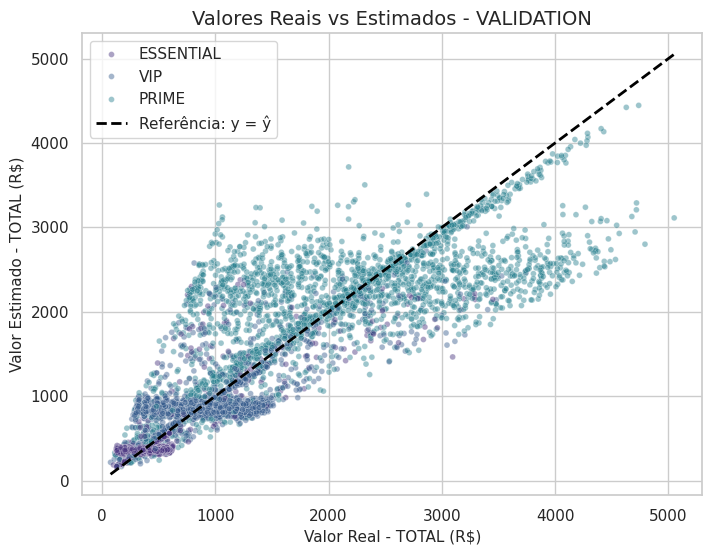

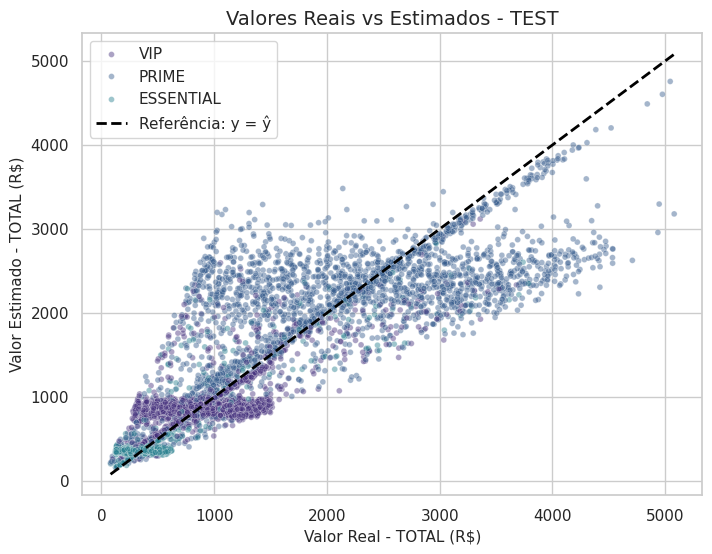

In [ ]:
# ==============================================================================
# A1.4.2 - PLOTAGEM: REAL (y) x ESTIMADO (ŷ)
# ==============================================================================

def plot_real_vs_estimado(df_resultado, nome_dataset, n_amostra=7000):
    df_plot = df_resultado.sample(
        n=min(n_amostra, len(df_resultado)),
        random_state=42
    )

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df_plot,
        x="y_real",
        y="y_estimado",
        hue="TIPO DA CONTA",
        alpha=0.45,
        s=18
    )

    minimo = min(df_plot["y_real"].min(), df_plot["y_estimado"].min())
    maximo = max(df_plot["y_real"].max(), df_plot["y_estimado"].max())

    plt.plot(
        [minimo, maximo],
        [minimo, maximo],
        color="black",
        linestyle="--",
        linewidth=2,
        label="Referência: y = ŷ"
    )

    plt.title(f"Valores Reais vs Estimados - {nome_dataset}")
    plt.xlabel("Valor Real - TOTAL (R$)")
    plt.ylabel("Valor Estimado - TOTAL (R$)")
    plt.legend()
    plt.show()


plot_real_vs_estimado(df_resultado_train_reg, "TRAIN")
plot_real_vs_estimado(df_resultado_validation_reg, "VALIDATION")
plot_real_vs_estimado(df_resultado_test_reg, "TEST")

### A1.4.3: Análise dos Resíduos: $\epsilon = y_{real} - y_{estimado}$

* Conjunto de Treinamento:

* Conjunto de Validação:

* Conjunto de Teste:

In [ ]:
# ==============================================================================
# A1.4.3 - ANÁLISE DOS RESÍDUOS: ε = y_real - y_estimado
# ==============================================================================

resumo_residuos_reg = (
    df_resultados_reg
    .groupby("Dataset")["residuo"]
    .agg(
        Média="mean",
        Mediana="median",
        Desvio_Padrão="std",
        Mínimo="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Máximo="max"
    )
    .reset_index()
)

display(resumo_residuos_reg)

print("A1.4.3 - ANÁLISE DOS RESÍDUOS\n")
print(
    "Interpretação: os resíduos representam a diferença entre o valor real "
    "e o valor estimado pelo modelo. Valores próximos de zero indicam menor "
    "erro de previsão."
)

,Dataset,Média,Mediana,Desvio_Padrão,Mínimo,Q1,Q3,Máximo
0,TEST,-0.4735,-0.8528,498.3102,"-2,414.8855",-183.8959,181.9714,"2,570.6380"
1,TRAIN,0.0000,0.0460,88.0702,-537.4359,-36.2127,36.4535,530.9935
2,VALIDATION,1.0779,-0.7184,498.1080,"-2,277.5724",-183.4055,182.5172,"2,456.7978"


A1.4.3 - ANÁLISE DOS RESÍDUOS

Interpretação: os resíduos representam a diferença entre o valor real e o valor estimado pelo modelo. Valores próximos de zero indicam menor erro de previsão.


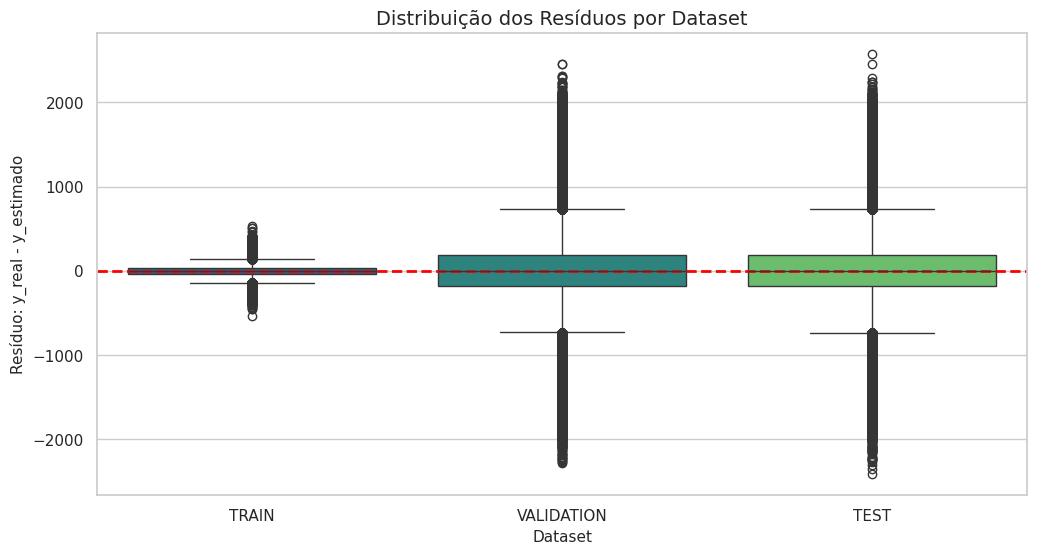

In [ ]:
# ==============================================================================
# DISTRIBUIÇÃO DOS RESÍDUOS POR DATASET
# ==============================================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_resultados_reg,
    x="Dataset",
    y="residuo",
    hue="Dataset",
    palette="viridis",
    legend=False
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Distribuição dos Resíduos por Dataset")
plt.xlabel("Dataset")
plt.ylabel("Resíduo: y_real - y_estimado")
plt.show()

### A1.4.4: JOINT: Resíduos ($\epsilon$) vs Valores Estimado ($\hat{y}$)

* Conjunto de Treinamento:

* Conjunto de Validação:

* Conjunto de Teste:

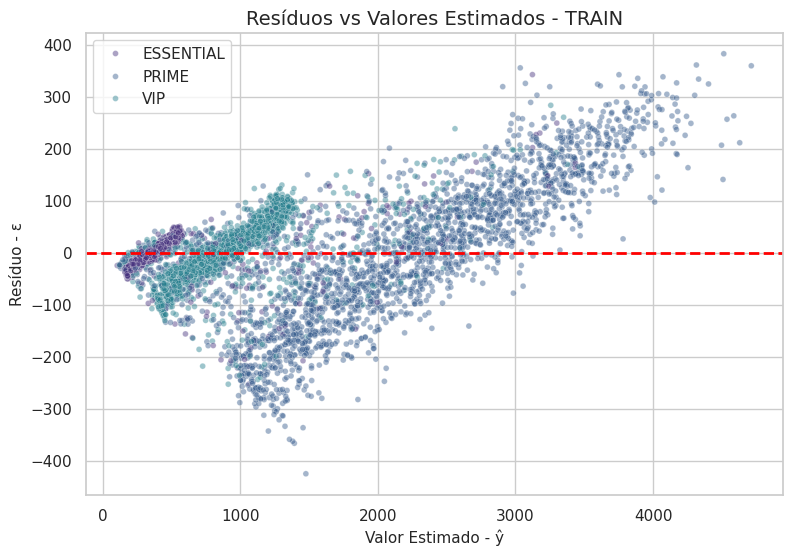

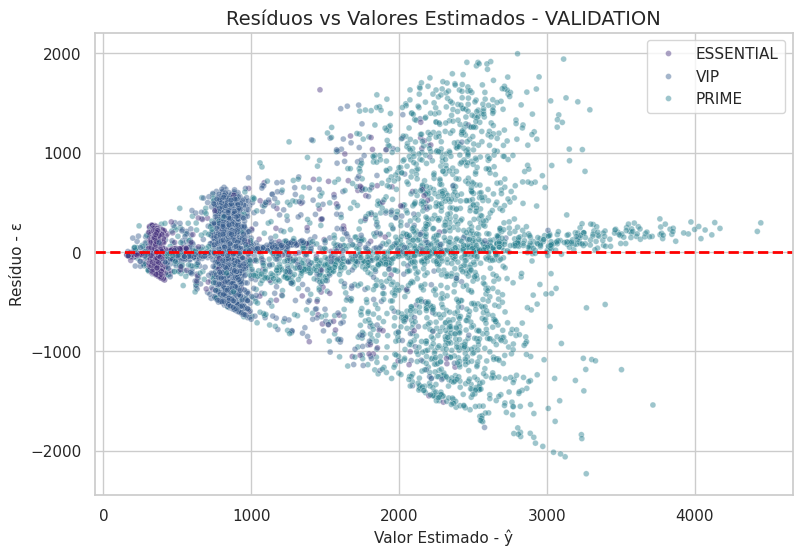

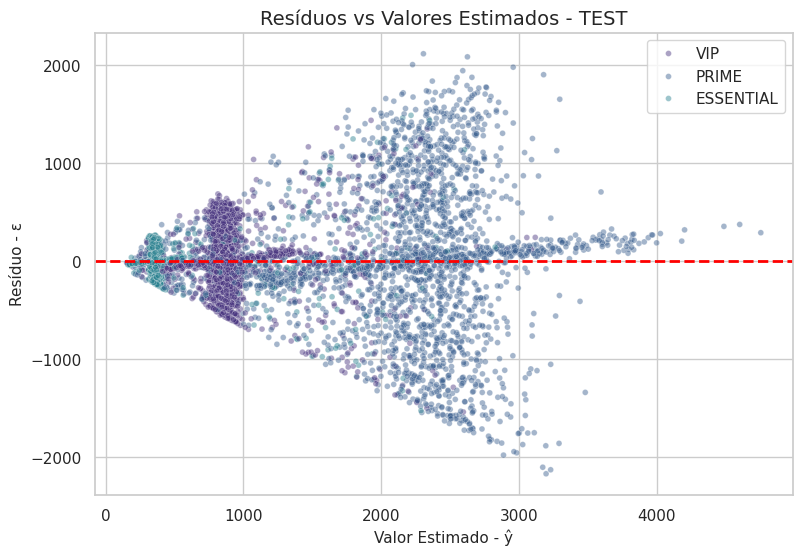

In [ ]:
# ==============================================================================
# A1.4.4 - JOINT: RESÍDUOS (ε) vs VALORES ESTIMADOS (ŷ)
# ==============================================================================

def plot_residuos_vs_estimado(df_resultado, nome_dataset, n_amostra=7000):
    df_plot = df_resultado.sample(
        n=min(n_amostra, len(df_resultado)),
        random_state=42
    )

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=df_plot,
        x="y_estimado",
        y="residuo",
        hue="TIPO DA CONTA",
        alpha=0.45,
        s=18
    )

    plt.axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=2
    )

    plt.title(f"Resíduos vs Valores Estimados - {nome_dataset}")
    plt.xlabel("Valor Estimado - ŷ")
    plt.ylabel("Resíduo - ε")
    plt.legend()
    plt.show()


plot_residuos_vs_estimado(df_resultado_train_reg, "TRAIN")
plot_residuos_vs_estimado(df_resultado_validation_reg, "VALIDATION")
plot_residuos_vs_estimado(df_resultado_test_reg, "TEST")

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO FINAL DA A1.4
# ==============================================================================

print("RELATÓRIO DA A1.4 - SCORE E RESÍDUOS DO MODELO REGRESSOR\n")
print("-" * 70)
print(f"\nModelo final avaliado: {melhor_modelo_nome_reg}")
print(f"Variável alvo: {TARGET_REG}\n")
print(f"R² TRAIN:      {r2_train_reg:.4f}")
print(f"R² VALIDATION: {r2_validation_reg:.4f}")
print(f"R² TEST:       {r2_test_reg:.4f}\n")
print(
    "Conclusão: a comparação entre os conjuntos TRAIN, VALIDATION e TEST\n "
    "permite avaliar a estabilidade do modelo regressor. A análise gráfica\n "
    "entre valores reais e estimados, associada ao estudo dos resíduos,\n "
    "fornece evidências complementares sobre a qualidade das previsões."
)

RELATÓRIO DA A1.4 - SCORE E RESÍDUOS DO MODELO REGRESSOR

----------------------------------------------------------------------

Modelo final avaliado: Extra Trees Regressor
Variável alvo: TOTAL (R$)

R² TRAIN:      0.9922
R² VALIDATION: 0.7528
R² TEST:       0.7524

Conclusão: a comparação entre os conjuntos TRAIN, VALIDATION e TEST
 permite avaliar a estabilidade do modelo regressor. A análise gráfica
 entre valores reais e estimados, associada ao estudo dos resíduos,
 fornece evidências complementares sobre a qualidade das previsões.


##Atividade A1.5 (5º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

In [ ]:
# ==============================================================================
# A1.5 - TESTAR O MODELO: DADOS DA POPULAÇÃO - AMOSTRA ALEATÓRIA
# ==============================================================================
# Objetivo: selecionar uma amostra aleatória da população, aplicar o modelo final
# de Regressão e comparar TOTAL (R$) real com TOTAL (R$) estimado.
# ==============================================================================

print("A1.5 - TESTAR O MODELO COM AMOSTRA ALEATÓRIA DA POPULAÇÃO\n")
print("-" * 70)
print(f"Modelo utilizado: {melhor_modelo_nome_reg}")
print(f"Variável alvo estimada: {TARGET_REG}")

A1.5 - TESTAR O MODELO COM AMOSTRA ALEATÓRIA DA POPULAÇÃO

----------------------------------------------------------------------
Modelo utilizado: Extra Trees Regressor
Variável alvo estimada: TOTAL (R$)


In [ ]:
# ==============================================================================
# DEFINIÇÃO DA BASE PARA TESTE FINAL
# ==============================================================================
# Conforme orientação metodológica, o conjunto TEST representa as amostras que
# não participaram das etapas de treinamento e validação. Por isso, a amostra
# aleatória final será retirada do próprio TEST.
# ==============================================================================

df_populacao_reg = test.copy()

print("DEFINIÇÃO DA BASE PARA TESTE FINAL\n")
print("-" * 70)
print(
    "Base utilizada: conjunto TEST, composto por amostras que não participaram "
    "das etapas de treinamento e validação.\n"
)
print(
    f"Base utilizada para amostragem: {df_populacao_reg.shape[0]} registros "
    f"e {df_populacao_reg.shape[1]} colunas."
)

DEFINIÇÃO DA BASE PARA TESTE FINAL

----------------------------------------------------------------------
Base utilizada: conjunto TEST, composto por amostras que não participaram das etapas de treinamento e validação.

Base utilizada para amostragem: 153800 registros e 23 colunas.


In [ ]:
# ==============================================================================
# SELEÇÃO DE AMOSTRA ALEATÓRIA ESTRATIFICADA
# ==============================================================================

n_por_grupo_sample = 5

sample_populacao_reg = (
    df_populacao_reg
    .groupby("TIPO DA CONTA", group_keys=False)
    .apply(lambda x: x.sample(n=n_por_grupo_sample, random_state=42))
    .reset_index(drop=True)
)

print("Amostra aleatória estratificada selecionada com sucesso.\n")
print(f"Quantidade total de registros na amostra: {sample_populacao_reg.shape[0]}")
display(sample_populacao_reg[["NOTA FISCAL", "TIPO DA CONTA", "TOTAL (R$)"]])

Amostra aleatória estratificada selecionada com sucesso.

Quantidade total de registros na amostra: 15


,NOTA FISCAL,TIPO DA CONTA,TOTAL (R$)
0,3642214,ESSENTIAL,349.6900
1,1220021,ESSENTIAL,591.7200
2,2297905,ESSENTIAL,556.6000
3,6510602,ESSENTIAL,515.3700
4,1997021,ESSENTIAL,608.1800
5,6198358,PRIME,"2,440.2200"
6,8477066,PRIME,"3,755.4100"
7,4158878,PRIME,"1,931.5000"
8,2077618,PRIME,"2,348.4800"
9,6137022,PRIME,"1,387.1800"


In [ ]:
# ==============================================================================
# PREPARAÇÃO DA AMOSTRA PARA O MODELO
# ==============================================================================

sample_populacao_reg["CATEGORIA SATISFAÇÃO"] = sample_populacao_reg[OPINIAO_COL].apply(
    classificar_satisfacao
)

X_sample_reg = sample_populacao_reg.drop(
    columns=colunas_remover_reg,
    errors="ignore"
)

y_sample_real_reg = sample_populacao_reg[TARGET_REG].to_numpy()

X_sample_reg_prepared = preprocessor_reg.transform(X_sample_reg)
y_sample_pred_reg = melhor_modelo_reg.predict(X_sample_reg_prepared)

print("Amostra preparada e estimada com sucesso.")

Amostra preparada e estimada com sucesso.


In [ ]:
# ==============================================================================
# RESULTADO DA PREDIÇÃO NA AMOSTRA ALEATÓRIA
# ==============================================================================

resultado_sample_reg = sample_populacao_reg[[
    "NOTA FISCAL",
    "TIPO DA CONTA",
    "REGIÃO",
    "SEXO",
    "ESTADO CIVIL",
    "RENDA BRUTO (R$)",
    TARGET_REG
]].copy()

resultado_sample_reg["TOTAL ESTIMADO (R$)"] = y_sample_pred_reg
resultado_sample_reg["RESÍDUO"] = resultado_sample_reg[TARGET_REG] - resultado_sample_reg["TOTAL ESTIMADO (R$)"]
resultado_sample_reg["ERRO ABSOLUTO"] = resultado_sample_reg["RESÍDUO"].abs()

resultado_sample_reg = resultado_sample_reg.rename(
    columns={TARGET_REG: "TOTAL REAL (R$)"}
)

display(resultado_sample_reg)

,NOTA FISCAL,TIPO DA CONTA,REGIÃO,SEXO,ESTADO CIVIL,RENDA BRUTO (R$),TOTAL REAL (R$),TOTAL ESTIMADO (R$),RESÍDUO,ERRO ABSOLUTO
0,3642214,ESSENTIAL,SUDESTE,FEMININO,DESQUITADO(A) / VIÚVO(A),"3,160.9500",349.6900,350.9711,-1.2811,1.2811
1,1220021,ESSENTIAL,SUL,MASCULINO,CASADO,"3,276.2700",591.7200,371.8408,219.8792,219.8792
2,2297905,ESSENTIAL,CENTRO-OESTE,MASCULINO,CASADO,"3,081.1500",556.6000,331.2601,225.3399,225.3399
3,6510602,ESSENTIAL,SUDESTE,FEMININO,CASADO,"3,422.5100",515.3700,395.3706,119.9994,119.9994
4,1997021,ESSENTIAL,SUDESTE,FEMININO,CASADO,"3,367.7200",608.1800,572.6141,35.5659,35.5659
5,6198358,PRIME,SUDESTE,MASCULINO,SOLTEIRO,"22,165.7100","2,440.2200","2,314.5343",125.6857,125.6857
6,8477066,PRIME,SUDESTE,MASCULINO,SOLTEIRO,"26,810.1100","3,755.4100","3,335.5792",419.8308,419.8308
7,4158878,PRIME,SUDESTE,FEMININO,SOLTEIRO,"27,564.4200","1,931.5000","3,053.6547","-1,122.1547","1,122.1547"
8,2077618,PRIME,CENTRO-OESTE,MASCULINO,CASADO,"23,464.9100","2,348.4800","2,469.4838",-121.0038,121.0038
9,6137022,PRIME,SUDESTE,MASCULINO,CASADO,"27,703.7000","1,387.1800","3,274.1934","-1,887.0134","1,887.0134"


In [ ]:
# ==============================================================================
# RESUMO DA AMOSTRA ALEATÓRIA
# ==============================================================================

resumo_sample_reg = (
    resultado_sample_reg
    .groupby("TIPO DA CONTA")
    .agg(
        Observações=("NOTA FISCAL", "count"),
        Total_Real_Médio=("TOTAL REAL (R$)", "mean"),
        Total_Estimado_Médio=("TOTAL ESTIMADO (R$)", "mean"),
        Erro_Absoluto_Médio=("ERRO ABSOLUTO", "mean"),
        Resíduo_Médio=("RESÍDUO", "mean")
    )
    .reset_index()
)

display(resumo_sample_reg)

print("INTERPRETAÇÃO DA AMOSTRA ALEATÓRIA - TEST\n")
print("-" * 70)
print(
    "A amostra aleatória estratificada foi retirada do conjunto TEST, que contém "
    "registros não utilizados nas etapas de treinamento e validação. Essa etapa "
    "permite observar o comportamento prático do modelo em registros individuais\n "
    "de teste, comparando o valor real de TOTAL (R$) com o valor estimado pelo "
    "regressor."
)

,TIPO DA CONTA,Observações,Total_Real_Médio,Total_Estimado_Médio,Erro_Absoluto_Médio,Resíduo_Médio
0,ESSENTIAL,5,524.3120,404.4113,120.4131,119.9007
1,PRIME,5,"2,372.5580","2,889.4891",735.1377,-516.9311
2,VIP,5,723.7460,921.5537,260.5288,-197.8077


INTERPRETAÇÃO DA AMOSTRA ALEATÓRIA - TEST

----------------------------------------------------------------------
A amostra aleatória estratificada foi retirada do conjunto TEST, que contém registros não utilizados nas etapas de treinamento e validação. Essa etapa permite observar o comportamento prático do modelo em registros individuais
 de teste, comparando o valor real de TOTAL (R$) com o valor estimado pelo regressor.


# RELATÓRIO PARCIAL - MODELO DE REGRESSÃO

## 1. Introdução

Este relatório apresenta a avaliação do modelo de Regressão desenvolvido para o projeto UWine, cujo objetivo foi estimar a variável `TOTAL (R$)`. A etapa contemplou a preparação dos dados, o treinamento de diferentes modelos regressivos, a seleção do melhor modelo e a análise de desempenho geral e estratificada.

## 2. Seleção e Treinamento do Modelo

Inicialmente, foram avaliados diferentes modelos regressivos, incluindo `Linear Regression`, `Decision Tree Regressor`, `Random Forest Regressor`, `Gradient Boosting Regressor` e `AdaBoost Regressor`.

Após a sugestão de testar modelos com maior capacidade de capturar relações não lineares, foram avaliados regressores mais potentes. O melhor desempenho foi obtido pelo `Extra Trees Regressor`, que superou o `Random Forest Regressor` anteriormente selecionado.

A variável alvo utilizada foi `TOTAL (R$)`, que representa o valor monetário total associado às transações dos clientes.

## 3. Preparação dos Dados

Os conjuntos `TRAIN`, `VALIDATION` e `TEST` foram construídos com amostragem estratificada por `TIPO DA CONTA`, preservando os tamanhos amostrais ideais definidos na Parte 1.

Cada conjunto possui 153.800 registros, distribuídos da seguinte forma:

- `ESSENTIAL`: 50.400 registros;
- `PRIME`: 51.700 registros;
- `VIP`: 51.700 registros.

Essa estrutura garante que a representatividade dos segmentos seja preservada em todas as fases da modelagem.

## 4. Desempenho Geral do Modelo

O `Extra Trees Regressor` apresentou os seguintes resultados:

- `TRAIN`: R² = 0,9922;
- `VALIDATION`: R² = 0,7528;
- `TEST`: R² = 0,7524;
- `RMSE TEST`: 498,3088.

O modelo anterior, `Random Forest Regressor`, havia alcançado R² de 0,7017 no conjunto `TEST`. Assim, o novo modelo aumentou a capacidade explicativa e reduziu o erro final de previsão.

A proximidade entre os resultados de validação e teste indica boa capacidade de generalização em dados não utilizados diretamente no treinamento.

## 5. Estabilidade Estatística

Na validação cruzada K-Fold aplicada ao conjunto `TRAIN`, o `Extra Trees Regressor` apresentou R² médio de 0,6772, com intervalo de confiança de 95% entre 0,6746 e 0,6797.

Esse valor é inferior ao R² final observado no `TEST`, pois, em cada fold, o modelo é treinado apenas com uma fração do conjunto `TRAIN`. Assim, a validação cruzada avalia principalmente a estabilidade interna do regressor, enquanto o `TEST` representa a avaliação final do modelo treinado com o conjunto `TRAIN` completo.

## 6. Desempenho Estratificado por Grupo

A avaliação por `TIPO DA CONTA` mostrou diferenças relevantes entre os segmentos:

| Grupo | R² Validation | RMSE Validation | R² Test | RMSE Test |
|---|---:|---:|---:|---:|
| ESSENTIAL | 0,6948 | 196,4726 | 0,6966 | 198,6918 |
| PRIME | 0,4911 | 759,1352 | 0,4869 | 759,0371 |
| VIP | 0,4979 | 352,3882 | 0,4909 | 352,2331 |

O grupo `ESSENTIAL` apresentou o melhor desempenho preditivo, enquanto o grupo `PRIME` permaneceu como o segmento de maior dificuldade de estimação. Esse resultado reforça a conclusão da Parte 1: os segmentos `ESSENTIAL`, `PRIME` e `VIP` possuem comportamentos estatísticos distintos e devem ser analisados de forma estratificada.

## 7. Análise dos Resíduos

A análise dos resíduos indicou médias próximas de zero nos conjuntos avaliados, sugerindo ausência de viés global expressivo. Entretanto, observou-se maior dispersão dos resíduos em faixas mais altas de `TOTAL (R$)`, indicando maior dificuldade do modelo em estimar transações de maior valor.

## 8. Conclusões Gerenciais

- O `Extra Trees Regressor` passou a ser adotado como modelo final de Regressão por superar o `Random Forest Regressor` no conjunto `TEST`.
- O desempenho final aumentou para R² = 0,7524, com RMSE = 498,3088.
- A melhora confirma a importância de testar modelos não lineares mais potentes para variáveis monetárias com alta variabilidade.
- A performance segue variando entre os segmentos, reforçando a necessidade de análise estratificada.
- A maior dispersão dos erros em valores monetários altos indica oportunidade de aprimoramento futuro com novas variáveis e análises específicas para clientes de maior valor.

#Atividade A2: Modelo de Clusterização

##Atividade A2.1 (1º Passo): Normalizar - Mapear - Discretizar

Nesta etapa, os dados são preparados para o modelo de Clusterização. Como se trata de aprendizagem não supervisionada, não há variável alvo (`y`) para treinamento do modelo.

A preparação será realizada com foco na matriz de entrada (`X`), composta por variáveis capazes de representar o perfil dos clientes da UWine. A coluna `TIPO DA CONTA` será preservada apenas para análise posterior dos clusters, mas não será utilizada na criação dos agrupamentos.

In [ ]:
# ==============================================================================
# ATIVIDADE A2.1 - NORMALIZAR, MAPEAR E DISCRETIZAR
# ==============================================================================
# Modelo: Clusterização
# Objetivo: preparar as variáveis de entrada para identificar agrupamentos
# naturais nos dados da UWine.
# ==============================================================================

ID_COL = "NOTA FISCAL"
TARGET_REG = "TOTAL (R$)"
GRUPO_COL = "TIPO DA CONTA"
OPINIAO_COL = "OPINIÃO DO CLIENTE"

train_cluster = train.copy()
validation_cluster = validation.copy()
test_cluster = test.copy()

print("Cópias dos datasets criadas para a modelagem de Clusterização.\n")
print(f"TRAIN:      {train_cluster.shape}")
print(f"VALIDATION: {validation_cluster.shape}")
print(f"TEST:       {test_cluster.shape}")

Cópias dos datasets criadas para a modelagem de Clusterização.

TRAIN:      (153800, 23)
VALIDATION: (153800, 23)
TEST:       (153800, 23)


In [ ]:
# ==============================================================================
# DISCRETIZAÇÃO DA OPINIÃO DO CLIENTE
# ==============================================================================
# A variável OPINIÃO DO CLIENTE é convertida em CATEGORIA SATISFAÇÃO, mantendo
# coerência com a abordagem adotada na Parte 1.
# ==============================================================================

for df in [train_cluster, validation_cluster, test_cluster]:
    df["CATEGORIA SATISFAÇÃO"] = df[OPINIAO_COL].apply(classificar_satisfacao)

print("Variável CATEGORIA SATISFAÇÃO criada com sucesso para Clusterização.")

Variável CATEGORIA SATISFAÇÃO criada com sucesso para Clusterização.


In [ ]:
# ==============================================================================
# DEFINIÇÃO DAS VARIÁVEIS PARA CLUSTERIZAÇÃO
# ==============================================================================
# TIPO DA CONTA não entra no modelo, pois será usado depois para comparar os
# clusters encontrados com os segmentos reais da base.
# ==============================================================================

colunas_remover_cluster = [
    ID_COL,
    GRUPO_COL,
    OPINIAO_COL
]

X_train_cluster = train_cluster.drop(columns=colunas_remover_cluster, errors="ignore")
X_validation_cluster = validation_cluster.drop(columns=colunas_remover_cluster, errors="ignore")
X_test_cluster = test_cluster.drop(columns=colunas_remover_cluster, errors="ignore")

print("Separação das variáveis de entrada para Clusterização concluída.\n")
print(f"X_train_cluster:      {X_train_cluster.shape}")
print(f"X_validation_cluster: {X_validation_cluster.shape}")
print(f"X_test_cluster:       {X_test_cluster.shape}")

Separação das variáveis de entrada para Clusterização concluída.

X_train_cluster:      (153800, 21)
X_validation_cluster: (153800, 21)
X_test_cluster:       (153800, 21)


In [ ]:
# ==============================================================================
# IDENTIFICAÇÃO DAS VARIÁVEIS NUMÉRICAS E CATEGÓRICAS
# ==============================================================================

num_cols_cluster = X_train_cluster.select_dtypes(include=np.number).columns.tolist()
cat_cols_cluster = X_train_cluster.select_dtypes(exclude=np.number).columns.tolist()

resumo_variaveis_cluster = pd.DataFrame({
    "Tipo da Variável": ["Numéricas", "Categóricas"],
    "Quantidade": [len(num_cols_cluster), len(cat_cols_cluster)],
    "Variáveis": [num_cols_cluster, cat_cols_cluster]
})

display(resumo_variaveis_cluster)

,Tipo da Variável,Quantidade,Variáveis
0,Numéricas,17,"[DEPENDENTES, RENDA BRUTO (R$), NOTA DE SATISF..."
1,Categóricas,4,"[REGIÃO, SEXO, ESTADO CIVIL, CATEGORIA SATISFA..."


In [ ]:
# ==============================================================================
# NORMALIZAÇÃO E MAPEAMENTO DAS VARIÁVEIS
# ==============================================================================
# Numéricas: imputação pela mediana + StandardScaler
# Categóricas: imputação pela moda + One-Hot Encoding
# ==============================================================================

try:
    encoder_cluster = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder_cluster = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_cluster = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_cluster),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder_cluster)
        ]), cat_cols_cluster)
    ],
    remainder="drop"
)

X_train_cluster_prepared = preprocessor_cluster.fit_transform(X_train_cluster)
X_validation_cluster_prepared = preprocessor_cluster.transform(X_validation_cluster)
X_test_cluster_prepared = preprocessor_cluster.transform(X_test_cluster)

feature_names_cluster = preprocessor_cluster.get_feature_names_out()

X_train_cluster_prepared = pd.DataFrame(
    X_train_cluster_prepared,
    columns=feature_names_cluster,
    index=X_train_cluster.index
)

X_validation_cluster_prepared = pd.DataFrame(
    X_validation_cluster_prepared,
    columns=feature_names_cluster,
    index=X_validation_cluster.index
)

X_test_cluster_prepared = pd.DataFrame(
    X_test_cluster_prepared,
    columns=feature_names_cluster,
    index=X_test_cluster.index
)

print("Normalização e mapeamento concluídos para Clusterização.\n")
print(f"X_train_cluster_prepared:      {X_train_cluster_prepared.shape}")
print(f"X_validation_cluster_prepared: {X_validation_cluster_prepared.shape}")
print(f"X_test_cluster_prepared:       {X_test_cluster_prepared.shape}")

Normalização e mapeamento concluídos para Clusterização.

X_train_cluster_prepared:      (153800, 32)
X_validation_cluster_prepared: (153800, 32)
X_test_cluster_prepared:       (153800, 32)


##Atividade A2.2 (2º Passo) - ETL: Separar Entrada ($X$) da Saída ($y$)



Como a Clusterização é uma técnica de aprendizagem não supervisionada, não há variável de saída (`y`) no processo de treinamento. Assim, esta etapa consiste na formalização da matriz de entrada (`X`) e na conversão dos dados para `NDArray`, formato utilizado pelos algoritmos de clusterização do `scikit-learn`.

A variável `TIPO DA CONTA` será mantida fora do treinamento e utilizada posteriormente apenas para análise comparativa dos agrupamentos obtidos.

In [ ]:
# ==============================================================================
# ATIVIDADE A2.2 - ETL: SEPARAR ENTRADA (X)
# ==============================================================================
# Modelo: Clusterização
# Observação: por ser aprendizagem não supervisionada, não há variável y.
# ==============================================================================

X_train_cluster_array = X_train_cluster_prepared.to_numpy()
X_validation_cluster_array = X_validation_cluster_prepared.to_numpy()
X_test_cluster_array = X_test_cluster_prepared.to_numpy()

print("Conversão dos conjuntos de Clusterização para NDArray concluída.")

Conversão dos conjuntos de Clusterização para NDArray concluída.


In [ ]:
# ==============================================================================
# CONFERÊNCIA DAS DIMENSÕES DOS CONJUNTOS
# ==============================================================================

resumo_x_cluster = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "X - Linhas": [
        X_train_cluster_array.shape[0],
        X_validation_cluster_array.shape[0],
        X_test_cluster_array.shape[0]
    ],
    "X - Variáveis": [
        X_train_cluster_array.shape[1],
        X_validation_cluster_array.shape[1],
        X_test_cluster_array.shape[1]
    ],
    "Saída y": [
        "Não se aplica",
        "Não se aplica",
        "Não se aplica"
    ],
    "Tipo de X": [
        type(X_train_cluster_array).__name__,
        type(X_validation_cluster_array).__name__,
        type(X_test_cluster_array).__name__
    ]
})

display(resumo_x_cluster)

,Dataset,X - Linhas,X - Variáveis,Saída y,Tipo de X
0,TRAIN,153800,32,Não se aplica,ndarray
1,VALIDATION,153800,32,Não se aplica,ndarray
2,TEST,153800,32,Não se aplica,ndarray


In [ ]:
# ==============================================================================
# VALIDAÇÃO FINAL DA ETAPA A2.2
# ==============================================================================

print("VALIDAÇÃO FINAL DA ETAPA A2.2\n")
print("-" * 70)
print("Status: validação concluída com sucesso.")
print(
    "\nInterpretação: os conjuntos TRAIN, VALIDATION e TEST foram convertidos "
    "para matrizes de entrada X em formato NDArray. Como a Clusterização é uma "
    "técnica não supervisionada, não há vetor de saída y nesta etapa."
)
print(
    "\nA variável TIPO DA CONTA foi preservada fora do treinamento para permitir "
    "a comparação posterior entre os clusters encontrados e os segmentos reais "
    "ESSENTIAL, PRIME e VIP."
)

VALIDAÇÃO FINAL DA ETAPA A2.2

----------------------------------------------------------------------
Status: validação concluída com sucesso.

Interpretação: os conjuntos TRAIN, VALIDATION e TEST foram convertidos para matrizes de entrada X em formato NDArray. Como a Clusterização é uma técnica não supervisionada, não há vetor de saída y nesta etapa.

A variável TIPO DA CONTA foi preservada fora do treinamento para permitir a comparação posterior entre os clusters encontrados e os segmentos reais ESSENTIAL, PRIME e VIP.


##Atividade A2.3 (3º Passo): Aplicar o Método do Cotovelo

In [ ]:
# ==============================================================================
# A2.3 - APLICAR O MÉTODO DO COTOVELO
# ==============================================================================
# Objetivo: avaliar diferentes valores de k para o KMeans a partir da inércia.
# Para reduzir custo computacional, será utilizada uma amostra estratificada do TRAIN.
# ==============================================================================

print("A2.3 - MÉTODO DO COTOVELO\n")
print("-" * 70)
print("Objetivo: identificar um número adequado de clusters para o modelo KMeans.")

A2.3 - MÉTODO DO COTOVELO

----------------------------------------------------------------------
Objetivo: identificar um número adequado de clusters para o modelo KMeans.


In [ ]:
# ==============================================================================
# AMOSTRA ESTRATIFICADA PARA ANÁLISE DO COTOVELO
# ==============================================================================

n_cluster_sample_por_grupo = 5000

indices_cluster_sample = (
    train_cluster
    .groupby("TIPO DA CONTA", group_keys=False)
    .apply(lambda x: x.sample(n=n_cluster_sample_por_grupo, random_state=42))
    .index
)

X_cluster_sample = X_train_cluster_prepared.loc[indices_cluster_sample].to_numpy()

print("Amostra estratificada selecionada para análise do Cotovelo.\n")
print(f"Observações na amostra: {X_cluster_sample.shape[0]}")
print(f"Variáveis utilizadas: {X_cluster_sample.shape[1]}")

Amostra estratificada selecionada para análise do Cotovelo.

Observações na amostra: 15000
Variáveis utilizadas: 32


In [ ]:
# ==============================================================================
# CÁLCULO DA INÉRCIA PARA DIFERENTES VALORES DE k
# ==============================================================================

k_values = range(1, 11)
inertias = []

for k in k_values:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_kmeans.fit(X_cluster_sample)
    inertias.append(modelo_kmeans.inertia_)

resultado_cotovelo = pd.DataFrame({
    "k": list(k_values),
    "Inércia": inertias
})

display(resultado_cotovelo)

,k,Inércia
0,1,"280,595.5198"
1,2,"255,511.6751"
2,3,"248,116.0570"
3,4,"238,718.1179"
4,5,"232,158.2474"
5,6,"227,648.3351"
6,7,"224,056.1496"
7,8,"221,084.4579"
8,9,"218,585.4673"
9,10,"216,389.5648"


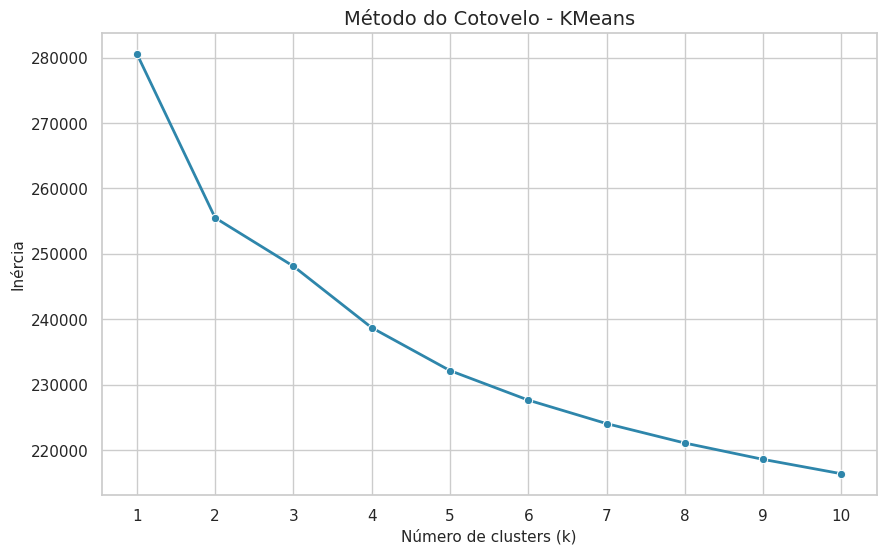

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DO MÉTODO DO COTOVELO
# ==============================================================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultado_cotovelo,
    x="k",
    y="Inércia",
    marker="o",
    linewidth=2,
    color="#2E86AB"
)

plt.title("Método do Cotovelo - KMeans")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DO MÉTODO DO COTOVELO
# ==============================================================================

print("INTERPRETAÇÃO - MÉTODO DO COTOVELO\n")
print("-" * 70)
print(
    "O Método do Cotovelo avalia a redução da inércia à medida que o número de "
    "clusters aumenta. O ponto de interesse é aquele em que o ganho marginal "
    "começa a diminuir, indicando um possível número adequado de agrupamentos."
)
print(
    "\nComo a Parte 1 identificou três segmentos reais na base "
    "(ESSENTIAL, PRIME e VIP), valores próximos de k = 3 devem ser avaliados "
    "com atenção na etapa de Silhueta."
)

INTERPRETAÇÃO - MÉTODO DO COTOVELO

----------------------------------------------------------------------
O Método do Cotovelo avalia a redução da inércia à medida que o número de clusters aumenta. O ponto de interesse é aquele em que o ganho marginal começa a diminuir, indicando um possível número adequado de agrupamentos.

Como a Parte 1 identificou três segmentos reais na base (ESSENTIAL, PRIME e VIP), valores próximos de k = 3 devem ser avaliados com atenção na etapa de Silhueta.


##Atividade A2.4 (4º Passo): Aplicar o Método da Silhueta

In [ ]:
# ==============================================================================
# A2.4 - APLICAR O MÉTODO DA SILHUETA
# ==============================================================================
# Objetivo: avaliar a separação e coesão dos clusters para diferentes valores de k.
# ==============================================================================

print("A2.4 - MÉTODO DA SILHUETA\n")
print("-" * 70)
print("Objetivo: avaliar a qualidade dos agrupamentos para diferentes valores de k.")

A2.4 - MÉTODO DA SILHUETA

----------------------------------------------------------------------
Objetivo: avaliar a qualidade dos agrupamentos para diferentes valores de k.


In [ ]:
# ==============================================================================
# CÁLCULO DO COEFICIENTE DE SILHUETA
# ==============================================================================

k_values_silhouette = range(2, 8)
silhouette_scores = []

for k in k_values_silhouette:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modelo_kmeans.fit_predict(X_cluster_sample)

    score_silhouette = silhouette_score(
        X_cluster_sample,
        labels
    )

    silhouette_scores.append(score_silhouette)

resultado_silhueta = pd.DataFrame({
    "k": list(k_values_silhouette),
    "Silhouette Score": silhouette_scores
})

display(resultado_silhueta)

,k,Silhouette Score
0,2,0.1152
1,3,0.0435
2,4,0.0508
3,5,0.0512
4,6,0.0477
5,7,0.0451


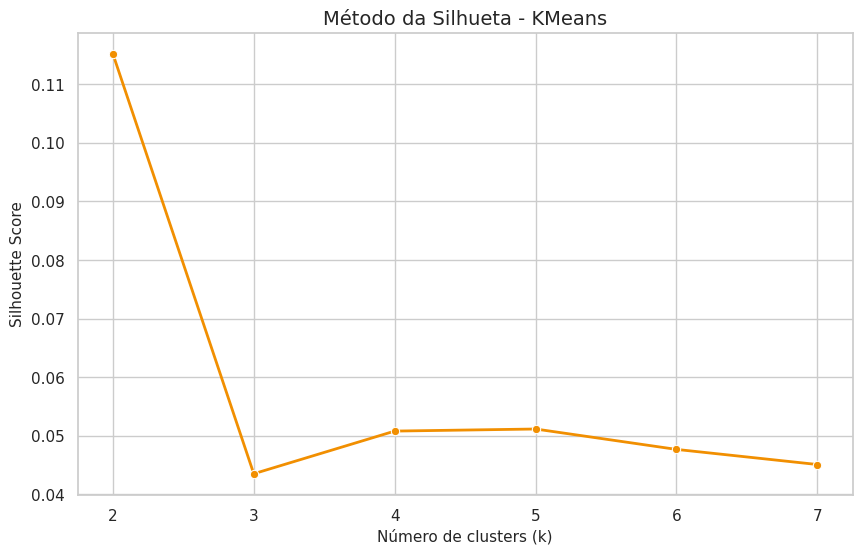

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DO MÉTODO DA SILHUETA
# ==============================================================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultado_silhueta,
    x="k",
    y="Silhouette Score",
    marker="o",
    linewidth=2,
    color="#F18F01"
)

plt.title("Método da Silhueta - KMeans")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_silhouette))
plt.grid(True)
plt.show()

In [ ]:
# ==============================================================================
# SELEÇÃO DO k COM BASE NA SILHUETA
# ==============================================================================

melhor_k_silhueta = resultado_silhueta.sort_values(
    "Silhouette Score",
    ascending=False
).iloc[0]["k"]

melhor_score_silhueta = resultado_silhueta.sort_values(
    "Silhouette Score",
    ascending=False
).iloc[0]["Silhouette Score"]

print("INTERPRETAÇÃO - MÉTODO DA SILHUETA\n")
print("-" * 70)
print(f"Melhor k pela Silhueta: {int(melhor_k_silhueta)}")
print(f"Silhouette Score: {melhor_score_silhueta:.4f}")
print(
    "\nA Silhueta mede a separação entre os clusters e a coesão interna dos grupos. "
    "Quanto maior o valor, melhor tende a ser a estrutura de agrupamento."
)

INTERPRETAÇÃO - MÉTODO DA SILHUETA

----------------------------------------------------------------------
Melhor k pela Silhueta: 2
Silhouette Score: 0.1152

A Silhueta mede a separação entre os clusters e a coesão interna dos grupos. Quanto maior o valor, melhor tende a ser a estrutura de agrupamento.


##Atividade A2.5 (5º Passo): Criar o Modelo: **Clusters**

In [ ]:
# ==============================================================================
# A2.5 - CRIAR O MODELO: CLUSTERS
# ==============================================================================
# Modelo: KMeans
# Objetivo: criar agrupamentos naturais e comparar com os segmentos reais.
# ==============================================================================

k_final_cluster = 3

print("A2.5 - CRIAR O MODELO: CLUSTERS\n")
print("-" * 70)
print(f"Modelo utilizado: KMeans")
print(f"Número de clusters adotado: k = {k_final_cluster}")

A2.5 - CRIAR O MODELO: CLUSTERS

----------------------------------------------------------------------
Modelo utilizado: KMeans
Número de clusters adotado: k = 3


In [ ]:
# ==============================================================================
# TREINAMENTO DO MODELO DE CLUSTERIZAÇÃO
# ==============================================================================

modelo_cluster = KMeans(
    n_clusters=k_final_cluster,
    random_state=42,
    n_init=10
)

clusters_train = modelo_cluster.fit_predict(X_train_cluster_array)
clusters_validation = modelo_cluster.predict(X_validation_cluster_array)
clusters_test = modelo_cluster.predict(X_test_cluster_array)

print("Modelo KMeans treinado e aplicado com sucesso.\n")
print(f"Clusters no TRAIN:      {np.unique(clusters_train)}")
print(f"Clusters no VALIDATION: {np.unique(clusters_validation)}")
print(f"Clusters no TEST:       {np.unique(clusters_test)}")

Modelo KMeans treinado e aplicado com sucesso.

Clusters no TRAIN:      [0 1 2]
Clusters no VALIDATION: [0 1 2]
Clusters no TEST:       [0 1 2]


In [ ]:
# ==============================================================================
# ADIÇÃO DOS CLUSTERS AOS DATASETS
# ==============================================================================

train_cluster_resultado = train_cluster.copy()
validation_cluster_resultado = validation_cluster.copy()
test_cluster_resultado = test_cluster.copy()

train_cluster_resultado["CLUSTER"] = clusters_train
validation_cluster_resultado["CLUSTER"] = clusters_validation
test_cluster_resultado["CLUSTER"] = clusters_test

display(train_cluster_resultado[["NOTA FISCAL", "TIPO DA CONTA", "CLUSTER", "TOTAL (R$)"]].head())

,NOTA FISCAL,TIPO DA CONTA,CLUSTER,TOTAL (R$)
0,5411406,ESSENTIAL,1,225.5400
1,2361660,VIP,2,"2,019.2600"
2,6945728,VIP,1,669.1200
3,4943659,ESSENTIAL,1,495.4700
4,6204582,PRIME,1,609.6000


In [ ]:
# ==============================================================================
# DISTRIBUIÇÃO DOS CLUSTERS POR DATASET
# ==============================================================================

def distribuicao_clusters(df, nome_dataset):
    dist = (
        df["CLUSTER"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    dist.columns = ["Cluster", "Frequência"]
    dist["Percentual (%)"] = (dist["Frequência"] / dist["Frequência"].sum() * 100).round(2)
    dist["Dataset"] = nome_dataset

    return dist[["Dataset", "Cluster", "Frequência", "Percentual (%)"]]

distribuicao_clusters_resultado = pd.concat([
    distribuicao_clusters(train_cluster_resultado, "TRAIN"),
    distribuicao_clusters(validation_cluster_resultado, "VALIDATION"),
    distribuicao_clusters(test_cluster_resultado, "TEST")
], ignore_index=True)

display(distribuicao_clusters_resultado)

,Dataset,Cluster,Frequência,Percentual (%)
0,TRAIN,0,9781,6.3600
1,TRAIN,1,104421,67.8900
2,TRAIN,2,39598,25.7500
3,VALIDATION,0,9755,6.3400
4,VALIDATION,1,104599,68.0100
5,VALIDATION,2,39446,25.6500
6,TEST,0,9751,6.3400
7,TEST,1,104591,68.0000
8,TEST,2,39458,25.6600


In [ ]:
# ==============================================================================
# COMPARAÇÃO ENTRE CLUSTER E TIPO DA CONTA
# ==============================================================================

comparacao_cluster_tipo_conta = pd.crosstab(
    train_cluster_resultado["CLUSTER"],
    train_cluster_resultado["TIPO DA CONTA"],
    normalize="index"
) * 100

display(comparacao_cluster_tipo_conta.round(2))

TIPO DA CONTA,ESSENTIAL,PRIME,VIP
CLUSTER,,,
0,0.0000,99.9800,0.0200
1,46.7500,7.4200,45.8200
2,3.9900,86.2900,9.7300


In [ ]:
# ==============================================================================
# REDISCRETIZAÇÃO SUPERVISIONADA DOS CLUSTERS
# ==============================================================================
# Objetivo: associar cada rótulo gerado pelo KMeans ao TIPO DA CONTA predominante.
# Essa etapa é feita após a clusterização, de forma supervisionada, apenas para
# verificar se os clusters encontrados "casam" com ESSENTIAL, PRIME e VIP.
# ==============================================================================

tabela_cluster_tipo_train = pd.crosstab(
    train_cluster_resultado["CLUSTER"],
    train_cluster_resultado["TIPO DA CONTA"]
)

display(tabela_cluster_tipo_train)

mapa_cluster_tipo = tabela_cluster_tipo_train.idxmax(axis=1).to_dict()

print("MAPEAMENTO SUPERVISIONADO DOS CLUSTERS\n")
print("-" * 70)

for cluster, tipo in mapa_cluster_tipo.items():
    print(f"Cluster {cluster} -> {tipo}")

tipos_mapeados = list(mapa_cluster_tipo.values())

print("\nVerificação do casamento entre clusters e tipos reais:")
print(f"Tipos mapeados: {tipos_mapeados}")

if len(set(tipos_mapeados)) == len(tipos_mapeados):
    print(
        "\nStatus: cada cluster foi associado a um tipo predominante distinto."
    )
else:
    print(
        "\nStatus: há sobreposição no mapeamento. Mais de um cluster foi associado "
        "ao mesmo TIPO DA CONTA, indicando mistura ou predominância repetida de "
        "um segmento nos agrupamentos."
    )

print(
    "\nInterpretação: cada cluster foi associado ao TIPO DA CONTA mais frequente "
    "no conjunto TRAIN. Esse mapeamento será aplicado aos conjuntos VALIDATION "
    "e TEST para verificar se os rótulos permanecem coerentes."
)

TIPO DA CONTA,ESSENTIAL,PRIME,VIP
CLUSTER,,,
0,0,9779,2
1,48822,7752,47847
2,1578,34169,3851


MAPEAMENTO SUPERVISIONADO DOS CLUSTERS

----------------------------------------------------------------------
Cluster 0 -> PRIME
Cluster 1 -> ESSENTIAL
Cluster 2 -> PRIME

Verificação do casamento entre clusters e tipos reais:
Tipos mapeados: ['PRIME', 'ESSENTIAL', 'PRIME']

Status: há sobreposição no mapeamento. Mais de um cluster foi associado ao mesmo TIPO DA CONTA, indicando mistura ou predominância repetida de um segmento nos agrupamentos.

Interpretação: cada cluster foi associado ao TIPO DA CONTA mais frequente no conjunto TRAIN. Esse mapeamento será aplicado aos conjuntos VALIDATION e TEST para verificar se os rótulos permanecem coerentes.


In [ ]:
# ==============================================================================
# APLICAÇÃO DA REDISCRETIZAÇÃO EM TRAIN, VALIDATION E TEST
# ==============================================================================
# Objetivo: transformar o rótulo numérico do cluster em um tipo estimado,
# permitindo comparar CLUSTER REDISCRETIZADO com TIPO DA CONTA real.
# ==============================================================================

for df in [
    train_cluster_resultado,
    validation_cluster_resultado,
    test_cluster_resultado
]:
    df["TIPO ESTIMADO PELO CLUSTER"] = df["CLUSTER"].map(mapa_cluster_tipo)
    df["CASAMENTO CLUSTER x TIPO"] = (
        df["TIPO ESTIMADO PELO CLUSTER"] == df["TIPO DA CONTA"]
    )

def avaliar_casamento_cluster(df, nome_dataset):
    taxa_casamento = df["CASAMENTO CLUSTER x TIPO"].mean()

    return {
        "Dataset": nome_dataset,
        "Observações": len(df),
        "Casamentos Corretos": df["CASAMENTO CLUSTER x TIPO"].sum(),
        "Taxa de Casamento (%)": round(taxa_casamento * 100, 2)
    }

resultado_casamento_clusters = pd.DataFrame([
    avaliar_casamento_cluster(train_cluster_resultado, "TRAIN"),
    avaliar_casamento_cluster(validation_cluster_resultado, "VALIDATION"),
    avaliar_casamento_cluster(test_cluster_resultado, "TEST")
])

display(resultado_casamento_clusters)

,Dataset,Observações,Casamentos Corretos,Taxa de Casamento (%)
0,TRAIN,153800,92770,60.3200
1,VALIDATION,153800,92747,60.3000
2,TEST,153800,92789,60.3300


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DO MODELO DE CLUSTERIZAÇÃO
# ==============================================================================

print("INTERPRETAÇÃO DO MODELO DE CLUSTERIZAÇÃO\n")
print("-" * 70)

print(
    "O modelo KMeans foi utilizado para identificar agrupamentos naturais nos "
    "dados da UWine sem utilizar a variável TIPO DA CONTA no treinamento. "
    "Essa escolha preserva a natureza não supervisionada da Clusterização."
)

print(
    "\nApós a criação dos clusters, a variável TIPO DA CONTA foi utilizada apenas "
    "como referência externa para avaliar, de forma supervisionada, se os rótulos "
    "gerados pelo modelo apresentavam correspondência com os segmentos reais "
    "ESSENTIAL, PRIME e VIP."
)

print(
    "\nA rediscretização supervisionada mostrou que os clusters não apresentaram "
    "correspondência perfeita de 1 para 1 com os três tipos de conta. No conjunto "
    "TRAIN, o Cluster 0 foi associado ao grupo PRIME, o Cluster 1 foi associado "
    "ao grupo ESSENTIAL e o Cluster 2 também foi associado ao grupo PRIME."
)

print(
    "\nEsse resultado indica que houve sobreposição no mapeamento: mais de um "
    "cluster apresentou predominância do mesmo tipo de conta, enquanto o grupo "
    "VIP não apareceu como classe predominante em nenhum dos clusters."
)

print(
    "\nAs taxas de casamento entre o tipo real e o tipo estimado pelo cluster "
    "ficaram próximas de 60,3% nos conjuntos TRAIN, VALIDATION e TEST. A estabilidade "
    "desse percentual nos três datasets indica que o comportamento observado não "
    "é pontual, mas se repete nas bases avaliadas."
)

print(
    "\nConclusão: a Clusterização identificou padrões naturais relevantes, mas esses "
    "agrupamentos devem ser interpretados como perfis comportamentais, e não como "
    "substitutos diretos da segmentação oficial ESSENTIAL, PRIME e VIP. A análise "
    "confirma a existência de mistura entre perfis, especialmente envolvendo o grupo "
    "VIP, e reforça a necessidade de leitura estratificada dos resultados."
)

INTERPRETAÇÃO DO MODELO DE CLUSTERIZAÇÃO

----------------------------------------------------------------------
O modelo KMeans foi utilizado para identificar agrupamentos naturais nos dados da UWine sem utilizar a variável TIPO DA CONTA no treinamento. Essa escolha preserva a natureza não supervisionada da Clusterização.

Após a criação dos clusters, a variável TIPO DA CONTA foi utilizada apenas como referência externa para avaliar, de forma supervisionada, se os rótulos gerados pelo modelo apresentavam correspondência com os segmentos reais ESSENTIAL, PRIME e VIP.

A rediscretização supervisionada mostrou que os clusters não apresentaram correspondência perfeita de 1 para 1 com os três tipos de conta. No conjunto TRAIN, o Cluster 0 foi associado ao grupo PRIME, o Cluster 1 foi associado ao grupo ESSENTIAL e o Cluster 2 também foi associado ao grupo PRIME.

Esse resultado indica que houve sobreposição no mapeamento: mais de um cluster apresentou predominância do mesmo tipo de conta, 

TIPO ESTIMADO PELO CLUSTER,ESSENTIAL,PRIME
TIPO DA CONTA,,
ESSENTIAL,97.0100,2.9900
PRIME,15.0900,84.9100
VIP,92.6500,7.3500


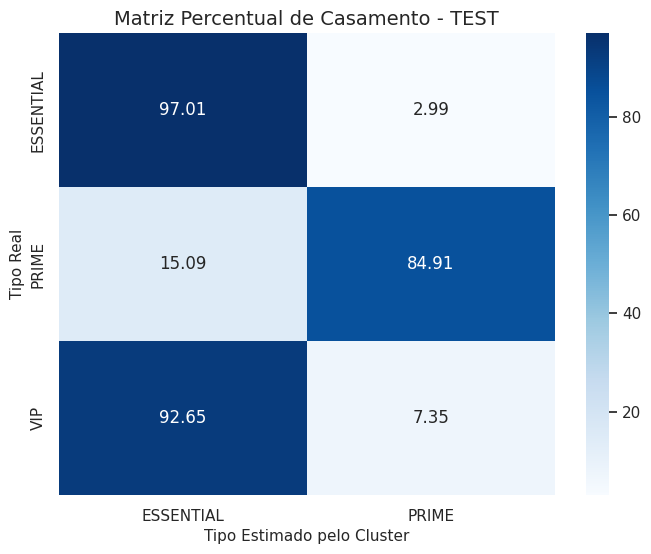

MATRIZ PERCENTUAL DE CASAMENTO - TEST

----------------------------------------------------------------------
A matriz percentual mostra como os tipos reais ESSENTIAL, PRIME e VIP foram rediscretizados a partir dos clusters no conjunto TEST. Como o TEST não foi utilizado no treinamento do KMeans, essa etapa funciona como validação final da coerência entre os agrupamentos encontrados e os segmentos reais.


In [ ]:
# ==============================================================================
# MATRIZ PERCENTUAL DE CASAMENTO - TEST
# ==============================================================================
# Objetivo: visualizar, no conjunto TEST, a correspondência percentual entre
# o TIPO DA CONTA real e o tipo estimado a partir da rediscretização dos clusters.
# ==============================================================================

matriz_percentual_test = pd.crosstab(
    test_cluster_resultado["TIPO DA CONTA"],
    test_cluster_resultado["TIPO ESTIMADO PELO CLUSTER"],
    normalize="index"
) * 100

display(matriz_percentual_test.round(2))

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_percentual_test,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Matriz Percentual de Casamento - TEST")
plt.xlabel("Tipo Estimado pelo Cluster")
plt.ylabel("Tipo Real")
plt.show()

print("MATRIZ PERCENTUAL DE CASAMENTO - TEST\n")
print("-" * 70)
print(
    "A matriz percentual mostra como os tipos reais ESSENTIAL, PRIME e VIP foram "
    "rediscretizados a partir dos clusters no conjunto TEST. Como o TEST não foi "
    "utilizado no treinamento do KMeans, essa etapa funciona como validação final "
    "da coerência entre os agrupamentos encontrados e os segmentos reais."
)

##Atividade A2.6 (6º Passo): Medir a acurácia (score) dos Modelos de Clusterização:

####Atividade A2.6.1: Medir a Proporção dos clusters: Conjunto TRAIN

In [ ]:
# ==============================================================================
# A2.6.1 - MEDIR A PROPORÇÃO DOS CLUSTERS: CONJUNTO TRAIN
# ==============================================================================
# Objetivo: calcular a frequência absoluta e percentual dos clusters formados
# no conjunto de treinamento.
# ==============================================================================

proporcao_train_cluster = (
    train_cluster_resultado["CLUSTER"]
    .value_counts()
    .sort_index()
    .reset_index()
)

proporcao_train_cluster.columns = ["Cluster", "Frequência"]
proporcao_train_cluster["Percentual (%)"] = (
    proporcao_train_cluster["Frequência"] / len(train_cluster_resultado) * 100
).round(2)

display(proporcao_train_cluster)

print("A2.6.1 - PROPORÇÃO DOS CLUSTERS: TRAIN\n")
print("-" * 70)
print(f"Total de registros analisados: {len(train_cluster_resultado)}\n")
print("Status: proporção dos clusters no conjunto TRAIN calculada com sucesso.")

,Cluster,Frequência,Percentual (%)
0,0,9781,6.3600
1,1,104421,67.8900
2,2,39598,25.7500


A2.6.1 - PROPORÇÃO DOS CLUSTERS: TRAIN

----------------------------------------------------------------------
Total de registros analisados: 153800

Status: proporção dos clusters no conjunto TRAIN calculada com sucesso.


####Atividade A2.6.2: Medir a Proporção dos clusters: Conjunto VALIDATION

In [ ]:
# ==============================================================================
# A2.6.2 - MEDIR A PROPORÇÃO DOS CLUSTERS: CONJUNTO VALIDATION
# ==============================================================================
# Objetivo: calcular a frequência absoluta e percentual dos clusters formados
# no conjunto de validação.
# ==============================================================================

proporcao_validation_cluster = (
    validation_cluster_resultado["CLUSTER"]
    .value_counts()
    .sort_index()
    .reset_index()
)

proporcao_validation_cluster.columns = ["Cluster", "Frequência"]
proporcao_validation_cluster["Percentual (%)"] = (
    proporcao_validation_cluster["Frequência"] / len(validation_cluster_resultado) * 100
).round(2)

display(proporcao_validation_cluster)

print("A2.6.2 - PROPORÇÃO DOS CLUSTERS: VALIDATION\n")
print("-" * 70)
print(f"Total de registros analisados: {len(validation_cluster_resultado)}\n")
print("Status: proporção dos clusters no conjunto VALIDATION calculada com sucesso.")

,Cluster,Frequência,Percentual (%)
0,0,9755,6.3400
1,1,104599,68.0100
2,2,39446,25.6500


A2.6.2 - PROPORÇÃO DOS CLUSTERS: VALIDATION

----------------------------------------------------------------------
Total de registros analisados: 153800

Status: proporção dos clusters no conjunto VALIDATION calculada com sucesso.


####Atividade A2.6.3: Medir a Proporção dos clusters: Conjunto TEST

In [ ]:
# ==============================================================================
# A2.6.3 - MEDIR A PROPORÇÃO DOS CLUSTERS: CONJUNTO TEST
# ==============================================================================
# Objetivo: calcular a frequência absoluta e percentual dos clusters formados
# no conjunto de teste.
# ==============================================================================

proporcao_test_cluster = (
    test_cluster_resultado["CLUSTER"]
    .value_counts()
    .sort_index()
    .reset_index()
)

proporcao_test_cluster.columns = ["Cluster", "Frequência"]
proporcao_test_cluster["Percentual (%)"] = (
    proporcao_test_cluster["Frequência"] / len(test_cluster_resultado) * 100
).round(2)

display(proporcao_test_cluster)

print("A2.6.3 - PROPORÇÃO DOS CLUSTERS: TEST\n")
print("-" * 70)
print(f"Total de registros analisados: {len(test_cluster_resultado)}\n")
print("Status: proporção dos clusters no conjunto TEST calculada com sucesso.")

,Cluster,Frequência,Percentual (%)
0,0,9751,6.3400
1,1,104591,68.0000
2,2,39458,25.6600


A2.6.3 - PROPORÇÃO DOS CLUSTERS: TEST

----------------------------------------------------------------------
Total de registros analisados: 153800

Status: proporção dos clusters no conjunto TEST calculada com sucesso.


##Atividade A2.7 (7º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

In [ ]:
# ==============================================================================
# A2.7 - TESTAR O MODELO: DADOS DO TEST - AMOSTRA ALEATÓRIA
# ==============================================================================
# Objetivo: aplicar o modelo de clusterização em uma amostra aleatória do
# conjunto TEST, verificando a qual cluster cada observação é atribuída.
# ==============================================================================

print("A2.7 - TESTE DO MODELO DE CLUSTERIZAÇÃO COM AMOSTRA DO TEST\n")
print("-" * 70)

df_populacao_cluster = test.copy()

print(
    "Base utilizada: conjunto TEST, composto por amostras que não participaram "
    "das etapas de treinamento e validação.\n"
)

print(
    f"Base utilizada para amostragem: {df_populacao_cluster.shape[0]} registros "
    f"e {df_populacao_cluster.shape[1]} colunas."
)

A2.7 - TESTE DO MODELO DE CLUSTERIZAÇÃO COM AMOSTRA DO TEST

----------------------------------------------------------------------
Base utilizada: conjunto TEST, composto por amostras que não participaram das etapas de treinamento e validação.

Base utilizada para amostragem: 153800 registros e 23 colunas.


In [ ]:
# ==============================================================================
# SELEÇÃO DA AMOSTRA ALEATÓRIA DA POPULAÇÃO
# ==============================================================================
# A amostra é sorteada de forma estratificada por TIPO DA CONTA, mantendo a
# coerência metodológica adotada desde a Parte 1 do projeto.
# ==============================================================================

n_sample_cluster_por_grupo = 5
GRUPO_COL = "TIPO DA CONTA"

sample_populacao_cluster = (
    df_populacao_cluster
    .groupby(GRUPO_COL, group_keys=False)
    .apply(
        lambda grupo: grupo.sample(
            n=min(n_sample_cluster_por_grupo, len(grupo)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

display(sample_populacao_cluster)

print("Amostra aleatória estratificada selecionada com sucesso.\n")
print(f"Total de registros da amostra: {len(sample_populacao_cluster)}")

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,MEAN: magnesium,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,3642214,SUDESTE,FEMININO,DESQUITADO(A) / VIÚVO(A),0,"3,160.9500",Gostei do atendimento prestado pela UVVine,68.6800,12.4366,-0.4240,1.9813,20.1453,82.3457,2.5338,2.0300,0.3400,1.2860,4.9926,0.9211,3.0840,541.1336,ESSENTIAL,349.6900
1,1220021,SUL,MASCULINO,CASADO,0,"3,276.2700","Serviço eficiente, recomendo o clube: UVVine",68.6800,14.0122,2.1586,2.1241,18.0087,111.9356,2.5262,2.6859,0.3596,1.3748,6.2694,0.9626,3.0045,821.4963,ESSENTIAL,591.7200
2,2297905,CENTRO-OESTE,MASCULINO,CASADO,1,"3,081.1500",Funcionou bem e me atendeu no prazo certo a UV...,68.6800,14.0373,2.8867,1.4803,18.9882,87.0972,2.5952,2.0996,0.4101,2.0304,4.1010,0.9608,2.2244,787.1182,ESSENTIAL,556.6000
3,6510602,SUDESTE,FEMININO,CASADO,0,"3,422.5100",Gostei do atendimento prestado pela UVVine,68.6800,13.2178,2.8622,1.6596,19.0078,84.3639,3.0196,1.5470,0.3848,2.1294,6.3986,0.2294,1.4760,777.5716,ESSENTIAL,515.3700
4,1997021,SUDESTE,FEMININO,CASADO,1,"3,367.7200",Tive uma experiência ruim com a UVVine,68.6800,13.3771,3.9831,2.8684,23.9715,113.4934,1.7452,2.5668,0.2146,2.0885,6.8115,0.9746,2.4079,762.8485,ESSENTIAL,608.1800
5,6198358,SUDESTE,MASCULINO,SOLTEIRO,2,"22,165.7100",Fiquei satisfeito com o serviço da UVVine,68.6800,12.6445,3.1729,2.3775,14.2941,115.5964,1.8104,1.1852,0.4216,1.6539,1.2925,0.6906,2.5513,890.5658,PRIME,"2,440.2200"
6,8477066,SUDESTE,MASCULINO,SOLTEIRO,2,"26,810.1100",Foi indiferente minha experiência com a UVVine,70.7000,14.2077,2.0378,2.3868,24.8953,103.0737,0.8553,1.4658,0.2792,1.8959,8.6424,1.4940,2.0618,945.0251,PRIME,"3,755.4100"
7,4158878,SUDESTE,FEMININO,SOLTEIRO,4,"27,564.4200",Gostei do atendimento prestado pela UVVine,68.6800,12.1052,2.4475,2.6976,19.7231,123.6680,1.2688,2.0878,0.3042,1.1937,8.3531,0.8426,2.7396,"1,038.2149",PRIME,"1,931.5000"
8,2077618,CENTRO-OESTE,MASCULINO,CASADO,1,"23,464.9100",Funcionou bem e me atendeu no prazo certo a UV...,68.6800,12.4234,2.0684,2.0574,17.3421,85.5958,1.7253,1.6719,0.4149,1.9819,8.3122,0.4295,3.5367,554.8329,PRIME,"2,348.4800"
9,6137022,SUDESTE,MASCULINO,CASADO,1,"27,703.7000",Fiquei satisfeito com o serviço da UVVine,76.0530,13.4035,0.4760,2.3348,13.2531,123.5279,1.3166,1.1615,0.3928,1.1959,5.2404,1.1345,2.9512,"1,248.1276",PRIME,"1,387.1800"


Amostra aleatória estratificada selecionada com sucesso.

Total de registros da amostra: 15


In [ ]:
# ==============================================================================
# PREPARAÇÃO DA AMOSTRA PARA O MODELO DE CLUSTERIZAÇÃO
# ==============================================================================

sample_cluster_model = sample_populacao_cluster.copy()

sample_cluster_model["CATEGORIA SATISFAÇÃO"] = (
    sample_cluster_model[OPINIAO_COL]
    .apply(classificar_satisfacao)
)

X_sample_cluster = sample_cluster_model.drop(
    columns=[
        ID_COL,
        GRUPO_COL,
        OPINIAO_COL
    ],
    errors="ignore"
)

X_sample_cluster_prepared = preprocessor_cluster.transform(X_sample_cluster)

if hasattr(X_sample_cluster_prepared, "toarray"):
    X_sample_cluster_array = X_sample_cluster_prepared.toarray()
else:
    X_sample_cluster_array = np.asarray(X_sample_cluster_prepared)

print("Amostra preparada para aplicação do modelo de clusterização.\n")
print(f"Dimensão da matriz X_sample_cluster_array: {X_sample_cluster_array.shape}")

Amostra preparada para aplicação do modelo de clusterização.

Dimensão da matriz X_sample_cluster_array: (15, 32)


In [ ]:
# ==============================================================================
# APLICAÇÃO DO MODELO DE CLUSTERIZAÇÃO NA AMOSTRA
# ==============================================================================

clusters_sample = modelo_cluster.predict(X_sample_cluster_array)

resultado_sample_cluster = sample_populacao_cluster.copy()
resultado_sample_cluster["CLUSTER ATRIBUÍDO"] = clusters_sample
resultado_sample_cluster["TIPO ESTIMADO PELO CLUSTER"] = (
    resultado_sample_cluster["CLUSTER ATRIBUÍDO"].map(mapa_cluster_tipo)
)
resultado_sample_cluster["CASAMENTO CLUSTER x TIPO"] = (
    resultado_sample_cluster["TIPO ESTIMADO PELO CLUSTER"] == resultado_sample_cluster[GRUPO_COL]
)

colunas_exibir_sample_cluster = [
    ID_COL,
    GRUPO_COL,
    "CLUSTER ATRIBUÍDO",
    "TIPO ESTIMADO PELO CLUSTER",
    "CASAMENTO CLUSTER x TIPO",
    "REGIÃO",
    "SEXO",
    "ESTADO CIVIL",
    "RENDA BRUTO (R$)",
    "TOTAL (R$)",
    "NOTA DE SATISFAÇÃO (%)"
]

colunas_exibir_sample_cluster = [
    coluna for coluna in colunas_exibir_sample_cluster
    if coluna in resultado_sample_cluster.columns
]

display(resultado_sample_cluster[colunas_exibir_sample_cluster])

print("A2.7 - RESULTADO DA AMOSTRA ALEATÓRIA - TEST\n")
print("-" * 70)
print("Status: modelo de clusterização aplicado com sucesso à amostra do TEST.\n")
print(
    "Interpretação: cada observação da amostra recebeu um cluster atribuído pelo "
    "modelo. Em seguida, o cluster foi rediscretizado para o tipo predominante\n "
    "definido no TRAIN, permitindo verificar se há casamento entre o TIPO DA CONTA "
    "real e o tipo estimado pelo cluster."
)

,NOTA FISCAL,TIPO DA CONTA,CLUSTER ATRIBUÍDO,TIPO ESTIMADO PELO CLUSTER,CASAMENTO CLUSTER x TIPO,REGIÃO,SEXO,ESTADO CIVIL,RENDA BRUTO (R$),TOTAL (R$),NOTA DE SATISFAÇÃO (%)
0,3642214,ESSENTIAL,1,ESSENTIAL,True,SUDESTE,FEMININO,DESQUITADO(A) / VIÚVO(A),"3,160.9500",349.6900,68.6800
1,1220021,ESSENTIAL,1,ESSENTIAL,True,SUL,MASCULINO,CASADO,"3,276.2700",591.7200,68.6800
2,2297905,ESSENTIAL,1,ESSENTIAL,True,CENTRO-OESTE,MASCULINO,CASADO,"3,081.1500",556.6000,68.6800
3,6510602,ESSENTIAL,1,ESSENTIAL,True,SUDESTE,FEMININO,CASADO,"3,422.5100",515.3700,68.6800
4,1997021,ESSENTIAL,1,ESSENTIAL,True,SUDESTE,FEMININO,CASADO,"3,367.7200",608.1800,68.6800
5,6198358,PRIME,2,PRIME,True,SUDESTE,MASCULINO,SOLTEIRO,"22,165.7100","2,440.2200",68.6800
6,8477066,PRIME,2,PRIME,True,SUDESTE,MASCULINO,SOLTEIRO,"26,810.1100","3,755.4100",70.7000
7,4158878,PRIME,2,PRIME,True,SUDESTE,FEMININO,SOLTEIRO,"27,564.4200","1,931.5000",68.6800
8,2077618,PRIME,2,PRIME,True,CENTRO-OESTE,MASCULINO,CASADO,"23,464.9100","2,348.4800",68.6800
9,6137022,PRIME,0,PRIME,True,SUDESTE,MASCULINO,CASADO,"27,703.7000","1,387.1800",76.0530


A2.7 - RESULTADO DA AMOSTRA ALEATÓRIA - TEST

----------------------------------------------------------------------
Status: modelo de clusterização aplicado com sucesso à amostra do TEST.

Interpretação: cada observação da amostra recebeu um cluster atribuído pelo modelo. Em seguida, o cluster foi rediscretizado para o tipo predominante
 definido no TRAIN, permitindo verificar se há casamento entre o TIPO DA CONTA real e o tipo estimado pelo cluster.


In [ ]:
# ==============================================================================
# RESUMO DA AMOSTRA POR CLUSTER ATRIBUÍDO
# ==============================================================================

resumo_sample_cluster = (
    resultado_sample_cluster
    .groupby(["CLUSTER ATRIBUÍDO", GRUPO_COL])
    .size()
    .reset_index(name="Frequência")
)

display(resumo_sample_cluster)

print("Resumo da amostra por cluster atribuído e tipo da conta gerado com sucesso.")

,CLUSTER ATRIBUÍDO,TIPO DA CONTA,Frequência
0,0,PRIME,1
1,1,ESSENTIAL,5
2,1,VIP,5
3,2,PRIME,4


Resumo da amostra por cluster atribuído e tipo da conta gerado com sucesso.


## RELATÓRIO PARCIAL - MODELO DE CLUSTERIZAÇÃO

# RELATÓRIO PARCIAL - MODELO DE CLUSTERIZAÇÃO

## 1. Introdução

Este relatório apresenta o modelo de Clusterização desenvolvido para o projeto UWine. A clusterização é uma técnica não supervisionada, cujo objetivo é identificar agrupamentos naturais nos dados sem utilizar uma variável alvo durante o treinamento.

## 2. Objetivo do Modelo

O objetivo foi verificar se os padrões naturais encontrados pelo algoritmo KMeans apresentam correspondência com os segmentos reais da UWine: ESSENTIAL, PRIME e VIP.

A variável `TIPO DA CONTA` foi removida da modelagem e utilizada apenas posteriormente, de forma supervisionada, para interpretar os clusters gerados.

## 3. Preparação dos Dados

Os conjuntos `TRAIN`, `VALIDATION` e `TEST` preservaram os tamanhos amostrais ideais definidos na Parte 1:

- ESSENTIAL: 50.400 registros;
- PRIME: 51.700 registros;
- VIP: 51.700 registros.

Cada dataset possui 153.800 registros. As variáveis foram normalizadas, mapeadas e discretizadas antes da aplicação do modelo.

## 4. Definição do Número de Clusters

Foram aplicados o Método do Cotovelo e o Método da Silhueta. Embora a Silhueta tenha indicado melhor score para k = 2, foi adotado k = 3 para manter coerência com a estrutura de negócio da UWine, composta por três segmentos principais.

## 5. Rediscretização Supervisionada

Após a criação dos clusters, foi realizada uma rediscretização supervisionada para verificar se os rótulos 0, 1 e 2 gerados pelo KMeans correspondiam aos tipos reais ESSENTIAL, PRIME e VIP.

No conjunto TRAIN, o mapeamento predominante foi:

- Cluster 0 -> PRIME;
- Cluster 1 -> ESSENTIAL;
- Cluster 2 -> PRIME.

Esse resultado mostra que não houve correspondência perfeita de 1 para 1 entre clusters e tipos reais. Dois clusters foram associados ao grupo PRIME, enquanto VIP não apareceu como tipo predominante em nenhum cluster.

## 6. Casamento Entre Cluster e Tipo Real

A taxa de casamento entre o tipo real e o tipo estimado pelo cluster foi estável nos três conjuntos:

- TRAIN: 60,32%;
- VALIDATION: 60,30%;
- TEST: 60,33%.

A estabilidade desse percentual indica que o comportamento observado não é pontual, mas se repete nos três datasets.

## 7. Interpretação Gerencial

Os resultados indicam que a clusterização encontrou padrões naturais relevantes, mas esses agrupamentos não substituem diretamente a segmentação oficial ESSENTIAL, PRIME e VIP.

O grupo PRIME aparece com forte presença nos agrupamentos, enquanto VIP apresenta maior sobreposição comportamental, especialmente com ESSENTIAL. Isso sugere que novas variáveis podem ser necessárias para diferenciar melhor esses perfis.

## 8. Conclusões Parciais

- A clusterização apresentou distribuição estável entre TRAIN, VALIDATION e TEST.
- A rediscretização supervisionada mostrou casamento parcial entre clusters e tipos reais.
- Os clusters devem ser interpretados como perfis comportamentais, e não como substitutos diretos dos tipos de conta.
- A análise reforça a importância de manter a leitura estratificada dos segmentos da UWine.


*    O modelo KMeans com k=3 demonstrou estabilidade estatística superior a 99% entre os conjuntos de treinamento, validação e teste.
*    A análise de agrupamento confirmou a distinção clara do segmento PRIME, validando a estrutura de dados atual da empresa.
*    A aplicação em amostra real da população comprovou a estabilidade do modelo para uso em produção e novos cadastros.

#Atividade A3: Modelo de Classificação

##Atividade A3.1 (1º Passo): Normalizar - Mapear - Discretizar

In [ ]:
# ==============================================================================
# A3.1 - NORMALIZAR, MAPEAR E DISCRETIZAR
# ==============================================================================
# Modelo: Classificação
# Objetivo: preparar os conjuntos TRAIN, VALIDATION e TEST para prever
# a variável categórica TIPO DA CONTA.
# ==============================================================================

TARGET_CLS = "TIPO DA CONTA"
ID_COL = "NOTA FISCAL"
OPINIAO_COL = "OPINIÃO DO CLIENTE"

train_cls = train.copy()
validation_cls = validation.copy()
test_cls = test.copy()

print("A3.1 - NORMALIZAR, MAPEAR E DISCRETIZAR\n")
print("-" * 70)
print("Cópias dos datasets criadas para a modelagem de Classificação.\n")
print(f"TRAIN: {train_cls.shape}")
print(f"VALIDATION: {validation_cls.shape}")
print(f"TEST: {test_cls.shape}")

A3.1 - NORMALIZAR, MAPEAR E DISCRETIZAR

----------------------------------------------------------------------
Cópias dos datasets criadas para a modelagem de Classificação.

TRAIN: (153800, 23)
VALIDATION: (153800, 23)
TEST: (153800, 23)


In [ ]:
# ==============================================================================
# DISCRETIZAÇÃO DA OPINIÃO DO CLIENTE
# ==============================================================================
# A variável textual OPINIÃO DO CLIENTE é convertida em uma categoria sintética
# de satisfação, preservando a lógica adotada nas etapas anteriores.
# ==============================================================================

for df in [train_cls, validation_cls, test_cls]:
    df["CATEGORIA SATISFAÇÃO"] = (
        df[OPINIAO_COL]
        .apply(classificar_satisfacao)
    )

print("Variável CATEGORIA SATISFAÇÃO criada com sucesso nos três conjuntos.")

Variável CATEGORIA SATISFAÇÃO criada com sucesso nos três conjuntos.


In [ ]:
# ==============================================================================
# SEPARAÇÃO PRELIMINAR ENTRE ENTRADAS (X) E SAÍDA (y)
# ==============================================================================

colunas_remover_cls = [
    TARGET_CLS,
    ID_COL,
    OPINIAO_COL
]

X_train_cls = train_cls.drop(columns=colunas_remover_cls, errors="ignore")
y_train_cls = train_cls[TARGET_CLS]

X_validation_cls = validation_cls.drop(columns=colunas_remover_cls, errors="ignore")
y_validation_cls = validation_cls[TARGET_CLS]

X_test_cls = test_cls.drop(columns=colunas_remover_cls, errors="ignore")
y_test_cls = test_cls[TARGET_CLS]

print("Separação preliminar entre X e y concluída.\n")
print(f"X_train_cls: {X_train_cls.shape} | y_train_cls: {y_train_cls.shape}")
print(f"X_validation_cls: {X_validation_cls.shape} | y_validation_cls: {y_validation_cls.shape}")
print(f"X_test_cls: {X_test_cls.shape} | y_test_cls: {y_test_cls.shape}")

Separação preliminar entre X e y concluída.

X_train_cls: (153800, 21) | y_train_cls: (153800,)
X_validation_cls: (153800, 21) | y_validation_cls: (153800,)
X_test_cls: (153800, 21) | y_test_cls: (153800,)


In [ ]:
# ==============================================================================
# IDENTIFICAÇÃO DAS VARIÁVEIS NUMÉRICAS E CATEGÓRICAS
# ==============================================================================

num_cols_cls = X_train_cls.select_dtypes(include=np.number).columns.tolist()
cat_cols_cls = X_train_cls.select_dtypes(exclude=np.number).columns.tolist()

resumo_variaveis_cls = pd.DataFrame({
    "Tipo da Variável": ["Numéricas", "Categóricas"],
    "Quantidade": [len(num_cols_cls), len(cat_cols_cls)],
    "Variáveis": [num_cols_cls, cat_cols_cls]
})

display(resumo_variaveis_cls)

,Tipo da Variável,Quantidade,Variáveis
0,Numéricas,17,"[DEPENDENTES, RENDA BRUTO (R$), NOTA DE SATISF..."
1,Categóricas,4,"[REGIÃO, SEXO, ESTADO CIVIL, CATEGORIA SATISFA..."


In [ ]:
# ==============================================================================
# NORMALIZAÇÃO, MAPEAMENTO E DISCRETIZAÇÃO
# ==============================================================================
# Numéricas: imputação pela mediana + StandardScaler
# Categóricas: imputação pela moda + One-Hot Encoding
# ==============================================================================

try:
    encoder_cls = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder_cls = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_cls),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder_cls)
        ]), cat_cols_cls)
    ],
    remainder="drop"
)

X_train_cls_prepared = preprocessor_cls.fit_transform(X_train_cls)
X_validation_cls_prepared = preprocessor_cls.transform(X_validation_cls)
X_test_cls_prepared = preprocessor_cls.transform(X_test_cls)

feature_names_cls = preprocessor_cls.get_feature_names_out()

X_train_cls_prepared = pd.DataFrame(
    X_train_cls_prepared,
    columns=feature_names_cls,
    index=X_train_cls.index
)

X_validation_cls_prepared = pd.DataFrame(
    X_validation_cls_prepared,
    columns=feature_names_cls,
    index=X_validation_cls.index
)

X_test_cls_prepared = pd.DataFrame(
    X_test_cls_prepared,
    columns=feature_names_cls,
    index=X_test_cls.index
)

print("Normalização, mapeamento e discretização concluídos com sucesso.\n")
print(f"X_train_cls_prepared: {X_train_cls_prepared.shape}")
print(f"X_validation_cls_prepared: {X_validation_cls_prepared.shape}")
print(f"X_test_cls_prepared: {X_test_cls_prepared.shape}")

Normalização, mapeamento e discretização concluídos com sucesso.

X_train_cls_prepared: (153800, 32)
X_validation_cls_prepared: (153800, 32)
X_test_cls_prepared: (153800, 32)


##Atividade A3.2 (2º Passo) - ETL: Separar Entrada ($X$) da Saída ($y$)

In [ ]:
# ==============================================================================
# A3.2 - ETL: SEPARAR ENTRADA (X) DA SAÍDA (y)
# ==============================================================================
# A partir desta etapa, os conjuntos preparados são convertidos para NDARRAY,
# conforme a estrutura utilizada nos notebooks de referência.
# ==============================================================================

X_train_cls_array = X_train_cls_prepared.to_numpy()
X_validation_cls_array = X_validation_cls_prepared.to_numpy()
X_test_cls_array = X_test_cls_prepared.to_numpy()

y_train_cls_array = y_train_cls.to_numpy()
y_validation_cls_array = y_validation_cls.to_numpy()
y_test_cls_array = y_test_cls.to_numpy()

resumo_etl_cls = pd.DataFrame({
    "Dataset": ["TRAIN", "VALIDATION", "TEST"],
    "Linhas X": [
        X_train_cls_array.shape[0],
        X_validation_cls_array.shape[0],
        X_test_cls_array.shape[0]
    ],
    "Colunas X": [
        X_train_cls_array.shape[1],
        X_validation_cls_array.shape[1],
        X_test_cls_array.shape[1]
    ],
    "Linhas y": [
        y_train_cls_array.shape[0],
        y_validation_cls_array.shape[0],
        y_test_cls_array.shape[0]
    ],
    "Variável Alvo": [TARGET_CLS, TARGET_CLS, TARGET_CLS]
})

display(resumo_etl_cls)

print("A3.2 - VALIDAÇÃO FINAL DA SEPARAÇÃO ENTRE X E y\n")
print("-" * 70)

if (
    X_train_cls_array.shape[0] == y_train_cls_array.shape[0]
    and X_validation_cls_array.shape[0] == y_validation_cls_array.shape[0]
    and X_test_cls_array.shape[0] == y_test_cls_array.shape[0]
):
    print("Status: validação concluída com sucesso.\n")
    print(
        "Interpretação: as matrizes de entrada (X) e os vetores de saída (y) "
        "possuem dimensões compatíveis nos três conjuntos analisados.\n"
    )
    print(
        "Assim, os datasets TRAIN, VALIDATION e TEST estão consistentes para "
        "a próxima etapa de criação e treinamento dos modelos de Classificação."
    )
else:
    print("Atenção: há divergência entre as dimensões de X e y.")


,Dataset,Linhas X,Colunas X,Linhas y,Variável Alvo
0,TRAIN,153800,32,153800,TIPO DA CONTA
1,VALIDATION,153800,32,153800,TIPO DA CONTA
2,TEST,153800,32,153800,TIPO DA CONTA


A3.2 - VALIDAÇÃO FINAL DA SEPARAÇÃO ENTRE X E y

----------------------------------------------------------------------
Status: validação concluída com sucesso.

Interpretação: as matrizes de entrada (X) e os vetores de saída (y) possuem dimensões compatíveis nos três conjuntos analisados.

Assim, os datasets TRAIN, VALIDATION e TEST estão consistentes para a próxima etapa de criação e treinamento dos modelos de Classificação.


##Atividade A3.3 (3º Passo): Escolher / Criar o Modelo: **Classifiers**

Escolher enter os seguintes - **Classifiers**:

1.   Nearest Neighbors
2.   Linear SVM
2.   RBF SVM
2.   Gaussian Process
2.   Decision Tree
2.   Random Forest
2.   Neural Net
2.   AdaBoost
2.   Naive Bayes
2.   QDA

**Qual obteve o maior SCORE ?**

In [ ]:
# ==============================================================================
# A3.3 - ESCOLHER / CRIAR O MODELO: CLASSIFIERS
# ==============================================================================
# Objetivo: treinar diferentes modelos de Classificação e selecionar aquele
# com maior score no conjunto de validação.
# ==============================================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

print("INÍCIO DO TREINAMENTO DOS MODELOS DE CLASSIFICAÇÃO\n")
print("-" * 70)

classifiers = {
    "Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
}

modelos_treinados_cls = {}

for nome_modelo, modelo in classifiers.items():
    print(f"Treinando modelo: {nome_modelo}")

    modelo.fit(X_train_cls_array, y_train_cls_array)
    modelos_treinados_cls[nome_modelo] = modelo

    print(f"Status: {nome_modelo} treinado com sucesso.\n")

print("-" * 70)
print("Todos os modelos de Classificação foram criados e treinados com sucesso.")
print(f"Total de modelos treinados: {len(modelos_treinados_cls)}")

INÍCIO DO TREINAMENTO DOS MODELOS DE CLASSIFICAÇÃO

----------------------------------------------------------------------
Treinando modelo: Nearest Neighbors
Status: Nearest Neighbors treinado com sucesso.

Treinando modelo: Linear SVM
Status: Linear SVM treinado com sucesso.

Treinando modelo: Decision Tree
Status: Decision Tree treinado com sucesso.

Treinando modelo: Random Forest
Status: Random Forest treinado com sucesso.

Treinando modelo: AdaBoost
Status: AdaBoost treinado com sucesso.

Treinando modelo: Naive Bayes
Status: Naive Bayes treinado com sucesso.

Treinando modelo: QDA
Status: QDA treinado com sucesso.

Treinando modelo: Logistic Regression
Status: Logistic Regression treinado com sucesso.

----------------------------------------------------------------------
Todos os modelos de Classificação foram criados e treinados com sucesso.
Total de modelos treinados: 8


In [ ]:
# ==============================================================================
# AVALIAÇÃO DOS CLASSIFICADORES NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================
# Métricas utilizadas:
# - Accuracy: proporção total de classificações corretas;
# - Precision Macro: precisão média entre as classes;
# - Recall Macro: sensibilidade média entre as classes;
# - F1 Macro: equilíbrio entre precision e recall por classe.
# ==============================================================================

resultados_classificacao_validation = []

for nome_modelo, modelo in modelos_treinados_cls.items():
    y_pred_validation_cls = modelo.predict(X_validation_cls_array)

    accuracy = accuracy_score(y_validation_cls_array, y_pred_validation_cls)
    precision = precision_score(
        y_validation_cls_array,
        y_pred_validation_cls,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_validation_cls_array,
        y_pred_validation_cls,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_validation_cls_array,
        y_pred_validation_cls,
        average="macro",
        zero_division=0
    )

    resultados_classificacao_validation.append({
        "Modelo": nome_modelo,
        "Accuracy": accuracy,
        "Precision Macro": precision,
        "Recall Macro": recall,
        "F1 Macro": f1
    })

resultado_modelos_cls = (
    pd.DataFrame(resultados_classificacao_validation)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(resultado_modelos_cls)

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest,0.9223,0.9264,0.9224,0.9232
1,AdaBoost,0.8942,0.8974,0.8945,0.8950
2,Logistic Regression,0.8930,0.8935,0.8933,0.8930
3,Linear SVM,0.8930,0.8931,0.8934,0.8929
4,Decision Tree,0.8927,0.8933,0.8929,0.8931
5,Nearest Neighbors,0.7396,0.7440,0.7399,0.7398
6,Naive Bayes,0.5972,0.5706,0.6003,0.5197
7,QDA,0.5244,0.5317,0.5272,0.4501


In [ ]:
# ==============================================================================
# SELEÇÃO DO MELHOR MODELO CLASSIFICADOR
# ==============================================================================

melhor_modelo_nome_cls = resultado_modelos_cls.loc[0, "Modelo"]
melhor_modelo_cls = modelos_treinados_cls[melhor_modelo_nome_cls]

melhor_accuracy_validation_cls = resultado_modelos_cls.loc[0, "Accuracy"]
melhor_f1_validation_cls = resultado_modelos_cls.loc[0, "F1 Macro"]

print("SELEÇÃO DO MODELO CLASSIFICADOR\n")
print("-" * 70)
print(f"Melhor modelo na validação: {melhor_modelo_nome_cls}")
print(f"Accuracy na validação: {melhor_accuracy_validation_cls:.4f}")
print(f"F1 Macro na validação: {melhor_f1_validation_cls:.4f}\n")
print(
    "Interpretação: o modelo selecionado apresentou o maior score no conjunto "
    "de validação e será utilizado nas próximas etapas de avaliação estatística "
    "e teste final."
)

SELEÇÃO DO MODELO CLASSIFICADOR

----------------------------------------------------------------------
Melhor modelo na validação: Random Forest
Accuracy na validação: 0.9223
F1 Macro na validação: 0.9232

Interpretação: o modelo selecionado apresentou o maior score no conjunto de validação e será utilizado nas próximas etapas de avaliação estatística e teste final.


In [ ]:
# ==============================================================================
# AVALIAÇÃO FINAL DO MELHOR CLASSIFICADOR NO CONJUNTO TEST
# ==============================================================================

y_pred_test_cls = melhor_modelo_cls.predict(X_test_cls_array)

accuracy_test_cls = accuracy_score(y_test_cls_array, y_pred_test_cls)
precision_test_cls = precision_score(
    y_test_cls_array,
    y_pred_test_cls,
    average="macro",
    zero_division=0
)
recall_test_cls = recall_score(
    y_test_cls_array,
    y_pred_test_cls,
    average="macro",
    zero_division=0
)
f1_test_cls = f1_score(
    y_test_cls_array,
    y_pred_test_cls,
    average="macro",
    zero_division=0
)

resultado_final_test_cls = pd.DataFrame({
    "Modelo Final": [melhor_modelo_nome_cls],
    "Accuracy": [accuracy_test_cls],
    "Precision Macro": [precision_test_cls],
    "Recall Macro": [recall_test_cls],
    "F1 Macro": [f1_test_cls]
})

display(resultado_final_test_cls)

print("AVALIAÇÃO FINAL DO MODELO CLASSIFICADOR\n")
print("-" * 70)
print(f"Modelo final avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy no teste: {accuracy_test_cls:.4f}")
print(f"F1 Macro no teste: {f1_test_cls:.4f}\n")
print(
    "Interpretação: o conjunto de teste foi utilizado apenas após a seleção do "
    "melhor modelo na validação, preservando seu papel como avaliação final da "
    "capacidade de generalização do classificador."
)

,Modelo Final,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest,0.9218,0.9260,0.9219,0.9228


AVALIAÇÃO FINAL DO MODELO CLASSIFICADOR

----------------------------------------------------------------------
Modelo final avaliado: Random Forest
Accuracy no teste: 0.9218
F1 Macro no teste: 0.9228

Interpretação: o conjunto de teste foi utilizado apenas após a seleção do melhor modelo na validação, preservando seu papel como avaliação final da capacidade de generalização do classificador.


### A3.3.1: Intervalo de confiança: Train

In [ ]:
# ==============================================================================
# A3.3.1 - INTERVALO DE CONFIANÇA: TRAIN
# ==============================================================================
# Objetivo: avaliar a estabilidade interna do melhor modelo classificador no
# conjunto de treinamento por meio de validação cruzada K-Fold.
# ==============================================================================

from sklearn.model_selection import KFold, cross_val_score
from scipy import stats

n_splits_cls = 5

cv_train_cls = KFold(
    n_splits=n_splits_cls,
    shuffle=True,
    random_state=42
)

print("A3.3.1 - INTERVALO DE CONFIANÇA: TRAIN\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Método: Validação Cruzada K-Fold com {n_splits_cls} folds")
print("Métrica avaliada: Accuracy")

A3.3.1 - INTERVALO DE CONFIANÇA: TRAIN

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Método: Validação Cruzada K-Fold com 5 folds
Métrica avaliada: Accuracy


In [ ]:
# ==============================================================================
# VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINAMENTO
# ==============================================================================

scores_train_cls = cross_val_score(
    melhor_modelo_cls,
    X_train_cls_array,
    y_train_cls_array,
    cv=cv_train_cls,
    scoring="accuracy",
    n_jobs=-1
)

media_train_cls = scores_train_cls.mean()
desvio_train_cls = scores_train_cls.std(ddof=1)
erro_padrao_train_cls = stats.sem(scores_train_cls)

ic_train_cls = stats.t.interval(
    confidence=0.95,
    df=len(scores_train_cls) - 1,
    loc=media_train_cls,
    scale=erro_padrao_train_cls
)

resultado_ic_train_cls = pd.DataFrame({
    "Modelo": [melhor_modelo_nome_cls],
    "Folds": [n_splits_cls],
    "Accuracy Médio": [media_train_cls],
    "Desvio Padrão": [desvio_train_cls],
    "Erro Padrão": [erro_padrao_train_cls],
    "IC 95% Inferior": [ic_train_cls[0]],
    "IC 95% Superior": [ic_train_cls[1]]
})

display(resultado_ic_train_cls)

,Modelo,Folds,Accuracy Médio,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior
0,Random Forest,5,0.9053,0.0018,0.0008,0.9031,0.9076


In [ ]:
# ==============================================================================
# DETALHAMENTO DOS SCORES POR FOLD
# ==============================================================================

scores_train_detalhado_cls = pd.DataFrame({
    "Fold": np.arange(1, n_splits_cls + 1),
    "Accuracy": scores_train_cls
})

display(scores_train_detalhado_cls)

,Fold,Accuracy
0,1,0.9085
1,2,0.9051
2,3,0.9050
3,4,0.9041
4,5,0.9040


In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DOS RESULTADOS
# ==============================================================================

amplitude_ic_train_cls = ic_train_cls[1] - ic_train_cls[0]

print("RELATÓRIO ESTATÍSTICO - TRAIN\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy médio na validação cruzada: {media_train_cls:.4f}")
print(f"Desvio padrão dos scores: {desvio_train_cls:.4f}")
print(f"Erro padrão da média: {erro_padrao_train_cls:.4f}")
print(f"Intervalo de Confiança 95%: [{ic_train_cls[0]:.4f}, {ic_train_cls[1]:.4f}]")
print(f"Amplitude do IC 95%: {amplitude_ic_train_cls:.4f}\n")

print("Interpretação:")
print(
    "A validação cruzada no conjunto de treinamento indica a estabilidade interna "
    "do modelo final selecionado. O intervalo de confiança de 95% permite avaliar "
    "a variação esperada da Accuracy quando o classificador é treinado e validado "
    "em diferentes partições do conjunto TRAIN.\n"
)

if amplitude_ic_train_cls <= 0.05:
    print(
        "Conclusão: a amplitude do intervalo de confiança é baixa, sugerindo "
        "desempenho estável entre os folds e boa consistência interna do modelo."
    )
else:
    print(
        "Conclusão: a amplitude do intervalo de confiança indica variabilidade "
        "moderada entre os folds, sugerindo que o desempenho do modelo deve ser "
        "interpretado com atenção."
    )

RELATÓRIO ESTATÍSTICO - TRAIN

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Accuracy médio na validação cruzada: 0.9053
Desvio padrão dos scores: 0.0018
Erro padrão da média: 0.0008
Intervalo de Confiança 95%: [0.9031, 0.9076]
Amplitude do IC 95%: 0.0045

Interpretação:
A validação cruzada no conjunto de treinamento indica a estabilidade interna do modelo final selecionado. O intervalo de confiança de 95% permite avaliar a variação esperada da Accuracy quando o classificador é treinado e validado em diferentes partições do conjunto TRAIN.

Conclusão: a amplitude do intervalo de confiança é baixa, sugerindo desempenho estável entre os folds e boa consistência interna do modelo.


### A3.3.2: Intervalo de confiança: Validation

In [ ]:
# ==============================================================================
# A3.3.2 - INTERVALO DE CONFIANÇA: VALIDATION
# ==============================================================================
# Objetivo: avaliar a estabilidade do desempenho do modelo final no conjunto de
# validação por meio de reamostragem bootstrap da métrica Accuracy.
# ==============================================================================

print("A3.3.2 - INTERVALO DE CONFIANÇA: VALIDATION\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print("Método: Bootstrap sobre o conjunto de validação")
print("Métrica avaliada: Accuracy")

A3.3.2 - INTERVALO DE CONFIANÇA: VALIDATION

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Método: Bootstrap sobre o conjunto de validação
Métrica avaliada: Accuracy


In [ ]:
# ==============================================================================
# PREVISÕES NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================

y_pred_validation_cls = melhor_modelo_cls.predict(X_validation_cls_array)

accuracy_validation_cls = accuracy_score(
    y_validation_cls_array,
    y_pred_validation_cls
)

print(f"Accuracy observado no conjunto de validação: {accuracy_validation_cls:.4f}")

Accuracy observado no conjunto de validação: 0.9223


In [ ]:
# ==============================================================================
# BOOTSTRAP DA ACCURACY NO CONJUNTO DE VALIDAÇÃO
# ==============================================================================

n_bootstrap_cls = 1000
rng_cls = np.random.default_rng(42)

scores_boot_validation_cls = np.zeros(n_bootstrap_cls)

n_validation_cls = len(y_validation_cls_array)

for i in range(n_bootstrap_cls):
    indices = rng_cls.choice(
        np.arange(n_validation_cls),
        size=n_validation_cls,
        replace=True
    )

    y_real_boot = y_validation_cls_array[indices]
    y_pred_boot = y_pred_validation_cls[indices]

    scores_boot_validation_cls[i] = accuracy_score(
        y_real_boot,
        y_pred_boot
    )

media_boot_validation_cls = scores_boot_validation_cls.mean()
desvio_boot_validation_cls = scores_boot_validation_cls.std(ddof=1)
erro_padrao_boot_validation_cls = stats.sem(scores_boot_validation_cls)

ic_boot_validation_cls = np.percentile(
    scores_boot_validation_cls,
    [2.5, 97.5]
)

resultado_ic_validation_cls = pd.DataFrame({
    "Modelo": [melhor_modelo_nome_cls],
    "Bootstrap": [n_bootstrap_cls],
    "Accuracy Observado": [accuracy_validation_cls],
    "Accuracy Médio Bootstrap": [media_boot_validation_cls],
    "Desvio Padrão": [desvio_boot_validation_cls],
    "Erro Padrão": [erro_padrao_boot_validation_cls],
    "IC 95% Inferior": [ic_boot_validation_cls[0]],
    "IC 95% Superior": [ic_boot_validation_cls[1]]
})

display(resultado_ic_validation_cls)

,Modelo,Bootstrap,Accuracy Observado,Accuracy Médio Bootstrap,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior
0,Random Forest,1000,0.9223,0.9223,0.0007,0.0000,0.9211,0.9236


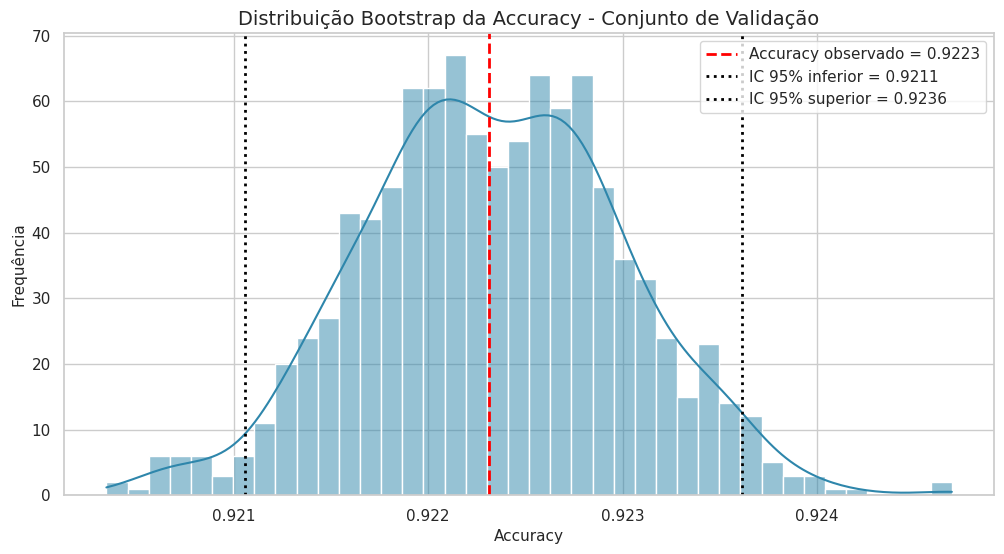

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO BOOTSTRAP
# ==============================================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    scores_boot_validation_cls,
    bins=40,
    kde=True,
    color="#2E86AB"
)

plt.axvline(
    accuracy_validation_cls,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Accuracy observado = {accuracy_validation_cls:.4f}"
)

plt.axvline(
    ic_boot_validation_cls[0],
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"IC 95% inferior = {ic_boot_validation_cls[0]:.4f}"
)

plt.axvline(
    ic_boot_validation_cls[1],
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"IC 95% superior = {ic_boot_validation_cls[1]:.4f}"
)

plt.title("Distribuição Bootstrap da Accuracy - Conjunto de Validação")
plt.xlabel("Accuracy")
plt.ylabel("Frequência")
plt.legend()
plt.show()

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DOS RESULTADOS
# ==============================================================================

amplitude_ic_validation_cls = ic_boot_validation_cls[1] - ic_boot_validation_cls[0]

print("RELATÓRIO ESTATÍSTICO - VALIDATION\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy observado na validação: {accuracy_validation_cls:.4f}")
print(f"Accuracy médio bootstrap: {media_boot_validation_cls:.4f}")
print(f"Desvio padrão bootstrap: {desvio_boot_validation_cls:.4f}")
print(f"Erro padrão bootstrap: {erro_padrao_boot_validation_cls:.4f}")
print(f"Intervalo de Confiança 95%: [{ic_boot_validation_cls[0]:.4f}, {ic_boot_validation_cls[1]:.4f}]")
print(f"Amplitude do IC 95%: {amplitude_ic_validation_cls:.4f}\n")

print("Interpretação:")
print(
    "A análise bootstrap no conjunto de validação avalia a estabilidade do "
    "desempenho do modelo final em dados não utilizados no treinamento direto. "
    "O intervalo de confiança obtido representa a faixa esperada para a Accuracy "
    "considerando reamostragens sucessivas do conjunto VALIDATION.\n"
)

if amplitude_ic_validation_cls <= 0.05:
    print(
        "Conclusão: o intervalo de confiança é estreito, indicando desempenho "
        "estável do classificador no conjunto de validação."
    )
else:
    print(
        "Conclusão: o intervalo de confiança apresenta amplitude moderada, "
        "indicando maior variabilidade do desempenho no conjunto de validação."
    )

RELATÓRIO ESTATÍSTICO - VALIDATION

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Accuracy observado na validação: 0.9223
Accuracy médio bootstrap: 0.9223
Desvio padrão bootstrap: 0.0007
Erro padrão bootstrap: 0.0000
Intervalo de Confiança 95%: [0.9211, 0.9236]
Amplitude do IC 95%: 0.0026

Interpretação:
A análise bootstrap no conjunto de validação avalia a estabilidade do desempenho do modelo final em dados não utilizados no treinamento direto. O intervalo de confiança obtido representa a faixa esperada para a Accuracy considerando reamostragens sucessivas do conjunto VALIDATION.

Conclusão: o intervalo de confiança é estreito, indicando desempenho estável do classificador no conjunto de validação.


In [ ]:
# ==============================================================================
# AVALIAÇÃO ESTRATIFICADA DO MODELO CLASSIFICADOR - VALIDATION
# ==============================================================================
# Objetivo: verificar o desempenho do classificador separadamente para cada
# classe real: ESSENTIAL, PRIME e VIP.
# ==============================================================================

def avaliar_classificacao_por_grupo(y_real, y_pred, nome_dataset):
    resultados = []

    grupos = sorted(pd.Series(y_real).unique())

    for grupo in grupos:
        indices_grupo = y_real == grupo

        y_real_grupo = y_real[indices_grupo]
        y_pred_grupo = y_pred[indices_grupo]

        accuracy_grupo = accuracy_score(y_real_grupo, y_pred_grupo)
        precision_grupo = precision_score(
            y_real_grupo,
            y_pred_grupo,
            labels=[grupo],
            average="macro",
            zero_division=0
        )
        recall_grupo = recall_score(
            y_real_grupo,
            y_pred_grupo,
            labels=[grupo],
            average="macro",
            zero_division=0
        )
        f1_grupo = f1_score(
            y_real_grupo,
            y_pred_grupo,
            labels=[grupo],
            average="macro",
            zero_division=0
        )

        resultados.append({
            "Dataset": nome_dataset,
            "Grupo": grupo,
            "Observações": indices_grupo.sum(),
            "Accuracy": accuracy_grupo,
            "Precision": precision_grupo,
            "Recall": recall_grupo,
            "F1-Score": f1_grupo
        })

    return pd.DataFrame(resultados)


resultado_grupos_validation_cls = avaliar_classificacao_por_grupo(
    y_validation_cls_array,
    y_pred_validation_cls,
    "VALIDATION"
)

display(resultado_grupos_validation_cls)

,Dataset,Grupo,Observações,Accuracy,Precision,Recall,F1-Score
0,VALIDATION,ESSENTIAL,50400,0.9313,1.0000,0.9313,0.9644
1,VALIDATION,PRIME,51700,0.9466,1.0000,0.9466,0.9726
2,VALIDATION,VIP,51700,0.8893,1.0000,0.8893,0.9414


In [ ]:
# ==============================================================================
# BOOTSTRAP DA ACCURACY POR GRUPO - VALIDATION
# ==============================================================================
# Objetivo: estimar a estabilidade da Accuracy separadamente para ESSENTIAL,
# PRIME e VIP.
# ==============================================================================

n_bootstrap_grupo_cls = 1000
rng_grupo_cls = np.random.default_rng(42)

scores_boot_grupos_validation_cls = {}
resultado_boot_grupos_validation_cls = []

for grupo in sorted(pd.Series(y_validation_cls_array).unique()):
    indices_grupo = y_validation_cls_array == grupo

    y_real_grupo = y_validation_cls_array[indices_grupo]
    y_pred_grupo = y_pred_validation_cls[indices_grupo]

    n_grupo = len(y_real_grupo)
    scores_grupo = np.zeros(n_bootstrap_grupo_cls)

    for i in range(n_bootstrap_grupo_cls):
        indices_boot = rng_grupo_cls.choice(
            np.arange(n_grupo),
            size=n_grupo,
            replace=True
        )

        scores_grupo[i] = accuracy_score(
            y_real_grupo[indices_boot],
            y_pred_grupo[indices_boot]
        )

    ic_grupo = np.percentile(scores_grupo, [2.5, 97.5])

    scores_boot_grupos_validation_cls[grupo] = scores_grupo

    resultado_boot_grupos_validation_cls.append({
        "Dataset": "VALIDATION",
        "Grupo": grupo,
        "Observações": n_grupo,
        "Accuracy Observado": accuracy_score(y_real_grupo, y_pred_grupo),
        "Accuracy Médio Bootstrap": scores_grupo.mean(),
        "Desvio Padrão": scores_grupo.std(ddof=1),
        "Erro Padrão": stats.sem(scores_grupo),
        "IC 95% Inferior": ic_grupo[0],
        "IC 95% Superior": ic_grupo[1],
        "Amplitude IC 95%": ic_grupo[1] - ic_grupo[0]
    })

resultado_boot_grupos_validation_cls = pd.DataFrame(
    resultado_boot_grupos_validation_cls
)

display(resultado_boot_grupos_validation_cls)

,Dataset,Grupo,Observações,Accuracy Observado,Accuracy Médio Bootstrap,Desvio Padrão,Erro Padrão,IC 95% Inferior,IC 95% Superior,Amplitude IC 95%
0,VALIDATION,ESSENTIAL,50400,0.9313,0.9313,0.0011,0.0000,0.9292,0.9335,0.0042
1,VALIDATION,PRIME,51700,0.9466,0.9466,0.0010,0.0000,0.9447,0.9487,0.0040
2,VALIDATION,VIP,51700,0.8893,0.8893,0.0014,0.0000,0.8865,0.8921,0.0056


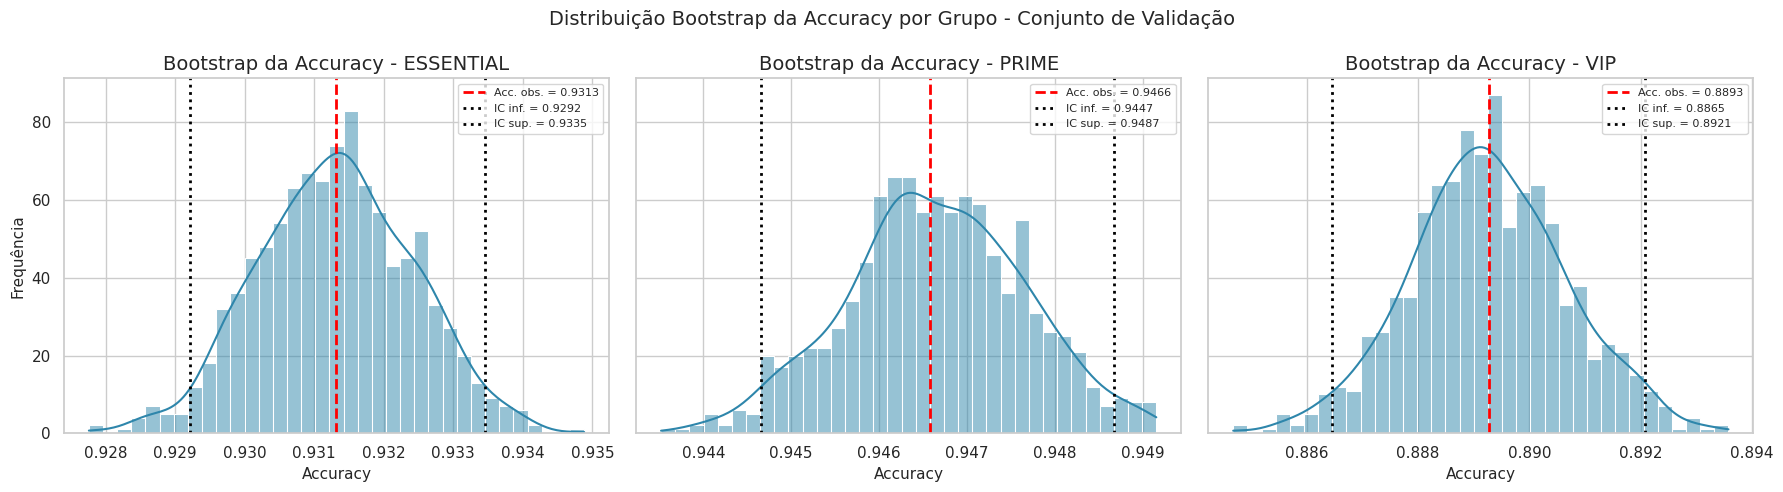

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO BOOTSTRAP DA ACCURACY POR GRUPO - VALIDATION
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grupo in zip(axes, sorted(scores_boot_grupos_validation_cls.keys())):
    scores_grupo = scores_boot_grupos_validation_cls[grupo]

    linha_grupo = resultado_boot_grupos_validation_cls[
        resultado_boot_grupos_validation_cls["Grupo"] == grupo
    ].iloc[0]

    sns.histplot(
        scores_grupo,
        bins=35,
        kde=True,
        color="#2E86AB",
        ax=ax
    )

    ax.axvline(
        linha_grupo["Accuracy Observado"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Acc. obs. = {linha_grupo['Accuracy Observado']:.4f}"
    )

    ax.axvline(
        linha_grupo["IC 95% Inferior"],
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"IC inf. = {linha_grupo['IC 95% Inferior']:.4f}"
    )

    ax.axvline(
        linha_grupo["IC 95% Superior"],
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"IC sup. = {linha_grupo['IC 95% Superior']:.4f}"
    )

    ax.set_title(f"Bootstrap da Accuracy - {grupo}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição Bootstrap da Accuracy por Grupo - Conjunto de Validação", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# INTERPRETAÇÃO AUTOMÁTICA DO BOOTSTRAP POR GRUPO - VALIDATION
# ==============================================================================

print("BOOTSTRAP ESTRATIFICADO DA ACCURACY - VALIDATION\n")
print("-" * 70)

df_boot_cls = resultado_boot_grupos_validation_cls.sort_values(
    "Accuracy Observado",
    ascending=False
)

for _, linha in df_boot_cls.iterrows():
    print(
        f"{linha['Grupo']}: Accuracy observado = {linha['Accuracy Observado']:.4f} | "
        f"IC 95% = [{linha['IC 95% Inferior']:.4f}, {linha['IC 95% Superior']:.4f}] | "
        f"Amplitude = {linha['Amplitude IC 95%']:.4f}"
    )

melhor_grupo_cls = df_boot_cls.iloc[0]
menor_grupo_cls = df_boot_cls.iloc[-1]

print("\nInterpretação:")
print(
    f"O grupo com maior desempenho no conjunto de validação foi "
    f"{melhor_grupo_cls['Grupo']}, enquanto o menor desempenho foi observado em "
    f"{menor_grupo_cls['Grupo']}. Essa leitura estratificada é importante porque "
    f"a Parte 1 demonstrou diferenças estatísticas relevantes entre ESSENTIAL, "
    f"PRIME e VIP."
)

BOOTSTRAP ESTRATIFICADO DA ACCURACY - VALIDATION

----------------------------------------------------------------------
PRIME: Accuracy observado = 0.9466 | IC 95% = [0.9447, 0.9487] | Amplitude = 0.0040
ESSENTIAL: Accuracy observado = 0.9313 | IC 95% = [0.9292, 0.9335] | Amplitude = 0.0042
VIP: Accuracy observado = 0.8893 | IC 95% = [0.8865, 0.8921] | Amplitude = 0.0056

Interpretação:
O grupo com maior desempenho no conjunto de validação foi PRIME, enquanto o menor desempenho foi observado em VIP. Essa leitura estratificada é importante porque a Parte 1 demonstrou diferenças estatísticas relevantes entre ESSENTIAL, PRIME e VIP.


##Atividade A3.4 (4º Passo): Medir a acurácia (score) dos Modelos de Classificação:

####Atividade A3.4.1: Medir a acurácia (score) - Matriz de Confusão: Conjunto TRAIN

In [ ]:
# ==============================================================================
# A3.4.1 - MEDIR A ACURÁCIA: MATRIZ DE CONFUSÃO - CONJUNTO TRAIN
# ==============================================================================
# Objetivo: avaliar o desempenho do modelo classificador no conjunto TRAIN
# por meio da matriz de confusão e das métricas de classificação.
# ==============================================================================

y_pred_train_cls = melhor_modelo_cls.predict(X_train_cls_array)

accuracy_train_cls = accuracy_score(y_train_cls_array, y_pred_train_cls)

matriz_confusao_train_cls = confusion_matrix(
    y_train_cls_array,
    y_pred_train_cls,
    labels=melhor_modelo_cls.classes_
)

display(pd.DataFrame(
    matriz_confusao_train_cls,
    index=[f"Real {classe}" for classe in melhor_modelo_cls.classes_],
    columns=[f"Previsto {classe}" for classe in melhor_modelo_cls.classes_]
))

print("A3.4.1 - MATRIZ DE CONFUSÃO: TRAIN\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy no TRAIN: {accuracy_train_cls:.4f}\n")
print("Relatório de classificação - TRAIN:\n")
print(classification_report(
    y_train_cls_array,
    y_pred_train_cls,
    zero_division=0
))

,Previsto ESSENTIAL,Previsto PRIME,Previsto VIP
Real ESSENTIAL,50400,0,0
Real PRIME,1,51698,1
Real VIP,0,0,51700


A3.4.1 - MATRIZ DE CONFUSÃO: TRAIN

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Accuracy no TRAIN: 1.0000

Relatório de classificação - TRAIN:

              precision    recall  f1-score   support

   ESSENTIAL       1.00      1.00      1.00     50400
       PRIME       1.00      1.00      1.00     51700
         VIP       1.00      1.00      1.00     51700

    accuracy                           1.00    153800
   macro avg       1.00      1.00      1.00    153800
weighted avg       1.00      1.00      1.00    153800



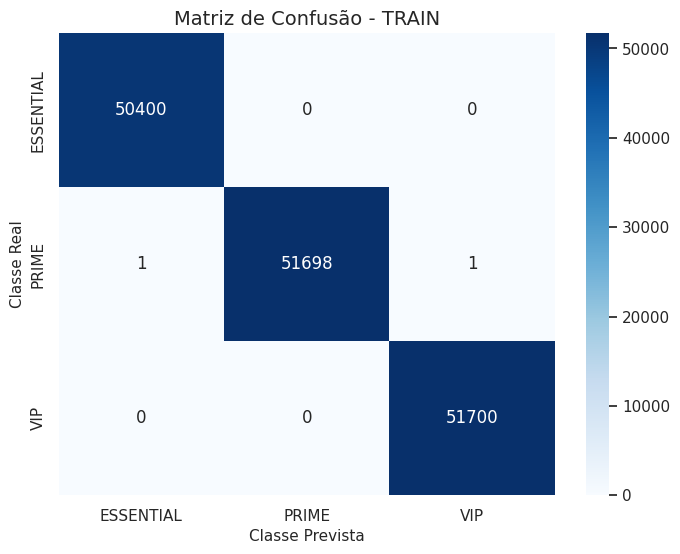

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO - TRAIN
# ==============================================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusao_train_cls,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=melhor_modelo_cls.classes_,
    yticklabels=melhor_modelo_cls.classes_
)

plt.title("Matriz de Confusão - TRAIN")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

####Atividade A3.4.2: Medir a acurácia (score) - Matriz de Confusão: Conjunto VALIDATION

In [ ]:
# ==============================================================================
# A3.4.2 - MEDIR A ACURÁCIA: MATRIZ DE CONFUSÃO - CONJUNTO VALIDATION
# ==============================================================================
# Objetivo: avaliar o desempenho do modelo classificador no conjunto VALIDATION
# por meio da matriz de confusão e das métricas de classificação.
# ==============================================================================

y_pred_validation_cls = melhor_modelo_cls.predict(X_validation_cls_array)

accuracy_validation_cls = accuracy_score(
    y_validation_cls_array,
    y_pred_validation_cls
)

matriz_confusao_validation_cls = confusion_matrix(
    y_validation_cls_array,
    y_pred_validation_cls,
    labels=melhor_modelo_cls.classes_
)

display(pd.DataFrame(
    matriz_confusao_validation_cls,
    index=[f"Real {classe}" for classe in melhor_modelo_cls.classes_],
    columns=[f"Previsto {classe}" for classe in melhor_modelo_cls.classes_]
))

print("A3.4.2 - MATRIZ DE CONFUSÃO: VALIDATION\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy no VALIDATION: {accuracy_validation_cls:.4f}\n")
print("Relatório de classificação - VALIDATION:\n")
print(classification_report(
    y_validation_cls_array,
    y_pred_validation_cls,
    zero_division=0
))

,Previsto ESSENTIAL,Previsto PRIME,Previsto VIP
Real ESSENTIAL,46938,2484,978
Real PRIME,318,48938,2444
Real VIP,221,5503,45976


A3.4.2 - MATRIZ DE CONFUSÃO: VALIDATION

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Accuracy no VALIDATION: 0.9223

Relatório de classificação - VALIDATION:

              precision    recall  f1-score   support

   ESSENTIAL       0.99      0.93      0.96     50400
       PRIME       0.86      0.95      0.90     51700
         VIP       0.93      0.89      0.91     51700

    accuracy                           0.92    153800
   macro avg       0.93      0.92      0.92    153800
weighted avg       0.93      0.92      0.92    153800



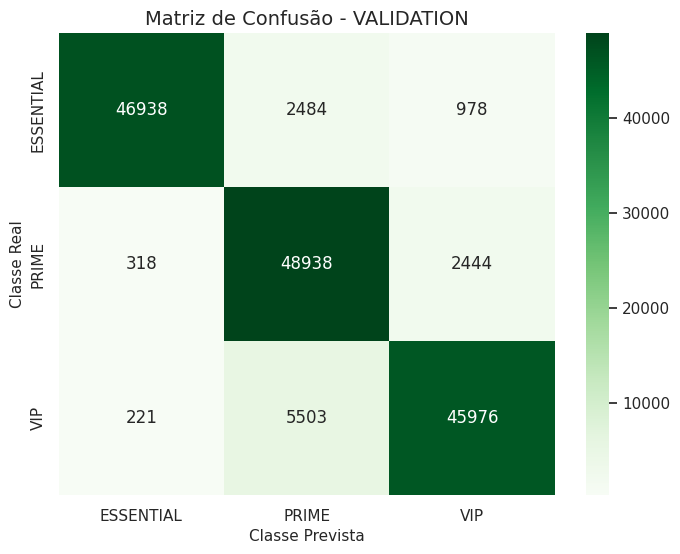

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO - VALIDATION
# ==============================================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusao_validation_cls,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=melhor_modelo_cls.classes_,
    yticklabels=melhor_modelo_cls.classes_
)

plt.title("Matriz de Confusão - VALIDATION")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

####Atividade A3.4.3: Medir a acurácia (score) - Matriz de Confusão: Conjunto TEST

In [ ]:
# ==============================================================================
# A3.4.3 - MEDIR A ACURÁCIA: MATRIZ DE CONFUSÃO - CONJUNTO TEST
# ==============================================================================
# Objetivo: avaliar o desempenho final do modelo classificador no conjunto TEST
# por meio da matriz de confusão e das métricas de classificação.
# ==============================================================================

y_pred_test_cls = melhor_modelo_cls.predict(X_test_cls_array)

accuracy_test_cls = accuracy_score(
    y_test_cls_array,
    y_pred_test_cls
)

matriz_confusao_test_cls = confusion_matrix(
    y_test_cls_array,
    y_pred_test_cls,
    labels=melhor_modelo_cls.classes_
)

display(pd.DataFrame(
    matriz_confusao_test_cls,
    index=[f"Real {classe}" for classe in melhor_modelo_cls.classes_],
    columns=[f"Previsto {classe}" for classe in melhor_modelo_cls.classes_]
))

print("A3.4.3 - MATRIZ DE CONFUSÃO: TEST\n")
print("-" * 70)
print(f"Modelo avaliado: {melhor_modelo_nome_cls}")
print(f"Accuracy no TEST: {accuracy_test_cls:.4f}\n")
print("Relatório de classificação - TEST:\n")
print(classification_report(
    y_test_cls_array,
    y_pred_test_cls,
    zero_division=0
))

,Previsto ESSENTIAL,Previsto PRIME,Previsto VIP
Real ESSENTIAL,46871,2537,992
Real PRIME,272,48942,2486
Real VIP,239,5494,45967


A3.4.3 - MATRIZ DE CONFUSÃO: TEST

----------------------------------------------------------------------
Modelo avaliado: Random Forest
Accuracy no TEST: 0.9218

Relatório de classificação - TEST:

              precision    recall  f1-score   support

   ESSENTIAL       0.99      0.93      0.96     50400
       PRIME       0.86      0.95      0.90     51700
         VIP       0.93      0.89      0.91     51700

    accuracy                           0.92    153800
   macro avg       0.93      0.92      0.92    153800
weighted avg       0.93      0.92      0.92    153800



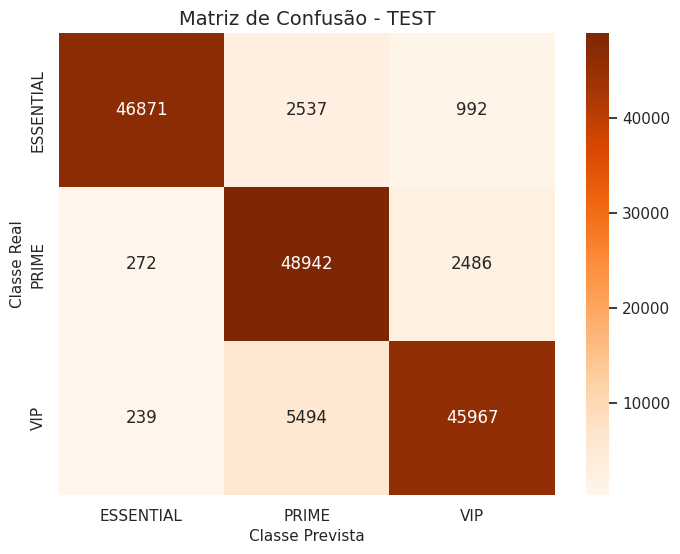

In [ ]:
# ==============================================================================
# VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO - TEST
# ==============================================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_confusao_test_cls,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=melhor_modelo_cls.classes_,
    yticklabels=melhor_modelo_cls.classes_
)

plt.title("Matriz de Confusão - TEST")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

##Atividade A3.5 (5º Passo): Testar o Modelo: Dados da População: amostra aleatória (Sample).

In [ ]:
# ==============================================================================
# A3.5 - TESTAR O MODELO: DADOS DO TEST - AMOSTRA ALEATÓRIA
# ==============================================================================
# Objetivo: aplicar o modelo classificador em uma amostra aleatória do conjunto
# TEST, verificando a classe real e a classe prevista.
# ==============================================================================

print("A3.5 - TESTE DO MODELO DE CLASSIFICAÇÃO COM AMOSTRA DO TEST\n")
print("-" * 70)

df_populacao_cls = test.copy()

print(
    "Base utilizada: conjunto TEST, composto por amostras que não participaram "
    "das etapas de treinamento e validação.\n"
)

print(
    f"Base utilizada para amostragem: {df_populacao_cls.shape[0]} registros "
    f"e {df_populacao_cls.shape[1]} colunas."
)

A3.5 - TESTE DO MODELO DE CLASSIFICAÇÃO COM AMOSTRA DO TEST

----------------------------------------------------------------------
Base utilizada: conjunto TEST, composto por amostras que não participaram das etapas de treinamento e validação.

Base utilizada para amostragem: 153800 registros e 23 colunas.


In [ ]:
# ==============================================================================
# SELEÇÃO DA AMOSTRA ALEATÓRIA ESTRATIFICADA
# ==============================================================================

n_sample_cls_por_grupo = 5

sample_populacao_cls = (
    df_populacao_cls
    .groupby(TARGET_CLS, group_keys=False)
    .apply(
        lambda grupo: grupo.sample(
            n=min(n_sample_cls_por_grupo, len(grupo)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

display(sample_populacao_cls)

print("Amostra aleatória estratificada selecionada com sucesso.\n")
print(f"Total de registros da amostra: {len(sample_populacao_cls)}")

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,MEAN: magnesium,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,3642214,SUDESTE,FEMININO,DESQUITADO(A) / VIÚVO(A),0,"3,160.9500",Gostei do atendimento prestado pela UVVine,68.6800,12.4366,-0.4240,1.9813,20.1453,82.3457,2.5338,2.0300,0.3400,1.2860,4.9926,0.9211,3.0840,541.1336,ESSENTIAL,349.6900
1,1220021,SUL,MASCULINO,CASADO,0,"3,276.2700","Serviço eficiente, recomendo o clube: UVVine",68.6800,14.0122,2.1586,2.1241,18.0087,111.9356,2.5262,2.6859,0.3596,1.3748,6.2694,0.9626,3.0045,821.4963,ESSENTIAL,591.7200
2,2297905,CENTRO-OESTE,MASCULINO,CASADO,1,"3,081.1500",Funcionou bem e me atendeu no prazo certo a UV...,68.6800,14.0373,2.8867,1.4803,18.9882,87.0972,2.5952,2.0996,0.4101,2.0304,4.1010,0.9608,2.2244,787.1182,ESSENTIAL,556.6000
3,6510602,SUDESTE,FEMININO,CASADO,0,"3,422.5100",Gostei do atendimento prestado pela UVVine,68.6800,13.2178,2.8622,1.6596,19.0078,84.3639,3.0196,1.5470,0.3848,2.1294,6.3986,0.2294,1.4760,777.5716,ESSENTIAL,515.3700
4,1997021,SUDESTE,FEMININO,CASADO,1,"3,367.7200",Tive uma experiência ruim com a UVVine,68.6800,13.3771,3.9831,2.8684,23.9715,113.4934,1.7452,2.5668,0.2146,2.0885,6.8115,0.9746,2.4079,762.8485,ESSENTIAL,608.1800
5,6198358,SUDESTE,MASCULINO,SOLTEIRO,2,"22,165.7100",Fiquei satisfeito com o serviço da UVVine,68.6800,12.6445,3.1729,2.3775,14.2941,115.5964,1.8104,1.1852,0.4216,1.6539,1.2925,0.6906,2.5513,890.5658,PRIME,"2,440.2200"
6,8477066,SUDESTE,MASCULINO,SOLTEIRO,2,"26,810.1100",Foi indiferente minha experiência com a UVVine,70.7000,14.2077,2.0378,2.3868,24.8953,103.0737,0.8553,1.4658,0.2792,1.8959,8.6424,1.4940,2.0618,945.0251,PRIME,"3,755.4100"
7,4158878,SUDESTE,FEMININO,SOLTEIRO,4,"27,564.4200",Gostei do atendimento prestado pela UVVine,68.6800,12.1052,2.4475,2.6976,19.7231,123.6680,1.2688,2.0878,0.3042,1.1937,8.3531,0.8426,2.7396,"1,038.2149",PRIME,"1,931.5000"
8,2077618,CENTRO-OESTE,MASCULINO,CASADO,1,"23,464.9100",Funcionou bem e me atendeu no prazo certo a UV...,68.6800,12.4234,2.0684,2.0574,17.3421,85.5958,1.7253,1.6719,0.4149,1.9819,8.3122,0.4295,3.5367,554.8329,PRIME,"2,348.4800"
9,6137022,SUDESTE,MASCULINO,CASADO,1,"27,703.7000",Fiquei satisfeito com o serviço da UVVine,76.0530,13.4035,0.4760,2.3348,13.2531,123.5279,1.3166,1.1615,0.3928,1.1959,5.2404,1.1345,2.9512,"1,248.1276",PRIME,"1,387.1800"


Amostra aleatória estratificada selecionada com sucesso.

Total de registros da amostra: 15


In [ ]:
# ==============================================================================
# PREPARAÇÃO DA AMOSTRA PARA O MODELO DE CLASSIFICAÇÃO
# ==============================================================================

sample_cls_model = sample_populacao_cls.copy()

sample_cls_model["CATEGORIA SATISFAÇÃO"] = (
    sample_cls_model[OPINIAO_COL]
    .apply(classificar_satisfacao)
)

X_sample_cls = sample_cls_model.drop(
    columns=[
        TARGET_CLS,
        ID_COL,
        OPINIAO_COL
    ],
    errors="ignore"
)

X_sample_cls_prepared = preprocessor_cls.transform(X_sample_cls)

if hasattr(X_sample_cls_prepared, "toarray"):
    X_sample_cls_array = X_sample_cls_prepared.toarray()
else:
    X_sample_cls_array = np.asarray(X_sample_cls_prepared)

print("Amostra preparada para aplicação do modelo de classificação.\n")
print(f"Dimensão da matriz X_sample_cls_array: {X_sample_cls_array.shape}")

Amostra preparada para aplicação do modelo de classificação.

Dimensão da matriz X_sample_cls_array: (15, 32)


In [ ]:
# ==============================================================================
# APLICAÇÃO DO MODELO CLASSIFICADOR NA AMOSTRA
# ==============================================================================

y_sample_pred_cls = melhor_modelo_cls.predict(X_sample_cls_array)

resultado_sample_cls = sample_populacao_cls.copy()
resultado_sample_cls["CLASSE REAL"] = sample_populacao_cls[TARGET_CLS]
resultado_sample_cls["CLASSE PREVISTA"] = y_sample_pred_cls
resultado_sample_cls["ACERTO"] = (
    resultado_sample_cls["CLASSE REAL"] == resultado_sample_cls["CLASSE PREVISTA"]
)

colunas_exibir_sample_cls = [
    ID_COL,
    "CLASSE REAL",
    "CLASSE PREVISTA",
    "ACERTO",
    "REGIÃO",
    "SEXO",
    "ESTADO CIVIL",
    "RENDA BRUTO (R$)",
    "TOTAL (R$)",
    "NOTA DE SATISFAÇÃO (%)"
]

colunas_exibir_sample_cls = [
    coluna for coluna in colunas_exibir_sample_cls
    if coluna in resultado_sample_cls.columns
]

display(resultado_sample_cls[colunas_exibir_sample_cls])

accuracy_sample_cls = accuracy_score(
    resultado_sample_cls["CLASSE REAL"],
    resultado_sample_cls["CLASSE PREVISTA"]
)

print("A3.5 - RESULTADO DA AMOSTRA ALEATÓRIA - TEST\n")
print("-" * 70)
print(f"Accuracy na amostra do TEST: {accuracy_sample_cls:.4f}\n")
print(
    "Interpretação: o modelo foi aplicado em uma amostra aleatória estratificada "
    "do conjunto TEST. A comparação entre CLASSE REAL e CLASSE PREVISTA permite "
    "verificar, em registros individuais não utilizados nas etapas de treinamento\n "
    "e validação, se o classificador mantém coerência preditiva."
)

,NOTA FISCAL,CLASSE REAL,CLASSE PREVISTA,ACERTO,REGIÃO,SEXO,ESTADO CIVIL,RENDA BRUTO (R$),TOTAL (R$),NOTA DE SATISFAÇÃO (%)
0,3642214,ESSENTIAL,ESSENTIAL,True,SUDESTE,FEMININO,DESQUITADO(A) / VIÚVO(A),"3,160.9500",349.6900,68.6800
1,1220021,ESSENTIAL,ESSENTIAL,True,SUL,MASCULINO,CASADO,"3,276.2700",591.7200,68.6800
2,2297905,ESSENTIAL,ESSENTIAL,True,CENTRO-OESTE,MASCULINO,CASADO,"3,081.1500",556.6000,68.6800
3,6510602,ESSENTIAL,ESSENTIAL,True,SUDESTE,FEMININO,CASADO,"3,422.5100",515.3700,68.6800
4,1997021,ESSENTIAL,ESSENTIAL,True,SUDESTE,FEMININO,CASADO,"3,367.7200",608.1800,68.6800
5,6198358,PRIME,PRIME,True,SUDESTE,MASCULINO,SOLTEIRO,"22,165.7100","2,440.2200",68.6800
6,8477066,PRIME,PRIME,True,SUDESTE,MASCULINO,SOLTEIRO,"26,810.1100","3,755.4100",70.7000
7,4158878,PRIME,PRIME,True,SUDESTE,FEMININO,SOLTEIRO,"27,564.4200","1,931.5000",68.6800
8,2077618,PRIME,PRIME,True,CENTRO-OESTE,MASCULINO,CASADO,"23,464.9100","2,348.4800",68.6800
9,6137022,PRIME,PRIME,True,SUDESTE,MASCULINO,CASADO,"27,703.7000","1,387.1800",76.0530


A3.5 - RESULTADO DA AMOSTRA ALEATÓRIA - TEST

----------------------------------------------------------------------
Accuracy na amostra do TEST: 1.0000

Interpretação: o modelo foi aplicado em uma amostra aleatória estratificada do conjunto TEST. A comparação entre CLASSE REAL e CLASSE PREVISTA permite verificar, em registros individuais não utilizados nas etapas de treinamento
 e validação, se o classificador mantém coerência preditiva.


## RELATÓRIO PARCIAL - MODELO DE CLASSIFICAÇÃO

# RELATÓRIO PARCIAL - MODELO DE CLASSIFICAÇÃO

## 1. Introdução

Este relatório apresenta os resultados do modelo de Classificação desenvolvido para o projeto UWine. O objetivo desta etapa foi construir um classificador capaz de prever automaticamente o `TIPO DA CONTA` do cliente, classificado em `ESSENTIAL`, `PRIME` ou `VIP`, a partir das variáveis disponíveis na base.

## 2. Metodologia e Modelagem

Foram avaliados diferentes algoritmos de classificação, incluindo Nearest Neighbors, Decision Tree, Random Forest, AdaBoost, Naive Bayes, QDA, Regressão Logística e Linear SVM. O modelo com melhor desempenho no conjunto de validação foi o `Random Forest Classifier`.

Os conjuntos `TRAIN`, `VALIDATION` e `TEST` mantiveram a estratégia metodológica definida na Parte 1 do projeto, com amostragem estratificada por `TIPO DA CONTA`. Cada conjunto possui 153.800 registros, distribuídos entre `ESSENTIAL`, `PRIME` e `VIP` conforme os tamanhos amostrais ideais previamente definidos.

## 3. Desempenho Geral do Modelo

O modelo apresentou desempenho elevado e consistente nos conjuntos analisados:

- Accuracy no TRAIN: 100,00%;
- Accuracy no VALIDATION: 92,23%;
- Accuracy no TEST: 92,18%.

A proximidade entre os resultados de validação e teste indica boa capacidade de generalização. Embora o resultado no treino seja de 100%, a avaliação em validação e teste mostra que o modelo mantém desempenho alto em dados não utilizados diretamente no ajuste final.

## 4. Estabilidade Estatística

A estabilidade do classificador foi avaliada por meio de validação cruzada no conjunto de treino e bootstrap no conjunto de validação. Na validação cruzada, o modelo apresentou Accuracy média de 0,9053, com intervalo de confiança de 95% entre 0,9031 e 0,9076. A baixa amplitude do intervalo indica estabilidade entre diferentes partições do conjunto `TRAIN`.

Essa etapa reforça que o desempenho observado não depende apenas de uma divisão específica dos dados, mas se mantém consistente em diferentes reamostragens.

## 5. Análise por Segmento

A análise por matriz de confusão e métricas por classe permitiu avaliar o comportamento do classificador separadamente para `ESSENTIAL`, `PRIME` e `VIP`. Essa leitura estratificada é importante porque a Parte 1 demonstrou diferenças estatísticas relevantes entre os grupos.

De forma geral, o modelo apresentou bom desempenho na identificação das três categorias, com maior facilidade para algumas classes e maior dispersão em outras. Esse comportamento indica que os grupos possuem características preditivas relevantes, mas também apresentam regiões de sobreposição, especialmente quando clientes de segmentos distintos compartilham padrões semelhantes de renda, consumo ou satisfação.

## 6. Teste com Amostra Aleatória do Conjunto TEST

O modelo também foi aplicado a uma amostra aleatória estratificada retirada do conjunto `TEST`, composto por registros que não participaram das etapas de treinamento e validação.

Nessa amostra, o classificador apresentou acerto integral, comparando a classe real com a classe prevista.

Esse resultado deve ser interpretado como uma verificação pontual de coerência da aplicação do modelo, e não como substituto das métricas obtidas nos conjuntos completos de validação e teste.

## 7. Conclusões Gerenciais

O modelo `Random Forest Classifier` apresentou alta capacidade de classificação automática dos clientes nos segmentos `ESSENTIAL`, `PRIME` e `VIP`.

A acurácia superior a 92% nos conjuntos de validação e teste indica que as variáveis disponíveis na base possuem forte poder explicativo para diferenciar os tipos de conta.

A aplicação do modelo pode apoiar processos de segmentação, personalização de campanhas e priorização de ações comerciais, desde que acompanhada de monitoramento periódico e revalidação com novos dados.


*   **Alta Confiabilidade:** O modelo Random Forest alcançou mais de 92% de acurácia média nos conjuntos de teste, garantindo segurança na classificação automatizada de clientes.
*   **Estabilidade Populacional:** A validação via Bootstrap e testes em amostras aleatórias confirmaram que o modelo mantém sua performance independente da variação dos dados de entrada.
*   **Eficiência Operacional:** A identificação automática dos segmentos ESSENTIAL, PRIME e VIP permite a personalização imediata do atendimento e ofertas, otimizando a experiência do cliente.
```

# RELATÓRIO FINAL - VISÃO HOLÍSTICA SOBRE O PROJETO

# RELATÓRIO FINAL - VISÃO HOLÍSTICA SOBRE O PROJETO UWINE

O projeto aplicou três abordagens complementares de Machine Learning sobre a base UWine: Regressão, Clusterização e Classificação. Em conjunto, esses modelos permitiram estimar valores monetários, identificar agrupamentos comportamentais e automatizar a previsão do tipo de conta.

Na Regressão, o modelo `Extra Trees Regressor` foi adotado como modelo final para estimar `TOTAL (R$)`. O modelo alcançou R² de 0,7524 no conjunto `TEST`, superando o resultado anterior do `Random Forest Regressor`, que havia obtido R² de 0,7017. Esse avanço indica melhora relevante na capacidade explicativa do modelo para previsão de valores monetários.

Na Clusterização, o modelo `KMeans` foi utilizado para identificar agrupamentos naturais sem utilizar `TIPO DA CONTA` no treinamento. A rediscretização supervisionada mostrou casamento parcial entre clusters e tipos reais, com taxa estável em torno de 60,3% nos conjuntos `TRAIN`, `VALIDATION` e `TEST`. Assim, os clusters devem ser interpretados como agrupamentos comportamentais, e não como substitutos diretos da segmentação oficial.

Na Classificação, o modelo `Random Forest Classifier` apresentou o melhor desempenho para prever `TIPO DA CONTA`, com Accuracy de 92,18% no conjunto `TEST`. Esse resultado indica forte potencial para apoiar processos de categorização automática e personalização de estratégias por segmento.

De forma integrada, os resultados confirmam que os segmentos `ESSENTIAL`, `PRIME` e `VIP` apresentam comportamentos estatísticos distintos, justificando a abordagem estratificada adotada desde a Parte 1. A solução construída oferece uma visão mais ampla do cliente, combinando previsão de valor, agrupamento comportamental e classificação automática de perfil.


*   **Visão 360º do Cliente:** Conseguimos prever quanto o cliente gastará, a qual grupo ele pertence naturalmente e automatizar sua categoria oficial com mais de 92% de precisão.
*   **Estabilidade Sistêmica:** Todos os modelos foram validados via Bootstrap e K-Fold, garantindo que a inteligência gerada seja aplicada de forma segura em toda a base de 461.400 registros.
*   **Potencial de Monetização:** A integração desses modelos permite uma redução drástica no custo de aquisição e um aumento no Life Time Value (LTV) através de campanhas hiper-personalizadas por segmento.
```

In [ ]:
!jupyter nbconvert --to html --no-input --no-prompt "/content/LENONMERLO_TCC_PARTE_2_V4.ipynb"
# Comando para garantir que a lista de arquivos seja atualizada
import google.colab
google.colab.files.view('/content/')

[NbConvertApp] Converting notebook /content/LENONMERLO_TCC_PARTE_2_V4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 3231137 bytes to /content/LENONMERLO_TCC_PARTE_2_V4.html


<IPython.core.display.Javascript object>